%md
# Heater Current Drift Detection
## IsolationForest-based Approach
Author: Sandro Wiedmer

Q2/2026

## 1. Install & Imports

In [0]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay


## 2. Configuration
All tunable parameters in one place.

In [0]:
# ── Damaged pairs (manually confirmed true positives) ──────────────────────────
DAMAGED_PAIRS = [
  ("t3-1678901-1966","1674634"),
  ("t3-1831151-186","1824362"),
  ("t3-1882150-500","1864990"),
  ("t3-1991730-874","1977123"),
  ("t3-2008-1726","1892070"),
  ("t3-2008-1726","2043143"),
  ("t3-2009-1777","1448576"),
  ("t3-2002-1557","1392867"),
  ("t3-1817879-52","1810944"),
  ("t3-1993491-843","1950888"),
  ("t3-1882151-611","1853962"),
  ("t3-1829086-180","1939694"),
  ("t3-1830503-165","1823505"),
  ]
DAMAGED_SET = set(DAMAGED_PAIRS)

# ── Feature sets ───────────────────────────────────────────────────────────────
FEATURES_4 = ["focal_spot", "hv_kv_set", "tucu_ma_set", "pwr_w_reached", "grid_voltage"]
FEATURES_2 = ["focal_spot", "hv_kv_set"]

# ── Balancing ─────────────────────────────────────────────────────────────────
BALANCE_BY_PAIR = False  # True → equal samples per pair; False → all samples
                         # Recommended False for IF: more data = better density estimate

# ── IsolationForest hyper-parameter search grid ────────────────────────────────
# Each combination is evaluated; the best trade-off (recall=100%, min FP) is kept.
IF_PARAM_GRID = {
    "n_estimators":  [100, 200, 300],
    "max_samples":   ["auto", 64, 128, 256],
    "contamination": [0.005, 0.01, 0.02, 0.05],  # expected fraction of outliers
    "max_features":  [1.0, 0.8],
}

# ── Pre-processing options (also swept in grid) ────────────────────────────────
ROLLING_WINDOWS = [1, 5, 10, 20]   # 1 = no smoothing (raw filcu_a)
                                    # >1 = rolling mean over N samples per pair

# ── Drift-confirmation gate ────────────────────────────────────────────────────
MIN_DETECTIONS = 3     # consecutive anomaly-flagged samples needed to confirm drift

# ── Train / test split ratio ───────────────────────────────────────────────────
TEST_SPLIT_RATIO = 0.20


## 2b. [EXPERIMENTAL] Configuration — Improvements


| Problem | Root cause | Experimental fix |
|---------|-----------|-----------------|
| Tube-to-tube filcu_a offset | Global IF mixes all manufacturing variance → missed detections on low-side tubes | **Pair-specific score calibration** using first N samples as support values |
| 4-feat worse than 2-feat | Operating params dilute the filcu_a anomaly signal in high-dim IF splits | **Per operating-group IF**: condition on (focal_spot, kV_bucket), detect only on filcu_a |
| IF ignores temporal order | Binary predict()==-1 treats drift same as spike | **CUSUM on IF score** time series per pair → converts point detector to change-point detector |
| Fixed threshold at 0 | Too loose for some pairs, too tight for others | **Adaptive per-pair threshold** = baseline_score − k × baseline_std |

All new parameters are prefixed `EXP_`. Existing config is **unchanged**.

=> `EXP_` This was an EXPERIMENT: in the report, from this `EXP_` only the results regarding precision vs. lead time trade-off are used, the rest is taken from the original version (where no `EXP_` is mentioned)

=> `EXP_` is more complicated, but lower precision than the original. It could be interesting, if further investigate on the trade-off precision vs lead time ("Pareto")


In [0]:
# ══════════════════════════════════════════════════════════════════════════════
# [EXPERIMENTAL] Configuration — insert after §2 Configuration
# ══════════════════════════════════════════════════════════════════════════════

# ── Pair-specific score calibration ───────────────────────────────────────────
# Analogous to "first N residuals as baseline" in the regression notebook.
# First N samples of each TEST pair are used to estimate that pair's healthy
# IF score level. Drift = score drops significantly below this calibrated level.
EXP_BASELINE_N = 30        # number of early-life samples per pair for calibration
                            # increase if tubes need more settling time

# ── Per operating-group IF ─────────────────────────────────────────────────────
# Train one IF per (focal_spot, kV_bucket) using ONLY filcu_a_smooth.
# This removes operating-point variance from the anomaly model so the only
# signal left is the filcu_a deviation within that operating condition.
EXP_KV_BUCKET_SIZE = 50    # kV bin width for grouping (e.g. 50 → [0,50), [50,100)…)
EXP_MIN_GROUP_SAMPLES = 30 # minimum train samples required to fit a group-level IF;
                            # groups with fewer samples fall back to global IF

# ── Per-group IF parameters ────────────────────────────────────────────────────
EXP_GROUP_IF_PARAMS = {
    "n_estimators":  [100, 200],
    "contamination": [0.005, 0.01, 0.02],
    "max_samples":   ["auto", 64, 128],
}

# ── CUSUM on IF score ──────────────────────────────────────────────────────────
# After scoring, apply one-sided CUSUM on the NEGATIVE adjusted IF score
# (negative because IF score decreases when anomaly increases).
# k = allowance (fraction of baseline_std); h = decision threshold multiplier.
EXP_CUSUM_K_FACTOR = 0.25  # k = EXP_CUSUM_K_FACTOR × baseline_std per pair
EXP_CUSUM_H_FACTOR = 3.0   # h = EXP_CUSUM_H_FACTOR × baseline_std per pair

# ── Adaptive per-pair threshold ────────────────────────────────────────────────
# Pair is flagged if (IF score) < (pair_baseline_mean - EXP_SCORE_SIGMA × pair_baseline_std)
# This replaces the fixed threshold of 0.
EXP_SCORE_SIGMA = 2.0       # how many baseline std devs below mean triggers alarm

# ── Confirmation gate ──────────────────────────────────────────────────────────
EXP_MIN_DETECTIONS = 2      # lower than §2 baseline (3); catches slower drifts earlier

# ── Parameter sweep for extended grid ─────────────────────────────────────────
EXP_CUSUM_H_SWEEP     = [1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0]
EXP_SCORE_SIGMA_SWEEP = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
EXP_BASELINE_N_SWEEP  = [10, 20, 30, 50]


## 3. Load & Clean Data


In [0]:
df_raw = spark.table("svc_datacore.external.silver_blox_enriched")

# Keep 450MF tubes only
df_valid = df_raw.filter(
    F.lower(F.col("tube_model")).like("%450mf%") |
    F.lower(F.col("tube_model")).like("%y.tu450%")
).select("device_id", "tube_id").distinct()

df_tube = df_raw.join(df_valid, on=["device_id", "tube_id"], how="inner")

# Relevant event types, drop nulls on required columns
df_tube = df_tube.filter(F.col("event_type").isin("exposure", "warm_up", "disrupted_warm_up"))
df_clean = df_tube.dropna(subset=["start_time", "filcu_a"] + FEATURES_4)

# Keep top 30 % of lifetime per pair (same as regression notebook)
_life_win = Window.partitionBy("device_id", "tube_id").orderBy("start_time")
df_clean = (
    df_clean
    .withColumn("life_metric", F.percent_rank().over(_life_win))
    .filter(F.col("life_metric") <= 0.30)
    .filter(F.col("filcu_a") >= 1.0)
    .select(
        "device_id", "tube_id", "focal_spot", "event_type", "start_time",
        "duration_seconds", "hv_kv_set", "tucu_ma_set", "pwr_w_reached","grid_voltage",
        "filcu_a", "shutdown_type", "reason", "arc_count",
        "comp_software", "life_metric", "tube_model",
    )
)

print(f"df_clean: {df_clean.count()} rows")
display(df_clean.limit(5))


df_clean: 71875 rows


device_id,tube_id,focal_spot,event_type,start_time,duration_seconds,hv_kv_set,tucu_ma_set,pwr_w_reached,grid_voltage,filcu_a,shutdown_type,reason,arc_count,comp_software,life_metric,tube_model
t3-0-271,1852782,3,exposure,2025-07-14T11:27:17.000448Z,322.6,100,1.0,50.6,317.0,1.47,regular,"itf,1,0",0,4.1.2,0.0,mxc-450mf
t3-0-271,1852782,0,exposure,2025-07-14T14:17:03.847075Z,5896.0,280,1.61,50.6,226.6,1.43,regular,"itf,1,0",0,4.1.2,4.492362982929021E-4,mxc-450mf
t3-0-271,1852782,0,exposure,2025-07-14T16:10:45.29598Z,282.5,280,1.61,450.4,226.6,1.42,regular,"itf,1,0",0,4.1.2,8.984725965858042E-4,mxc-450mf
t3-0-271,1852782,0,exposure,2025-07-15T17:41:05.803922Z,32.8,100,2.0,199.8,189.0,1.59,regular,"itf,1,0",0,4.1.2,0.0013477088948787063,mxc-450mf
t3-0-271,1852782,0,exposure,2025-07-15T17:42:20.98972Z,10.6,100,2.0,200.4,189.0,1.59,regular,"itf,1,0",0,4.1.2,0.0017969451931716084,mxc-450mf


## 4. Train / Test Split
- All **damaged pairs** go to **test** (they are never seen during training).
- Remaining pairs are randomly split; to achieve overall 80 % train, 20 % test.
- IsolationForest is trained **only on the train set** (which contains no damaged pairs),
  so it learns the healthy distribution exclusively.


In [0]:
damaged_pairs_df = spark.createDataFrame(DAMAGED_PAIRS, ["device_id", "tube_id"])
all_pairs        = df_clean.select("device_id", "tube_id").distinct()
non_damaged      = all_pairs.join(damaged_pairs_df, on=["device_id", "tube_id"], how="left_anti")

total_pairs   = all_pairs.count()
extra_needed  = max(0, int(total_pairs * TEST_SPLIT_RATIO) - len(DAMAGED_PAIRS))
extra_test    = non_damaged.orderBy(F.rand(seed=42)).limit(extra_needed)
all_test_pairs = damaged_pairs_df.unionByName(extra_test)

df_flagged = df_clean.join(
    all_test_pairs.withColumn("_is_test", F.lit(True)),
    on=["device_id", "tube_id"], how="left"
).withColumn("_is_test", F.coalesce(F.col("_is_test"), F.lit(False)))

df_train = df_flagged.filter(~F.col("_is_test")).drop("_is_test")
df_test  = df_flagged.filter( F.col("_is_test")).drop("_is_test")

print(f"Train pairs : {df_train.select('device_id','tube_id').distinct().count()}")
print(f"Test  pairs : {df_test .select('device_id','tube_id').distinct().count()}")
print(f"Damaged pairs in test (should equal {len(DAMAGED_PAIRS)}):",
      damaged_pairs_df
          .join(df_test.select("device_id","tube_id").distinct(),
                on=["device_id","tube_id"], how="inner")
          .count())


Train pairs : 116
Test  pairs : 29
Damaged pairs in test (should equal 13): 13


## 5. Data Preparation Helpers

In [0]:
# ── Optional balancing ─────────────────────────────────────────────────────────
def balance_by_pair(df, enabled=True):
    """
    Optionally sample equal rows per (device_id, tube_id).
    Set enabled=False when min samples per pair is very low (e.g. 1).
    """
    if not enabled:
        print("Balancing disabled — using all samples per pair.")
        return df
    min_n = df.groupBy("device_id", "tube_id").count().agg(F.min("count")).collect()[0][0]
    if min_n <= 1:
        print(f"WARNING: min samples/pair = {min_n}. "
              "Balancing to 1 row defeats training — set BALANCE_BY_PAIR=False.")
    print(f"Balancing enabled — {min_n} samples per pair.")
    return df.groupBy("device_id", "tube_id").applyInPandas(
        lambda pdf: pdf.sample(n=min_n, random_state=42) if len(pdf) > min_n else pdf,
        schema=df.schema
    )


# ── Feature encoding (categorical → int codes) ────────────────────────────────
def encode_features(pdf, feature_list, fit_encoders=None):
    """
    Encode categorical columns to integer codes.
    Pass fit_encoders=None to fit new encoders (train set).
    Pass fit_encoders=<dict> to reuse encoders (test set).
    Returns (X_array, encoders_dict).
    """
    pdf = pdf.copy()
    encoders = {} if fit_encoders is None else fit_encoders
    for col in feature_list:
        if pdf[col].dtype == object:
            if fit_encoders is None:
                le = LabelEncoder()
                pdf[col] = le.fit_transform(pdf[col].astype(str))
                encoders[col] = le
            else:
                le = encoders[col]
                known = set(le.classes_)
                pdf[col] = pdf[col].astype(str).apply(
                    lambda v: le.transform([v])[0] if v in known else -1
                )
    return pdf[feature_list].values.astype(float), encoders


# ── Rolling mean pre-processing ───────────────────────────────────────────────
def apply_rolling(pdf, window, target_col="filcu_a"):
    """
    Apply rolling mean of `window` samples to `target_col` per (device_id, tube_id).
    window=1 returns the raw column unchanged.
    """
    if window <= 1:
        pdf = pdf.copy()
        pdf["filcu_a_smooth"] = pdf[target_col]
        return pdf

    def _roll(g):
        g = g.sort_values("start_time").copy()
        g["filcu_a_smooth"] = g[target_col].rolling(window, min_periods=1).mean()
        return g

    return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)


# ── Drift-confirmation: MIN_DETECTIONS consecutive anomalies ──────────────────
def flag_with_gate(series_bool, min_det=MIN_DETECTIONS):
    """
    Returns True at the first index where `min_det` consecutive Trues have been seen.
    Everything before that index is False.
    """
    flagged = np.zeros(len(series_bool), dtype=bool)
    run = 0
    for i, v in enumerate(series_bool):
        run = run + 1 if v else 0
        if run >= min_det:
            flagged[i] = True
    return flagged


## 6. Collect to Pandas
All subsequent work is in pandas / sklearn (Spark only used for data loading).

In [0]:
df_train_bal = balance_by_pair(df_train, enabled=BALANCE_BY_PAIR)
df_test_bal  = balance_by_pair(df_test,  enabled=BALANCE_BY_PAIR)

# Collect to pandas once — avoid repeated toPandas() in the grid loop
pdf_train = df_train_bal.toPandas()
pdf_test  = df_test_bal.toPandas()
pdf_test["is_damaged"] = pdf_test.apply(
    lambda r: (r["device_id"], r["tube_id"]) in DAMAGED_SET, axis=1
)

print(f"Train rows : {len(pdf_train)}")
print(f"Test  rows : {len(pdf_test)}")
print(f"Damaged rows in test: {pdf_test['is_damaged'].sum()}")


Balancing disabled — using all samples per pair.
Balancing disabled — using all samples per pair.
Train rows : 58791
Test  rows : 13084
Damaged rows in test: 11695


## 6b. [EXPERIMENTAL] Per Operating-Group IsolationForest

**Fix:** instead of giving IF the operating parameters as *input features*, use
them purely to *condition* the model. Train one IF **per (focal_spot, kV_bucket)**
using **only `filcu_a_smooth`** as input. Each group-IF then learns what "normal
heater current looks like at this specific operating point" — and its anomaly score
purely reflects whether filcu_a has deviated from the expected level at that point.

This is the IF equivalent of the regression notebook's operating-group residual
normalisation.

/root/.ipykernel/6037/command-5630547205330637-1345276283:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)
/root/.ipykernel/6037/command-5630547205330637-1345276283:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)


Trained 40 group-level IFs (out of 40 groups)
Groups below min_samples threshold (30): 0


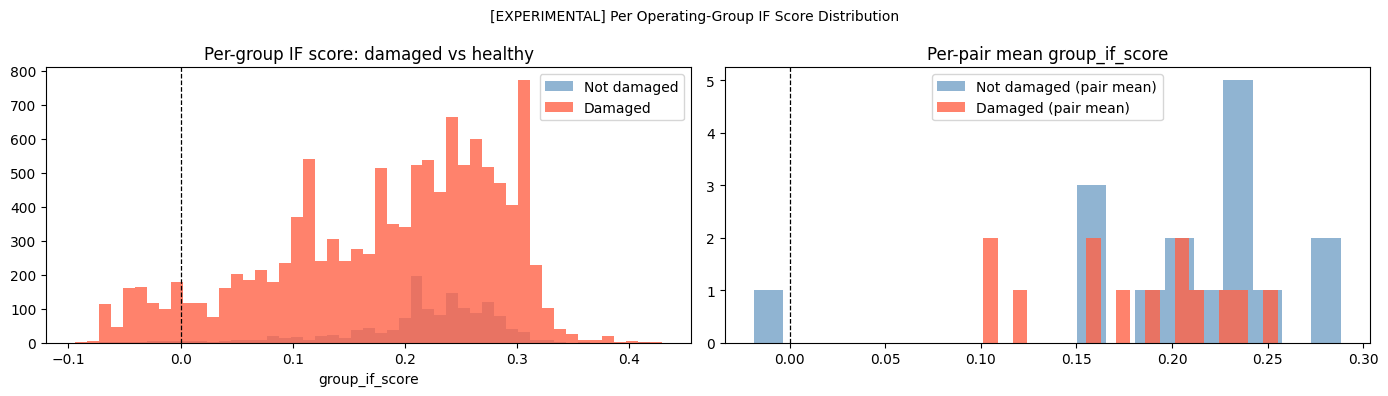

In [0]:
# ══════════════════════════════════════════════════════════════════════════════
# [EXPERIMENTAL] Per operating-group IsolationForest
# Depends on: pdf_train, pdf_test (from §6), apply_rolling()
# Produces:   group_if_models  — dict keyed by (focal_spot, kv_bucket)
#             pdf_te_group_scored — test set with group_if_score column
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.ensemble import IsolationForest as _IF

def add_kv_bucket(pdf, bucket_size=EXP_KV_BUCKET_SIZE):
    pdf = pdf.copy()
    pdf["kv_bucket"] = (pdf["hv_kv_set"] // bucket_size * bucket_size).astype(int)
    return pdf

# ── Apply rolling pre-processing (use best_rw from §8 if available, else 10) ──
_rw = int(best_overall["rolling_window"]) if "best_overall" in dir() else 10
pdf_tr_grp = add_kv_bucket(apply_rolling(pdf_train, _rw))
pdf_te_grp = add_kv_bucket(apply_rolling(pdf_test,  _rw))

# ── Train one IF per (focal_spot, kv_bucket) ──────────────────────────────────
group_if_models = {}   # key: (focal_spot, kv_bucket)  value: fitted IsolationForest
group_counts    = {}

for (fs, kvb), grp in pdf_tr_grp.groupby(["focal_spot", "kv_bucket"]):
    n = len(grp)
    group_counts[(fs, kvb)] = n
    if n < EXP_MIN_GROUP_SAMPLES:
        continue   # not enough data → fall back to global model at score time
    X_grp = grp[["filcu_a_smooth"]].values
    clf_grp = _IF(
        n_estimators=100,
        contamination=0.01,   # default; will be swept in EXP grid below
        max_samples="auto",
        random_state=42,
        n_jobs=-1
    )
    clf_grp.fit(X_grp)
    group_if_models[(fs, kvb)] = clf_grp

print(f"Trained {len(group_if_models)} group-level IFs "
      f"(out of {pdf_tr_grp.groupby(['focal_spot','kv_bucket']).ngroups} groups)")
print(f"Groups below min_samples threshold ({EXP_MIN_GROUP_SAMPLES}): "
      f"{sum(1 for v in group_counts.values() if v < EXP_MIN_GROUP_SAMPLES)}")

# ── Score test set using group IFs ────────────────────────────────────────────
# Fallback: global IF trained on filcu_a_smooth only (for groups with too few samples)
X_tr_global_1d = pdf_tr_grp[["filcu_a_smooth"]].values
global_if_1d   = _IF(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)
global_if_1d.fit(X_tr_global_1d)

def score_with_group_if(row):
    key = (row["focal_spot"], row["kv_bucket"])
    clf = group_if_models.get(key, global_if_1d)
    X   = np.array([[row["filcu_a_smooth"]]])
    return float(clf.decision_function(X)[0])

pdf_te_grp = pdf_te_grp.copy()
pdf_te_grp["group_if_score"] = pdf_te_grp.apply(score_with_group_if, axis=1)
pdf_te_grp["group_if_pred"]  = (pdf_te_grp["group_if_score"] < 0).astype(int) * -1 +                                 (pdf_te_grp["group_if_score"] >= 0).astype(int)
# group_if_pred: -1 = anomaly, +1 = normal  (consistent with sklearn convention)
pdf_te_grp["group_if_pred"] = np.where(pdf_te_grp["group_if_score"] < 0, -1, 1)

# ── Quick distribution check ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dam_mask = pdf_te_grp["is_damaged"]
bins = np.linspace(pdf_te_grp["group_if_score"].min(),
                   pdf_te_grp["group_if_score"].max(), 50)
axes[0].hist(pdf_te_grp[~dam_mask]["group_if_score"], bins=bins,
             color="steelblue", alpha=0.6, label="Not damaged")
axes[0].hist(pdf_te_grp[ dam_mask]["group_if_score"], bins=bins,
             color="tomato",    alpha=0.8, label="Damaged")
axes[0].axvline(0, color="k", ls="--", lw=0.9)
axes[0].set_xlabel("group_if_score"); axes[0].legend()
axes[0].set_title("Per-group IF score: damaged vs healthy")

# Per-pair mean score
pm = pdf_te_grp.groupby(["device_id","tube_id","is_damaged"])["group_if_score"].mean().reset_index()
axes[1].hist(pm[~pm["is_damaged"]]["group_if_score"], bins=20,
             color="steelblue", alpha=0.6, label="Not damaged (pair mean)")
axes[1].hist(pm[ pm["is_damaged"]]["group_if_score"], bins=20,
             color="tomato",    alpha=0.8, label="Damaged (pair mean)")
axes[1].axvline(0, color="k", ls="--", lw=0.9)
axes[1].legend(); axes[1].set_title("Per-pair mean group_if_score")
plt.suptitle("[EXPERIMENTAL] Per Operating-Group IF Score Distribution", fontsize=10)
plt.tight_layout(); plt.show()


## 7. Hyperparameter Grid Search
For every combination of `(rolling_window, n_estimators, max_samples, contamination, max_features)`:
1. Apply rolling mean to `filcu_a` (window=1 = raw).
2. Build feature matrix `X = [filcu_a_smooth] + selected_features`.
3. Train IsolationForest on **train set** (healthy pairs only).
4. Score **test set** per pair; apply MIN_DETECTIONS gate.
5. Compute confusion matrix → recall, FP count, mean lead time.

Best configuration = recall 100 % → fewest FP → longest mean lead time.


In [0]:
from itertools import product as iproduct

def run_grid_search(feature_list, label):
    """
    Full grid search over IF params × rolling windows for a given feature set.
    Returns a DataFrame of all results sorted by (recall DESC, fp ASC, lead_time DESC).
    """
    print(f"\n{'='*65}")
    print(f"Grid search — {label}  |  features: {feature_list}")
    print(f"{'='*65}")

    # Build full feature list including smoothed filcu_a
    full_features = ["filcu_a_smooth"] + feature_list

    records = []
    keys = list(IF_PARAM_GRID.keys())
    value_lists = [IF_PARAM_GRID[k] for k in keys]

    total_combos = (len(ROLLING_WINDOWS) *
                    sum(1 for _ in iproduct(*value_lists)))
    combo_idx = 0

    for rw in ROLLING_WINDOWS:
        # Pre-process once per rolling window
        pdf_tr_roll = apply_rolling(pdf_train, rw)
        pdf_te_roll = apply_rolling(pdf_test,  rw)

        # Encode features (fit on train, apply to test)
        X_tr, encoders = encode_features(pdf_tr_roll, full_features)
        X_te, _        = encode_features(pdf_te_roll, full_features,
                                          fit_encoders=encoders)

        for param_vals in iproduct(*value_lists):
            params = dict(zip(keys, param_vals))
            combo_idx += 1

            # ── Train ──────────────────────────────────────────────────────
            clf = IsolationForest(random_state=42, n_jobs=-1, **params)
            clf.fit(X_tr)

            # ── Score test set (row-level) ─────────────────────────────────
            # predict() → +1 inlier, -1 outlier
            # decision_function() → higher = more normal
            pdf_te_roll = pdf_te_roll.copy()
            pdf_te_roll["if_pred"]  = clf.predict(X_te)          # +1 / -1
            pdf_te_roll["if_score"] = clf.decision_function(X_te) # anomaly score

            # ── Pair-level drift detection ─────────────────────────────────
            pair_results = []
            for (did, tid), grp in pdf_te_roll.groupby(["device_id","tube_id"]):
                grp = grp.sort_values("start_time").reset_index(drop=True)
                is_damaged = bool(grp["is_damaged"].iloc[0])

                # Row-level anomaly flag (IF predicts -1 for anomalies)
                anomaly_flags = (grp["if_pred"] == -1).values
                gated         = flag_with_gate(anomaly_flags, MIN_DETECTIONS)

                if gated.any():
                    first_det_idx  = np.argmax(gated)
                    first_det_time = pd.to_datetime(grp["start_time"].iloc[first_det_idx])
                    last_time      = pd.to_datetime(grp["start_time"].iloc[-1])
                    lead_days      = (last_time - first_det_time).days
                    drift_detected = True
                else:
                    lead_days      = np.nan
                    drift_detected = False

                pair_results.append({
                    "device_id":     did,
                    "tube_id":       tid,
                    "is_damaged":    is_damaged,
                    "drift_detected": drift_detected,
                    "lead_days":     lead_days,
                })

            pr_df = pd.DataFrame(pair_results)

            # ── Confusion matrix values ────────────────────────────────────
            y_true = pr_df["is_damaged"].astype(int)
            y_pred = pr_df["drift_detected"].astype(int)
            cm     = confusion_matrix(y_true, y_pred, labels=[1, 0])
            TP, FN = cm[0, 0], cm[0, 1]
            FP, TN = cm[1, 0], cm[1, 1]
            recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
            prec   = TP / (TP + FP) if (TP + FP) > 0 else 0.0

            damaged_detected = pr_df[pr_df["is_damaged"] & pr_df["drift_detected"]]
            mean_lead = damaged_detected["lead_days"].mean() if not damaged_detected.empty else 0.0

            records.append({
                "rolling_window": rw,
                **params,
                "TP": TP, "FN": FN, "FP": FP, "TN": TN,
                "recall":    round(recall,    4),
                "precision": round(prec,      4),
                "mean_lead_days": round(mean_lead, 1) if not np.isnan(mean_lead) else 0.0,
            })

            if combo_idx % 20 == 0 or combo_idx == total_combos:
                print(f"  [{combo_idx}/{total_combos}] rw={rw} {params} "
                      f"recall={recall:.0%} FP={FP} lead={mean_lead:.0f}d")

    results_df = pd.DataFrame(records).sort_values(
        ["recall", "mean_lead_days", "FP"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    return results_df


# ── Run for both feature sets ──────────────────────────────────────────────────
grid_4 = run_grid_search(FEATURES_4, "4 Features (focal+kV+mA+pwr)")
grid_2 = run_grid_search(FEATURES_2, "2 Features (focal+kV only)")

print("\nTop-5 configurations — 4 Features:")
display(spark.createDataFrame(grid_4.head(5)))
print("\nTop-5 configurations — 2 Features:")
display(spark.createDataFrame(grid_2.head(5)))



Grid search — 4 Features (focal+kV+mA+pwr)  |  features: ['focal_spot', 'hv_kv_set', 'tucu_ma_set', 'pwr_w_reached', 'grid_voltage']
  [20/384] rw=1 {'n_estimators': 100, 'max_samples': 128, 'contamination': 0.01, 'max_features': 0.8} recall=8% FP=0 lead=61d
  [40/384] rw=1 {'n_estimators': 200, 'max_samples': 'auto', 'contamination': 0.05, 'max_features': 0.8} recall=77% FP=4 lead=147d
  [60/384] rw=1 {'n_estimators': 200, 'max_samples': 256, 'contamination': 0.01, 'max_features': 0.8} recall=0% FP=0 lead=0d
  [80/384] rw=1 {'n_estimators': 300, 'max_samples': 64, 'contamination': 0.05, 'max_features': 0.8} recall=85% FP=4 lead=150d


/root/.ipykernel/6037/command-5630547205330637-1345276283:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)
/root/.ipykernel/6037/command-5630547205330637-1345276283:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)


  [100/384] rw=5 {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.01, 'max_features': 0.8} recall=23% FP=0 lead=196d
  [120/384] rw=5 {'n_estimators': 100, 'max_samples': 128, 'contamination': 0.05, 'max_features': 0.8} recall=69% FP=2 lead=144d
  [140/384] rw=5 {'n_estimators': 200, 'max_samples': 64, 'contamination': 0.01, 'max_features': 0.8} recall=23% FP=0 lead=135d
  [160/384] rw=5 {'n_estimators': 200, 'max_samples': 256, 'contamination': 0.05, 'max_features': 0.8} recall=92% FP=2 lead=124d
  [180/384] rw=5 {'n_estimators': 300, 'max_samples': 128, 'contamination': 0.01, 'max_features': 0.8} recall=15% FP=1 lead=170d


/root/.ipykernel/6037/command-5630547205330637-1345276283:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)
/root/.ipykernel/6037/command-5630547205330637-1345276283:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)


  [200/384] rw=10 {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.05, 'max_features': 0.8} recall=92% FP=1 lead=121d
  [220/384] rw=10 {'n_estimators': 100, 'max_samples': 256, 'contamination': 0.01, 'max_features': 0.8} recall=23% FP=0 lead=186d
  [240/384] rw=10 {'n_estimators': 200, 'max_samples': 64, 'contamination': 0.05, 'max_features': 0.8} recall=100% FP=4 lead=129d
  [260/384] rw=10 {'n_estimators': 300, 'max_samples': 'auto', 'contamination': 0.01, 'max_features': 0.8} recall=23% FP=1 lead=186d
  [280/384] rw=10 {'n_estimators': 300, 'max_samples': 128, 'contamination': 0.05, 'max_features': 0.8} recall=100% FP=2 lead=124d


...

  [300/384] rw=20 {'n_estimators': 100, 'max_samples': 64, 'contamination': 0.01, 'max_features': 0.8} recall=46% FP=1 lead=197d
  [320/384] rw=20 {'n_estimators': 100, 'max_samples': 256, 'contamination': 0.05, 'max_features': 0.8} recall=100% FP=4 lead=128d
  [340/384] rw=20 {'n_estimators': 200, 'max_samples': 128, 'contamination': 0.01, 'max_features': 0.8} recall=54% FP=1 lead=165d
  [360/384] rw=20 {'n_estimators': 300, 'max_samples': 'auto', 'contamination': 0.05, 'max_features': 0.8} recall=100% FP=4 lead=128d
  [380/384] rw=20 {'n_estimators': 300, 'max_samples': 256, 'contamination': 0.01, 'max_features': 0.8} recall=54% FP=1 lead=156d
  [384/384] rw=20 {'n_estimators': 300, 'max_samples': 256, 'contamination': 0.05, 'max_features': 0.8} recall=100% FP=4 lead=128d

Top-5 configurations — 4 Features:


rolling_window,n_estimators,max_samples,contamination,max_features,TP,FN,FP,TN,recall,precision,mean_lead_days
10,200,64,0.05,0.8,13,0,4,12,1.0,0.7647,129.1
20,200,64,0.05,0.8,13,0,4,12,1.0,0.7647,128.9
20,300,64,0.05,0.8,13,0,4,12,1.0,0.7647,128.9
10,300,64,0.05,0.8,13,0,4,12,1.0,0.7647,128.8
5,300,64,0.05,0.8,13,0,4,12,1.0,0.7647,128.5



Top-5 configurations — 2 Features:


/databricks/spark/python/pyspark/sql/pandas/conversion.py:783: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Expected bytes, got a 'int' object
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


rolling_window,n_estimators,max_samples,contamination,max_features,TP,FN,FP,TN,recall,precision,mean_lead_days
10,300,auto,0.05,1.0,13,0,4,12,1.0,0.7647,133.0
10,300,256,0.05,1.0,13,0,4,12,1.0,0.7647,133.0
10,200,auto,0.05,1.0,13,0,4,12,1.0,0.7647,132.1
10,200,256,0.05,1.0,13,0,4,12,1.0,0.7647,132.1
10,100,auto,0.05,1.0,13,0,4,12,1.0,0.7647,131.5


## 8. Best Configuration & Final Model

In [0]:
def pick_best(grid_df, label):
    """
    Priority: recall=100% > fewest FP > longest mean lead time.
    Falls back to highest recall if 100% is not achievable.
    """
    perfect = grid_df[grid_df["recall"] == 1.0]
    pool    = perfect if not perfect.empty else grid_df.head(1)
    best    = pool.sort_values(["FP", "mean_lead_days"],
                                ascending=[True, False]).iloc[0]
    print(f"\nBest config — {label}")
    print(f"  rolling_window : {int(best['rolling_window'])}")
    print(f"  n_estimators   : {int(best['n_estimators'])}")
    print(f"  max_samples    : {best['max_samples']}")
    print(f"  contamination  : {best['contamination']}")
    print(f"  max_features   : {best['max_features']}")
    print(f"  recall         : {best['recall']:.0%}")
    print(f"  FP             : {int(best['FP'])}")
    print(f"  mean lead time : {best['mean_lead_days']:.1f} days")
    return best

best_4 = pick_best(grid_4, "4 Features")
best_2 = pick_best(grid_2, "2 Features")

# Choose overall best (4-feat preferred if recall is equal)
if best_4["recall"] >= best_2["recall"]:
    best_overall = best_4
    best_features = FEATURES_4
    best_label    = "4 Features"
else:
    best_overall = best_2
    best_features = FEATURES_2
    best_label    = "2 Features"

print(f"\n>>> Overall best feature set: {best_label}")



Best config — 4 Features
  rolling_window : 20
  n_estimators   : 100
  max_samples    : 128
  contamination  : 0.05
  max_features   : 1.0
  recall         : 100%
  FP             : 2
  mean lead time : 125.2 days

Best config — 2 Features
  rolling_window : 5
  n_estimators   : 100
  max_samples    : auto
  contamination  : 0.05
  max_features   : 1.0
  recall         : 100%
  FP             : 2
  mean lead time : 118.0 days

>>> Overall best feature set: 4 Features


## 9. Retrain Best Model on Full Train Set

In [0]:
best_rw = int(best_overall["rolling_window"])
full_features = ["filcu_a_smooth"] + best_features

# Pre-process
pdf_tr_best = apply_rolling(pdf_train, best_rw)
pdf_te_best = apply_rolling(pdf_test,  best_rw)

X_tr_best, best_encoders = encode_features(pdf_tr_best, full_features)
X_te_best, _             = encode_features(pdf_te_best, full_features,
                                            fit_encoders=best_encoders)

best_clf = IsolationForest(
    n_estimators  = int(best_overall["n_estimators"]),
    max_samples   = best_overall["max_samples"],
    contamination = float(best_overall["contamination"]),
    max_features  = float(best_overall["max_features"]),
    random_state  = 42,
    n_jobs        = -1,
)
best_clf.fit(X_tr_best)

# Score test set
pdf_te_best = pdf_te_best.copy()
pdf_te_best["if_pred"]  = best_clf.predict(X_te_best)
pdf_te_best["if_score"] = best_clf.decision_function(X_te_best)

print("Best model trained.")
print(f"  Feature set    : {full_features}")
print(f"  Rolling window : {best_rw}")


/root/.ipykernel/6037/command-5630547205330637-1345276283:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)
/root/.ipykernel/6037/command-5630547205330637-1345276283:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)


Best model trained.
  Feature set    : ['filcu_a_smooth', 'focal_spot', 'hv_kv_set', 'tucu_ma_set', 'pwr_w_reached', 'grid_voltage']
  Rolling window : 20


## 10. Pair-Level Drift Detection & Lead Time

In [0]:
pair_records = []
for (did, tid), grp in pdf_te_best.groupby(["device_id","tube_id"]):
    grp = grp.sort_values("start_time").reset_index(drop=True)
    is_damaged = bool(grp["is_damaged"].iloc[0])

    anomaly_flags = (grp["if_pred"] == -1).values
    gated         = flag_with_gate(anomaly_flags, MIN_DETECTIONS)

    if gated.any():
        first_idx      = np.argmax(gated)
        first_det_time = pd.to_datetime(grp["start_time"].iloc[first_idx])
        last_time      = pd.to_datetime(grp["start_time"].iloc[-1])
        lead_days      = (last_time - first_det_time).days
        drift_detected = True
    else:
        first_det_time = pd.NaT
        last_time      = pd.to_datetime(grp["start_time"].iloc[-1])
        lead_days      = np.nan
        drift_detected = False

    pair_records.append({
        "device_id":       did,
        "tube_id":         tid,
        "is_damaged":      is_damaged,
        "drift_detected":  drift_detected,
        "first_detection": first_det_time,
        "last_filcu_a":    last_time,
        "lead_days":       lead_days,
    })

pair_df = pd.DataFrame(pair_records)

# ── Confusion matrix ───────────────────────────────────────────────────────────
y_true = pair_df["is_damaged"].astype(int)
y_pred = pair_df["drift_detected"].astype(int)
cm     = confusion_matrix(y_true, y_pred, labels=[1, 0])
TP, FN = cm[0, 0], cm[0, 1]
FP, TN = cm[1, 0], cm[1, 1]
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
prec   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
f1     = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0.0

print(f"Recall (damaged) : {recall:.1%}   TP={TP}  FN={FN}")
print(f"Precision        : {prec:.1%}     FP={FP}  TN={TN}")
print(f"F1               : {f1:.3f}")

# Display detection details for damaged pairs
dam_det = pair_df[pair_df["is_damaged"]][[
    "device_id","tube_id","drift_detected","first_detection","last_filcu_a","lead_days"
]]
print("\nDamaged pairs — detection details:")
display(spark.createDataFrame(dam_det))


Recall (damaged) : 100.0%   TP=13  FN=0
Precision        : 86.7%     FP=2  TN=14
F1               : 0.929

Damaged pairs — detection details:


device_id,tube_id,drift_detected,first_detection,last_filcu_a,lead_days
t3-1678901-1966,1674634,true,2023-08-01T18:08:15.117468Z,2023-09-15T11:31:20.093104Z,44.0
t3-1817879-52,1810944,true,2023-08-23T20:01:42.443234Z,2023-09-08T13:35:02.283879Z,15.0
t3-1829086-180,1939694,true,2024-08-26T09:53:28.905886Z,2025-07-15T10:45:55.971137Z,323.0
t3-1830503-165,1823505,true,2023-12-06T09:39:51.09332Z,2024-01-12T17:03:20.545506Z,37.0
t3-1831151-186,1824362,true,2024-01-11T13:46:47.56451Z,2024-08-28T03:02:00.81339Z,229.0
t3-1882150-500,1864990,true,2024-02-14T11:24:54.915146Z,2024-04-12T16:00:08.629108Z,58.0
t3-1882151-611,1853962,true,2024-12-17T10:33:21.468376Z,2025-05-27T11:31:03.481158Z,161.0
t3-1991730-874,1977123,true,2024-10-23T13:15:58.7441Z,2024-11-20T18:11:12.132577Z,28.0
t3-1993491-843,1950888,true,2024-10-17T12:06:52.550338Z,2024-11-04T10:19:45.568065Z,17.0
t3-2002-1557,1392867,true,2022-06-24T10:09:44.33573Z,2023-05-25T10:34:23.809131Z,335.0


## 10b. [EXPERIMENTAL] Pair-Specific Score Calibration + CUSUM

**Analogue to regression's "first N residuals as baseline":**

In regression, the first N residuals per pair anchor that pair's individual healthy
level. Everything after that is measured as *deviation from that pair's own baseline*.

Here we do the same with the IF anomaly score:
1. Take the first `EXP_BASELINE_N` samples of each test pair.
2. Compute their mean and std IF score → `pair_score_mean`, `pair_score_std`.
3. Define an adaptive per-pair alarm threshold: `pair_score_mean − EXP_SCORE_SIGMA × pair_score_std`.
4. Any subsequent sample with score below this threshold is flagged as anomalous.
5. Run one-sided **CUSUM** on the *negative adjusted score* (`−(score − pair_score_mean)`)
   to detect sustained downward trends (= rising anomaly), not just spikes.

This works because drift is **always positive** in filcu_a → always negative in IF score.
The CUSUM accumulates evidence of a sustained shift before firing, so single noisy
low-score samples don't trigger an alarm.


/root/.ipykernel/6037/command-5630547205330651-2715341459:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf_te.groupby(["device_id","tube_id"], group_keys=False).apply(_calibrate)
/root/.ipykernel/6037/command-5630547205330651-2715341459:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf_te.groupby(["device_id","tube_id"], group_keys=False).apply(_calibrate)


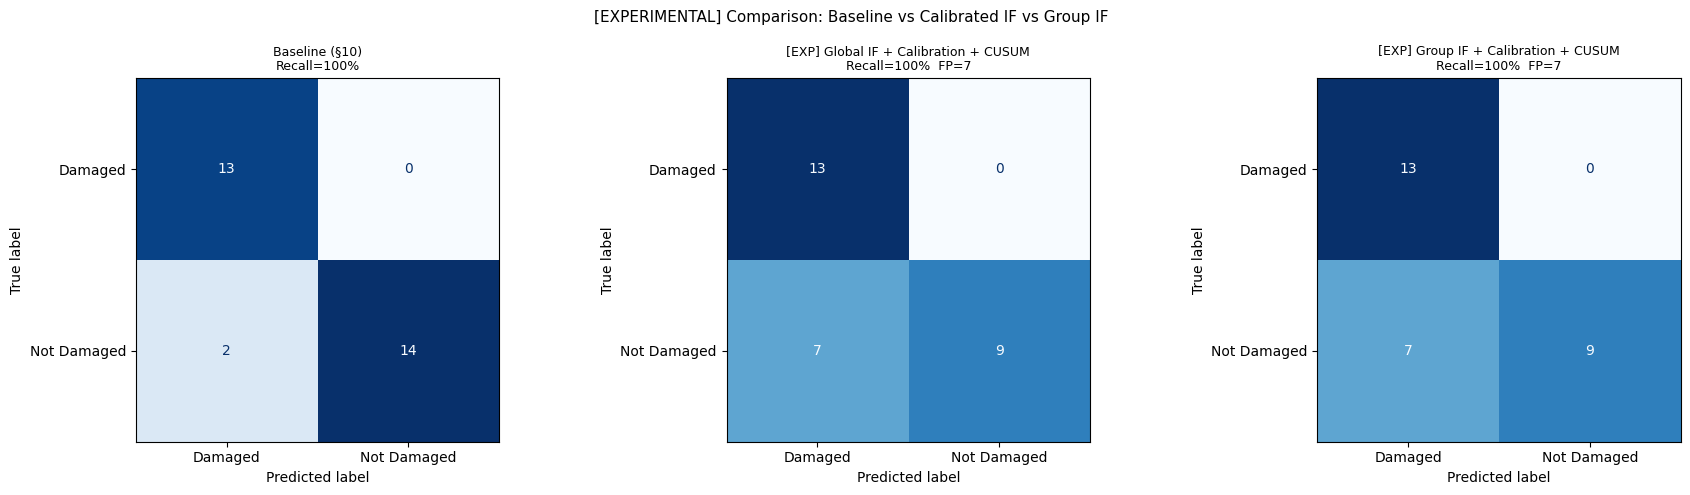

Baseline recall      : 100%
Global IF + CUSUM    : 100%  FP=7
Group  IF + CUSUM    : 100%  FP=7


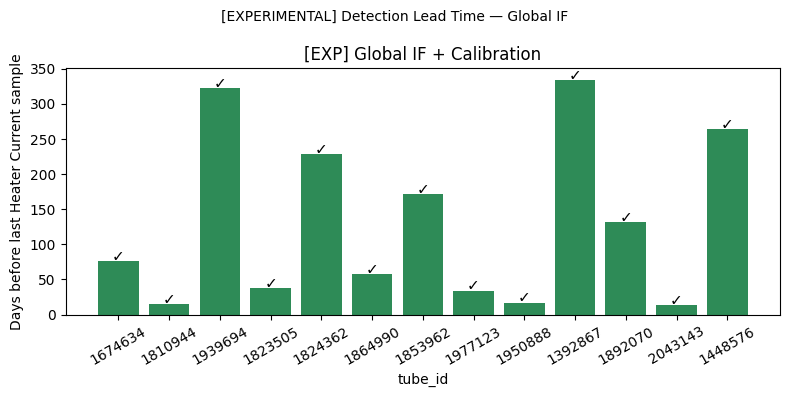

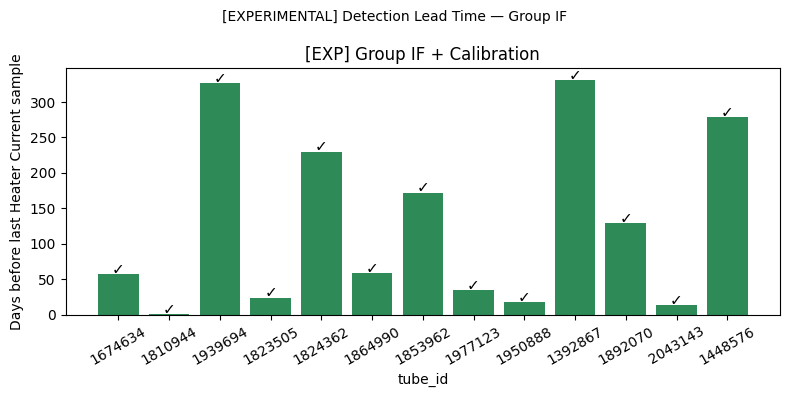


[EXP] Group IF results — damaged pairs:


device_id,tube_id,is_damaged,drift_detected,first_detection,last_filcu_a,lead_days
t3-1678901-1966,1674634,true,true,2023-07-19T13:23:48.208174Z,2023-09-15T11:31:20.093104Z,57.0
t3-1817879-52,1810944,true,true,2023-09-06T18:07:54.359473Z,2023-09-08T13:35:02.283879Z,1.0
t3-1829086-180,1939694,true,true,2024-08-22T07:26:13.134464Z,2025-07-15T10:45:55.971137Z,327.0
t3-1830503-165,1823505,true,true,2023-12-19T10:21:10.182256Z,2024-01-12T17:03:20.545506Z,24.0
t3-1831151-186,1824362,true,true,2024-01-10T14:14:38.296174Z,2024-08-28T03:02:00.81339Z,230.0
t3-1882150-500,1864990,true,true,2024-02-14T13:47:31.934805Z,2024-04-12T16:00:08.629108Z,58.0
t3-1882151-611,1853962,true,true,2024-12-06T10:47:44.177375Z,2025-05-27T11:31:03.481158Z,172.0
t3-1991730-874,1977123,true,true,2024-10-17T15:32:57.556862Z,2024-11-20T18:11:12.132577Z,34.0
t3-1993491-843,1950888,true,true,2024-10-17T13:22:33.593481Z,2024-11-04T10:19:45.568065Z,17.0
t3-2002-1557,1392867,true,true,2022-06-27T13:10:55.731176Z,2023-05-25T10:34:23.809131Z,331.0


In [0]:
# ══════════════════════════════════════════════════════════════════════════════
# [EXPERIMENTAL] Pair-specific score calibration + CUSUM on IF score
# Depends on: pdf_te_best (from §9), pdf_te_grp (from §6b)
# Can run independently on EITHER the global-IF scored data OR group-IF scored data.
# ══════════════════════════════════════════════════════════════════════════════

def calibrate_and_cusum(pdf_te, score_col="if_score",
                        baseline_n=EXP_BASELINE_N,
                        score_sigma=EXP_SCORE_SIGMA,
                        cusum_k_factor=EXP_CUSUM_K_FACTOR,
                        cusum_h_factor=EXP_CUSUM_H_FACTOR,
                        min_det=EXP_MIN_DETECTIONS):
    """
    For each (device_id, tube_id) pair:
      1. Calibrate: compute mean/std of score_col over first baseline_n samples.
      2. Adaptive threshold: mean - score_sigma * std
      3. CUSUM on negative adjusted score (rising anomaly = falling IF score)

    Returns augmented DataFrame with columns:
      pair_score_mean, pair_score_std, score_adj, score_threshold,
      adaptive_alarm, cusum_score, cusum_alarm, any_exp_alarm
    """
    def _calibrate(g):
        g = g.sort_values("start_time").reset_index(drop=True).copy()
        n = min(baseline_n, len(g))

        early_scores      = g[score_col].values[:n]
        pair_mean         = np.mean(early_scores)
        pair_std          = np.std(early_scores) if n > 1 else 1e-6
        if pair_std < 1e-6:
            pair_std = 1e-6

        g["pair_score_mean"] = pair_mean
        g["pair_score_std"]  = pair_std
        # Adaptive threshold: fire when score drops this far below healthy baseline
        threshold            = pair_mean - score_sigma * pair_std
        g["score_threshold"] = threshold
        # Adjusted score: 0 at baseline, negative = anomalous
        g["score_adj"]       = g[score_col].values - pair_mean

        # ── Adaptive threshold alarm ──────────────────────────────────────────
        raw_adp   = g[score_col].values < threshold
        consec    = np.zeros(len(g), dtype=int)
        for i in range(len(g)):
            consec[i] = (consec[i-1]+1) if (i>0 and raw_adp[i]) else (1 if raw_adp[i] else 0)
        g["adaptive_alarm"] = consec >= min_det

        # ── CUSUM on negative adjusted score ──────────────────────────────────
        # negate: rising anomaly (filcu_a up → score down → -score_adj up)
        r       = -g["score_adj"].values
        k_abs   = cusum_k_factor * pair_std
        h_abs   = cusum_h_factor * pair_std
        S       = np.zeros(len(g))
        neg_run = 0
        for i in range(1, len(g)):
            neg_run = neg_run + 1 if r[i] < 0 else 0
            if neg_run >= 5:   # reset after 5 consecutive non-anomalous samples
                S[i] = 0.0
                neg_run = 0
            else:
                S[i] = max(0.0, S[i-1] + r[i] - k_abs)
        g["cusum_score"] = S
        raw_cus  = S > h_abs
        consec2  = np.zeros(len(g), dtype=int)
        for i in range(len(g)):
            consec2[i] = (consec2[i-1]+1) if (i>0 and raw_cus[i]) else (1 if raw_cus[i] else 0)
        g["cusum_alarm"]   = consec2 >= min_det
        g["any_exp_alarm"] = g["adaptive_alarm"] | g["cusum_alarm"]
        return g

    return pdf_te.groupby(["device_id","tube_id"], group_keys=False).apply(_calibrate)


# ── Run on BOTH global-IF and group-IF scored test data ───────────────────────
pdf_te_cal_global = calibrate_and_cusum(pdf_te_best.copy(),   score_col="if_score")
pdf_te_cal_group  = calibrate_and_cusum(pdf_te_grp.copy(),    score_col="group_if_score")

def exp_pair_detection(pdf_te_cal, alarm_col="any_exp_alarm"):
    records = []
    for (did, tid), g in pdf_te_cal.groupby(["device_id","tube_id"]):
        g = g.sort_values("start_time").reset_index(drop=True)
        is_damaged = bool(g["is_damaged"].iloc[0])
        fired = g[alarm_col]
        if fired.any():
            first_t  = pd.to_datetime(g["start_time"].iloc[fired.values.argmax()])
            last_t   = pd.to_datetime(g["start_time"].iloc[-1])
            lead     = (last_t - first_t).days
            detected = True
        else:
            first_t  = pd.NaT
            last_t   = pd.to_datetime(g["start_time"].iloc[-1])
            lead     = np.nan
            detected = False
        records.append({"device_id":did,"tube_id":tid,"is_damaged":is_damaged,
                        "drift_detected":detected,"first_detection":first_t,
                        "last_filcu_a":last_t,"lead_days":lead})
    return pd.DataFrame(records)

exp_pair_global = exp_pair_detection(pdf_te_cal_global)
exp_pair_group  = exp_pair_detection(pdf_te_cal_group)

# ── Confusion matrices side by side ───────────────────────────────────────────
def cm_metrics(pair_df_):
    yt = pair_df_["is_damaged"].astype(int)
    yp = pair_df_["drift_detected"].astype(int)
    cm_ = confusion_matrix(yt, yp, labels=[1,0])
    TP,FN = cm_[0,0],cm_[0,1]; FP,TN = cm_[1,0],cm_[1,1]
    rec = TP/(TP+FN) if (TP+FN)>0 else 0
    pre = TP/(TP+FP) if (TP+FP)>0 else 0
    return cm_, rec, pre, TP, FN, FP, TN

cm_base,   rec_base,   pre_base,   *_  = cm_metrics(pair_df)          # from §10
cm_global, rec_global, pre_global, *_  = cm_metrics(exp_pair_global)
cm_group,  rec_group,  pre_group,  *_  = cm_metrics(exp_pair_group)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cm_, title_, rec_, pre_ in [
    (axes[0], cm_base,   f"Baseline (§10)\nRecall={rec_base:.0%}", rec_base, pre_base),
    (axes[1], cm_global, f"[EXP] Global IF + Calibration + CUSUM\nRecall={rec_global:.0%}  FP={int(cm_global[1,0])}", rec_global, pre_global),
    (axes[2], cm_group,  f"[EXP] Group IF + Calibration + CUSUM\nRecall={rec_group:.0%}  FP={int(cm_group[1,0])}", rec_group, pre_group),
]:
    ConfusionMatrixDisplay(cm_, display_labels=["Damaged","Not Damaged"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title_, fontsize=9)

plt.suptitle("[EXPERIMENTAL] Comparison: Baseline vs Calibrated IF vs Group IF", fontsize=11)
plt.tight_layout(); plt.show()

print(f"Baseline recall      : {rec_base:.0%}")
print(f"Global IF + CUSUM    : {rec_global:.0%}  FP={int(cm_global[1,0])}")
print(f"Group  IF + CUSUM    : {rec_group:.0%}  FP={int(cm_group[1,0])}")

# ── Lead time chart for both experimental variants ─────────────────────────────
# All outputs must be checked, this is offered as guidance only and should not be used as is without careful review.
# This is the COMET data platform databricks development workspace, data might be changing and unreliable.

# Plot for Global IF + Calibration
fig, ax = plt.subplots(figsize=(8, 4))
dam_ = exp_pair_global[exp_pair_global["is_damaged"]]
colors_ = dam_["drift_detected"].map({True:"seagreen",False:"tomato"})
bars_ = ax.bar(dam_["tube_id"], dam_["lead_days"].fillna(0), color=colors_)
for bar, row in zip(bars_, dam_.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            "✓" if row.drift_detected else "✗", ha="center", fontsize=11)
ax.set_title("[EXP] Global IF + Calibration")
ax.set_xlabel("tube_id")
ax.set_ylabel("Days before last Heater Current sample")
ax.tick_params(axis="x", rotation=30)
plt.suptitle("[EXPERIMENTAL] Detection Lead Time — Global IF", fontsize=10)
plt.tight_layout()
plt.show()

# Plot for Group IF + Calibration
fig, ax = plt.subplots(figsize=(8, 4))
dam_ = exp_pair_group[exp_pair_group["is_damaged"]]
colors_ = dam_["drift_detected"].map({True:"seagreen",False:"tomato"})
bars_ = ax.bar(dam_["tube_id"], dam_["lead_days"].fillna(0), color=colors_)
for bar, row in zip(bars_, dam_.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            "✓" if row.drift_detected else "✗", ha="center", fontsize=11)
ax.set_title("[EXP] Group IF + Calibration")
ax.set_xlabel("tube_id")
ax.set_ylabel("Days before last Heater Current sample")
ax.tick_params(axis="x", rotation=30)
plt.suptitle("[EXPERIMENTAL] Detection Lead Time — Group IF", fontsize=10)
plt.tight_layout()
plt.show()

# Print damaged-pair detail
print("\n[EXP] Group IF results — damaged pairs:")
display(spark.createDataFrame(
    exp_pair_group[exp_pair_group["is_damaged"]]
))

## 11. Confusion Matrix

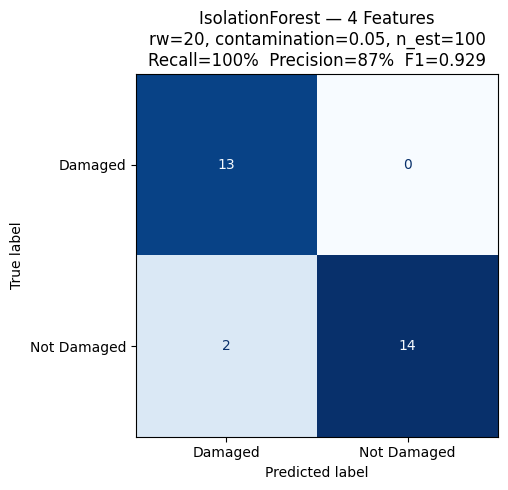

In [0]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["Damaged", "Not Damaged"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(
    f"IsolationForest — {best_label}\n"
    f"rw={best_rw}, contamination={best_overall['contamination']}, "
    f"n_est={int(best_overall['n_estimators'])}\n"
    f"Recall={recall:.0%}  Precision={prec:.0%}  F1={f1:.3f}"
)
plt.tight_layout()
plt.show()


## 12. Detection Lead Time — Damaged Pairs
Bars show days from first drift detection to last available `filcu_a` (heater current) sample.

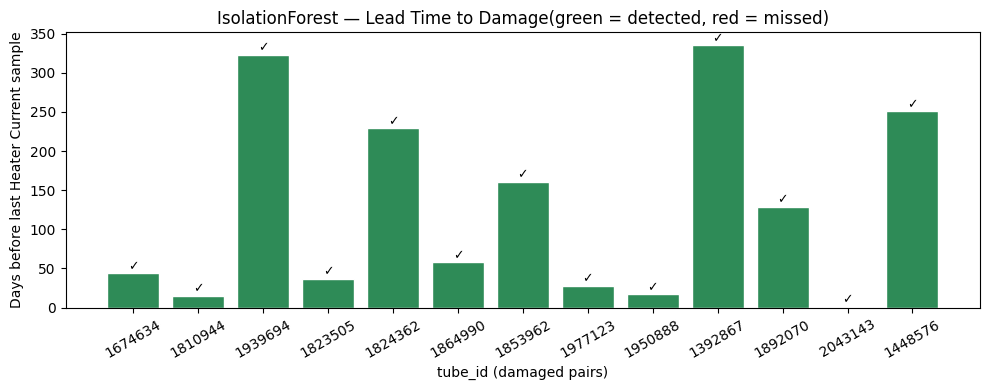

Mean lead time (detected): 125.2 days
Median lead time (detected): 58.0 days
Min  lead time (detected): 1.0 days


In [0]:
# All outputs must be checked, this is offered as guidance only and should not be used as is without careful review.  
# This is the COMET data platform databricks development workspace, data might be changing and unreliable.

fig, ax = plt.subplots(figsize=(10, 4))
dam = pair_df[pair_df["is_damaged"]].copy()
dam["label"] = dam["tube_id"]
colors = dam["drift_detected"].map({True: "seagreen", False: "tomato"})
bars = ax.bar(dam["label"], dam["lead_days"].fillna(0), color=colors, edgecolor="white")

for bar, row in zip(bars, dam.itertuples()):
    mark = "✓" if row.drift_detected else "✗ missed"
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5, mark,
            ha="center", va="bottom", fontsize=9)

ax.set_xlabel("tube_id (damaged pairs)")
ax.set_ylabel("Days before last Heater Current sample")
ax.set_title("IsolationForest — Lead Time to Damage(green = detected, red = missed)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print(f"Mean lead time (detected): {dam[dam['drift_detected']]['lead_days'].mean():.1f} days")
print(f"Median lead time (detected): {dam[dam['drift_detected']]['lead_days'].median():.1f} days")
print(f"Min  lead time (detected): {dam[dam['drift_detected']]['lead_days'].min():.1f} days")

# All outputs must be checked, this is offered as guidance only and should not be used as is without careful review.  
# This is the COMET data platform databricks development workspace, data might be changing and unreliable.

## 13. Anomaly Score Over Time — All Test Pairs
Each panel shows the IF `decision_function` score (lower = more anomalous) with the detection threshold at 0.

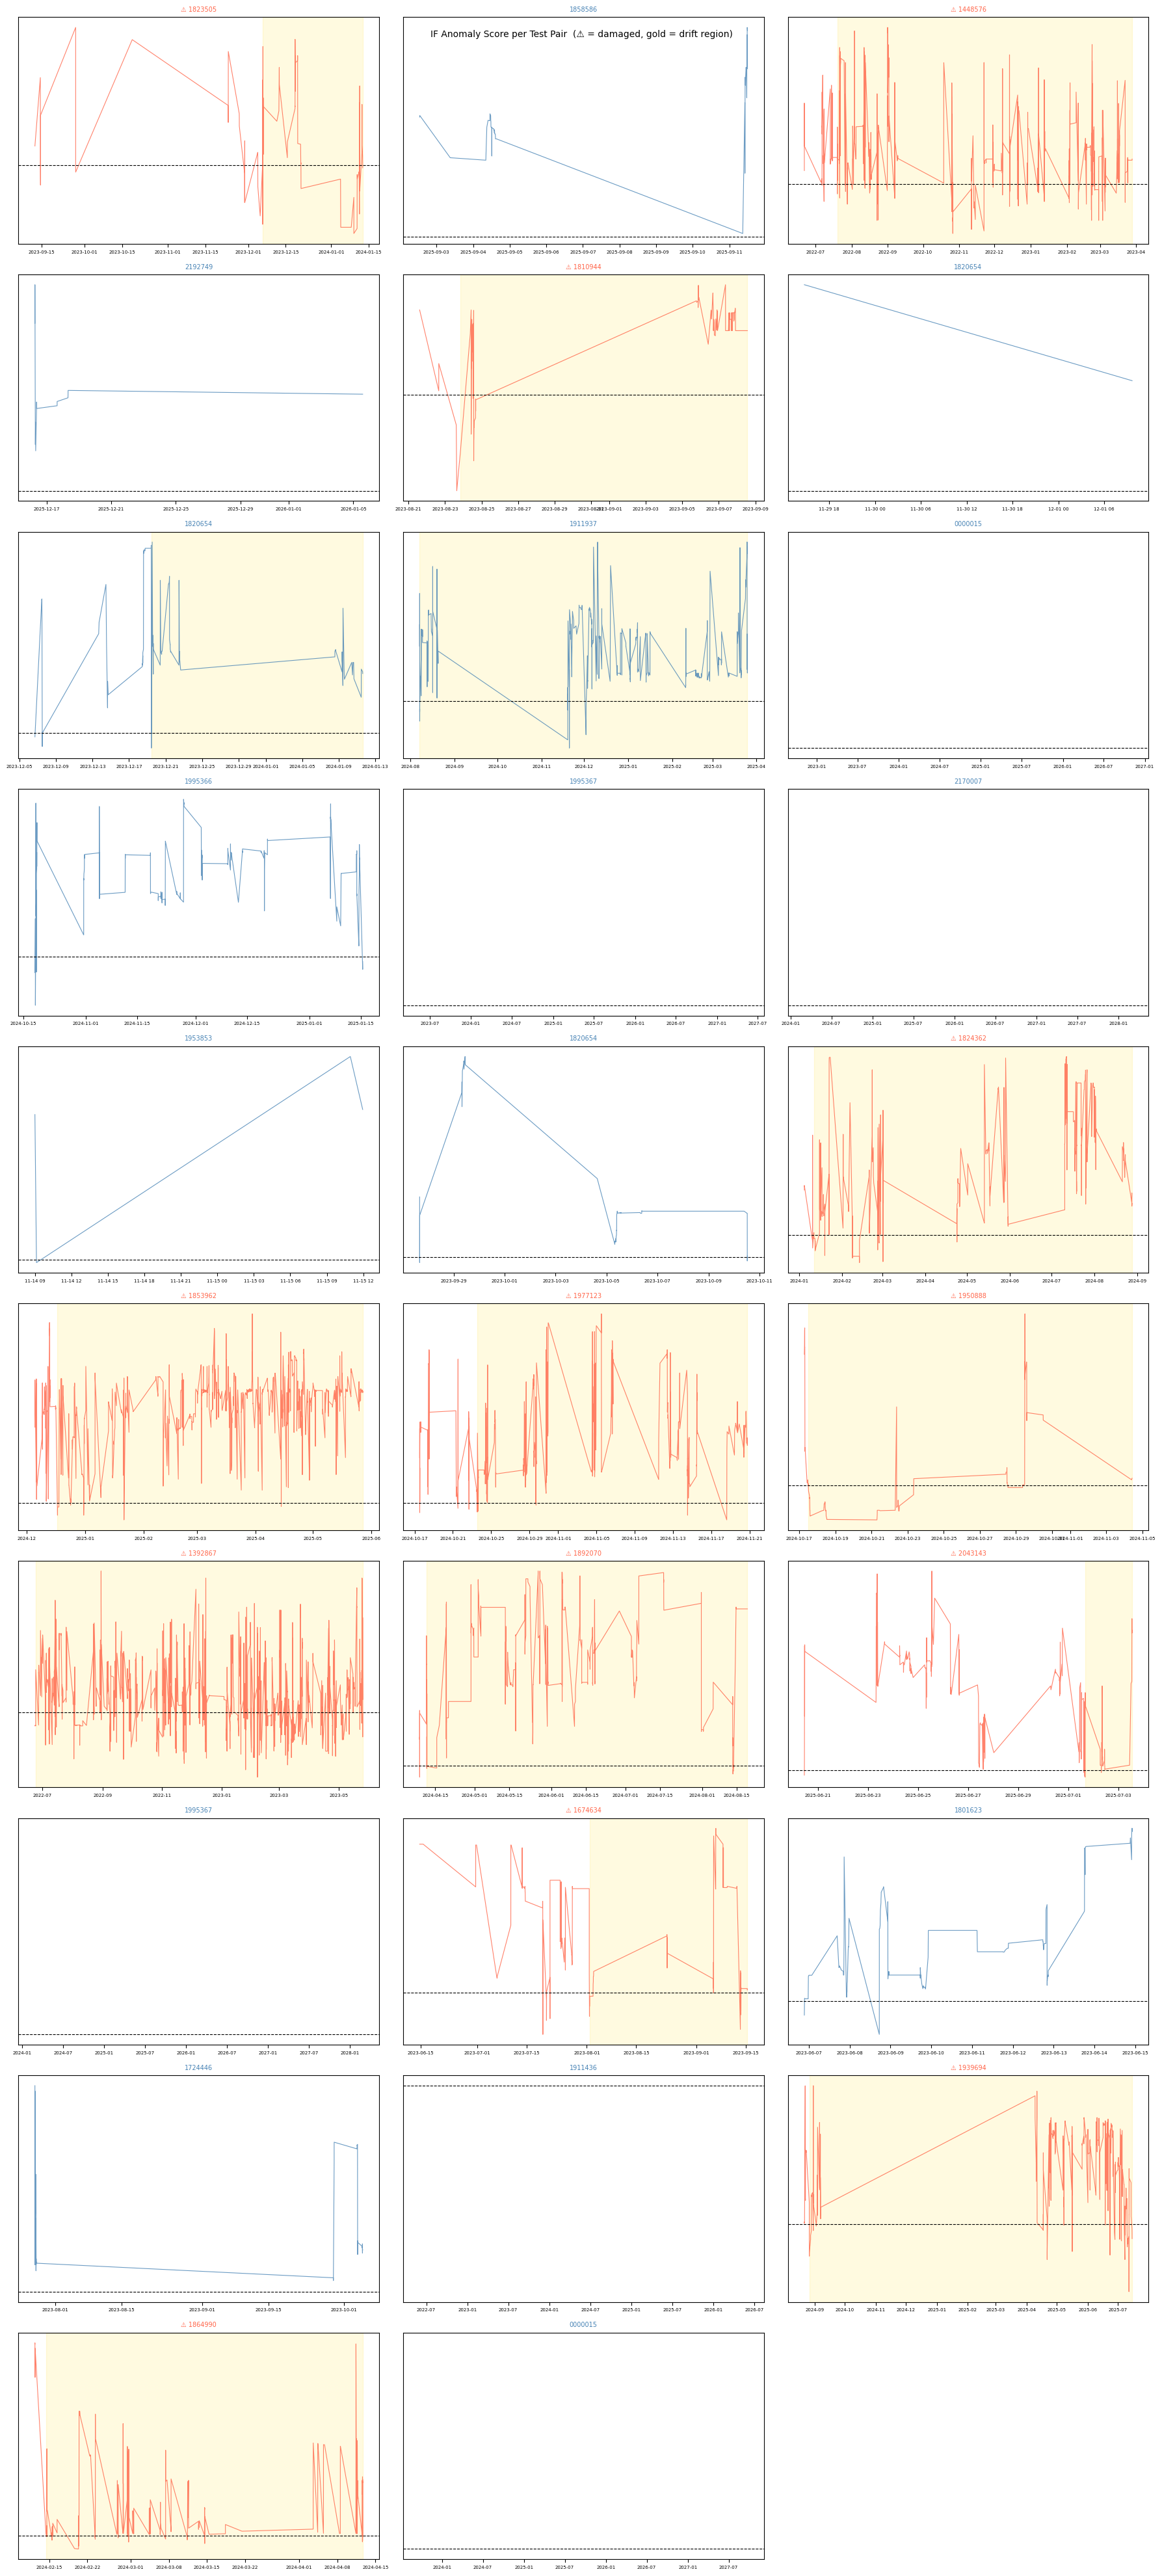

In [0]:
pair_ids = pdf_te_best[["device_id","tube_id","is_damaged"]].drop_duplicates()
n        = len(pair_ids)
ncols    = 3
nrows    = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = np.array(axes).flatten()

for idx, (_, row) in enumerate(pair_ids.iterrows()):
    grp = pdf_te_best[
        (pdf_te_best["device_id"] == row["device_id"]) &
        (pdf_te_best["tube_id"]   == row["tube_id"])
    ].sort_values("start_time")

    ax    = axes[idx]
    t     = pd.to_datetime(grp["start_time"])
    color = "tomato" if row["is_damaged"] else "steelblue"

    ax.plot(t, grp["if_score"], lw=0.8, color=color, alpha=0.8)
    ax.axhline(0, color="k", linestyle="--", lw=0.8, label="threshold (0)")

    # Shade drift region
    gated = flag_with_gate((grp["if_pred"] == -1).values, MIN_DETECTIONS)
    if gated.any():
        t_arr = t.values
        ax.axvspan(t_arr[np.argmax(gated)], t_arr[-1],
                   alpha=0.12, color="gold", label="drift region")

    prefix = "⚠ " if row["is_damaged"] else ""
    ax.set_title(f"{prefix}{row['tube_id']}", fontsize=7, color=color)
    ax.tick_params(labelsize=5)
    ax.set_yticks([])

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("IF Anomaly Score per Test Pair  (⚠ = damaged, gold = drift region)", fontsize=10)
plt.tight_layout()
plt.show()


## 14. Deep Dive — Each Damaged Pair
Shows raw `filcu_a` (heater current), smoothed signal, anomaly score, and drift flag over time.

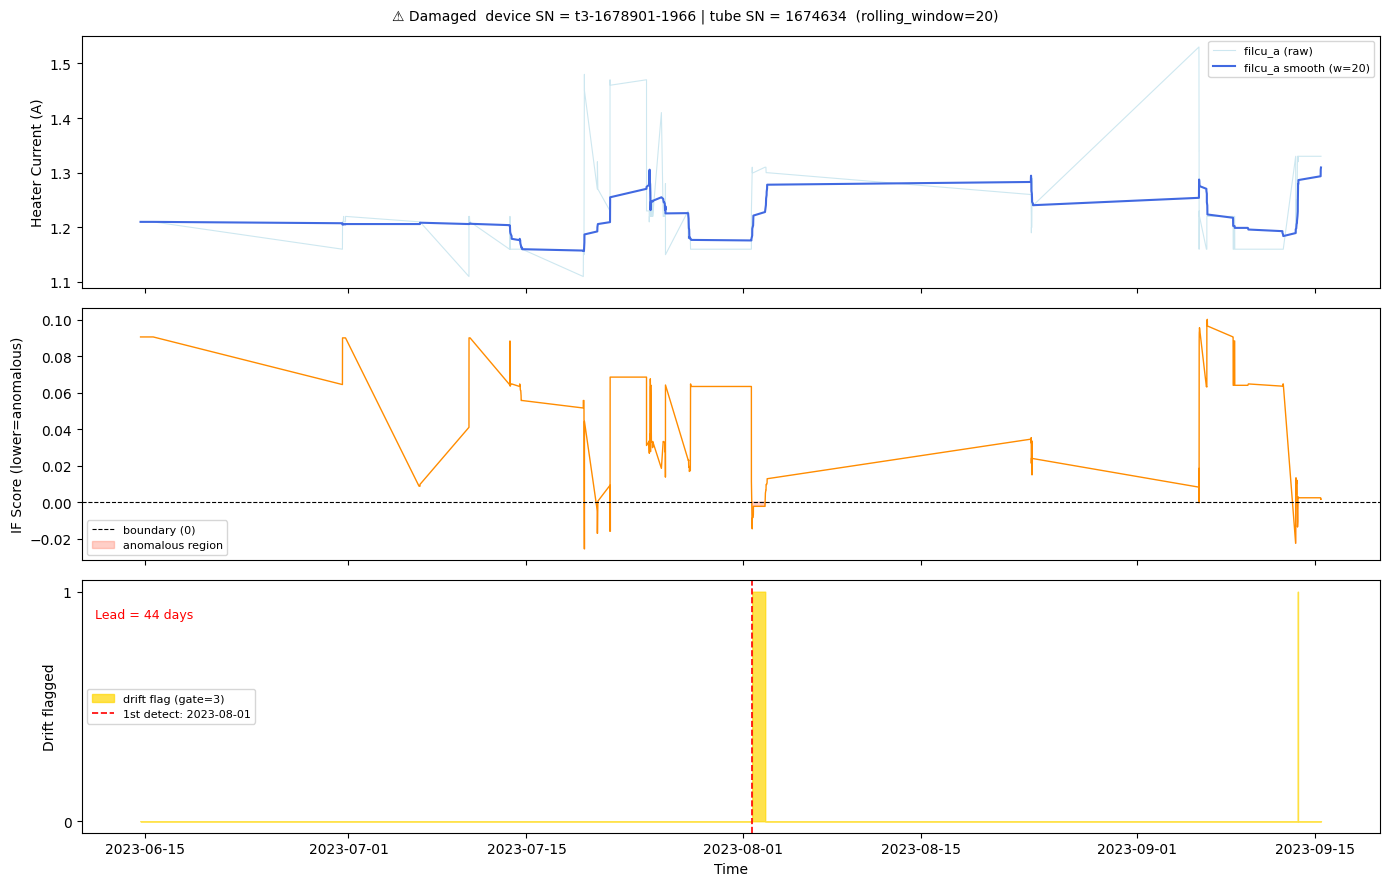

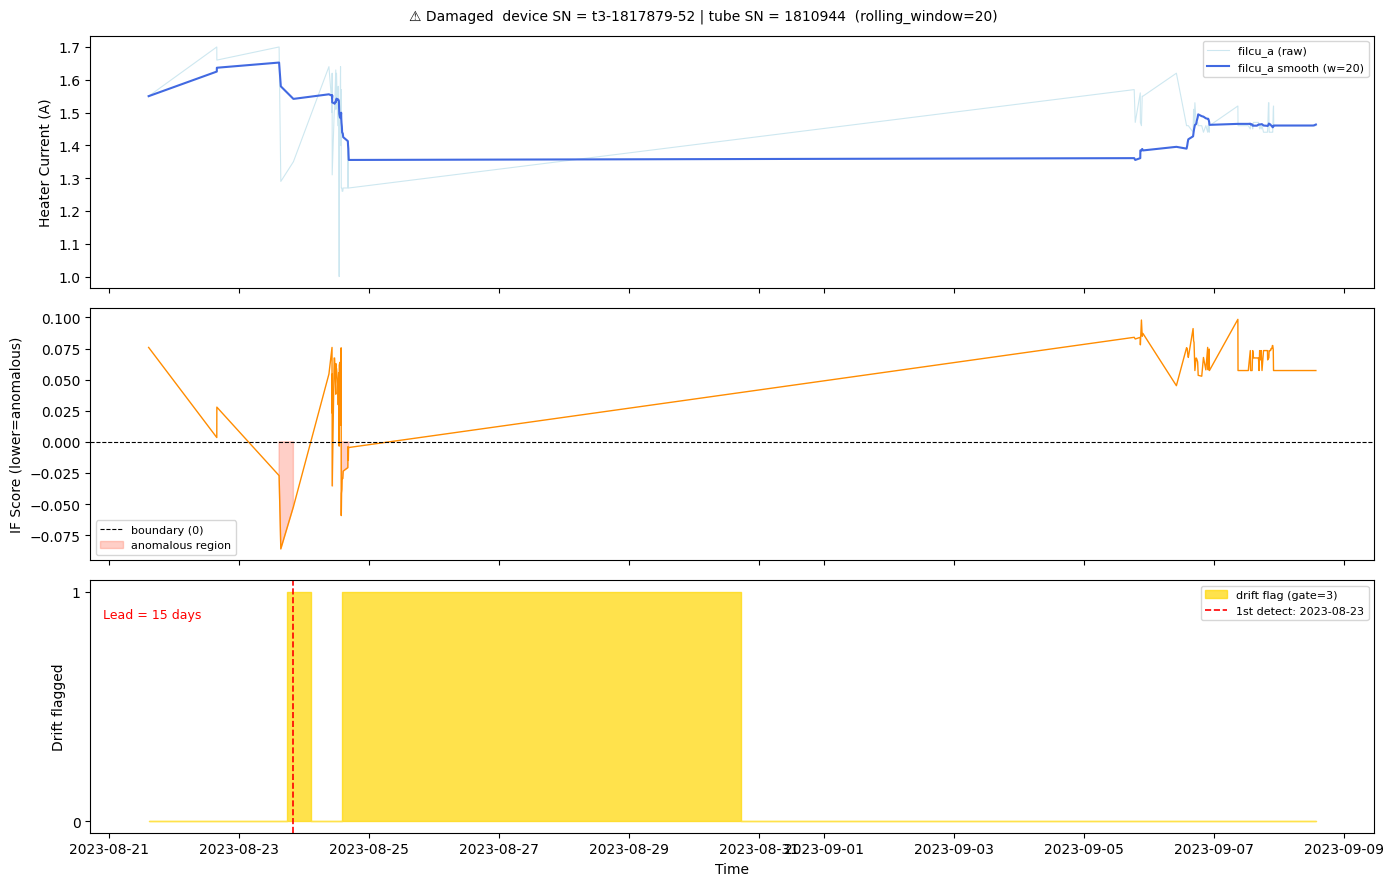

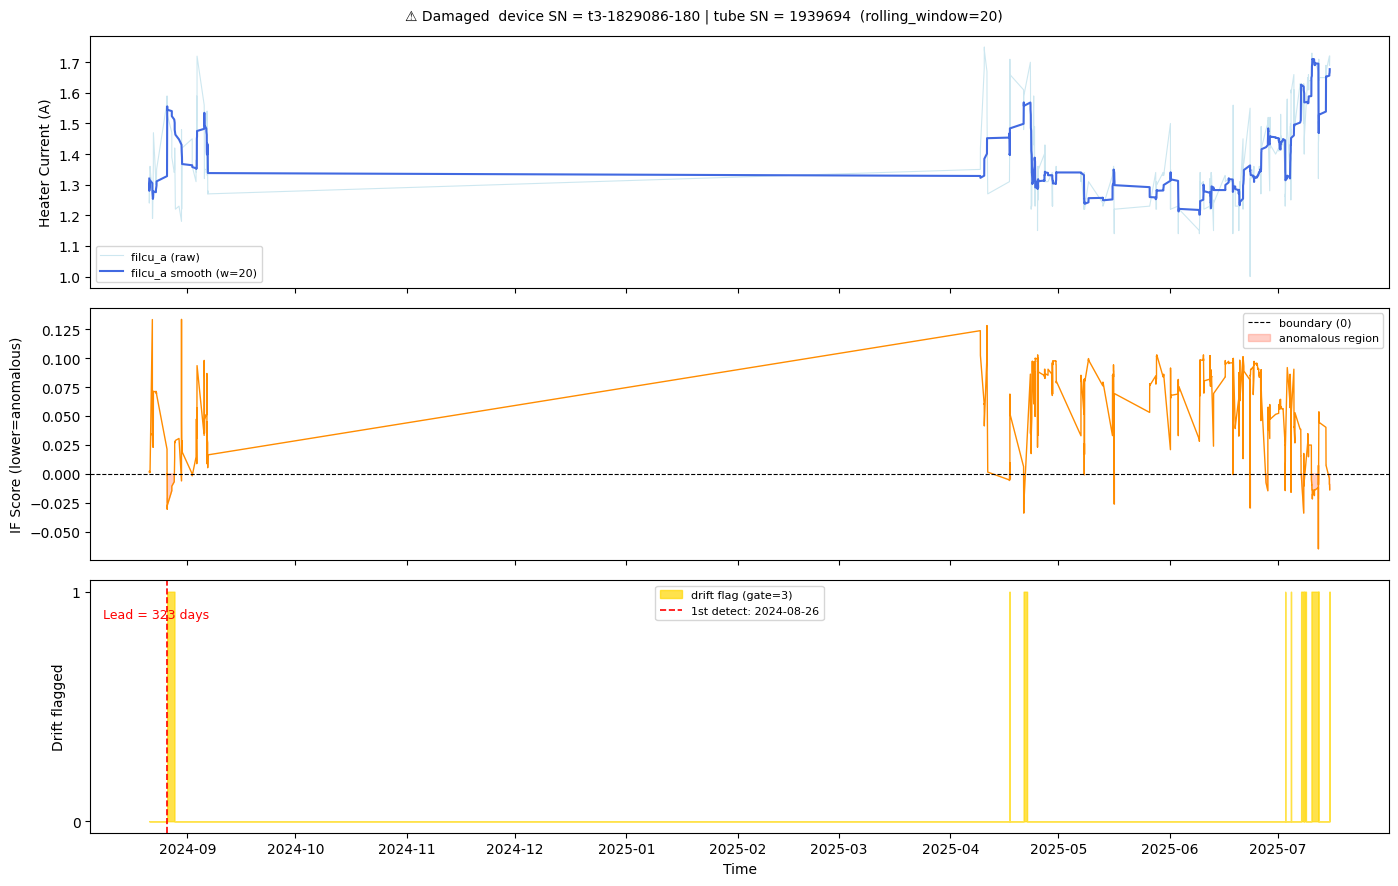

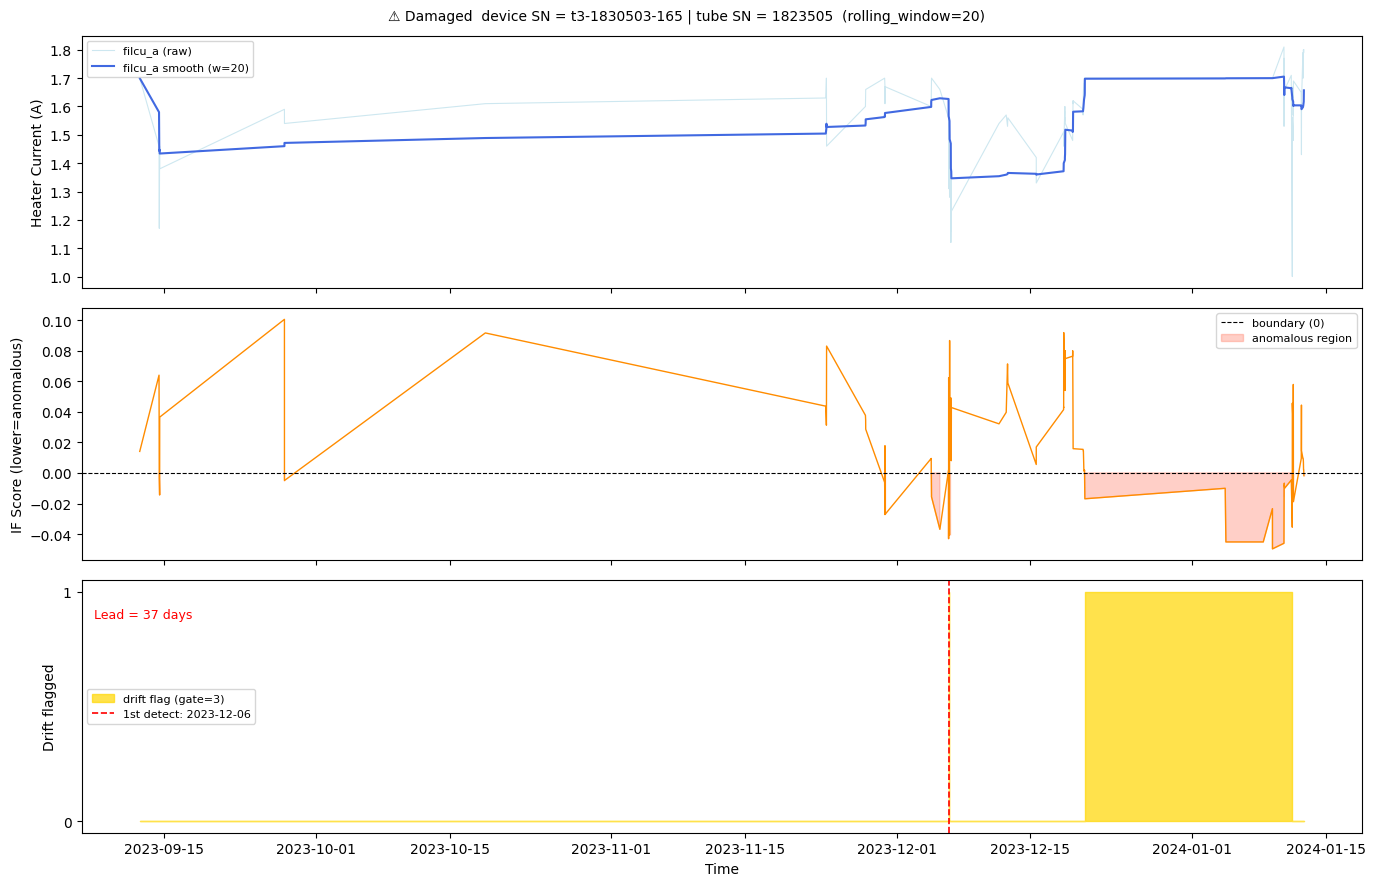

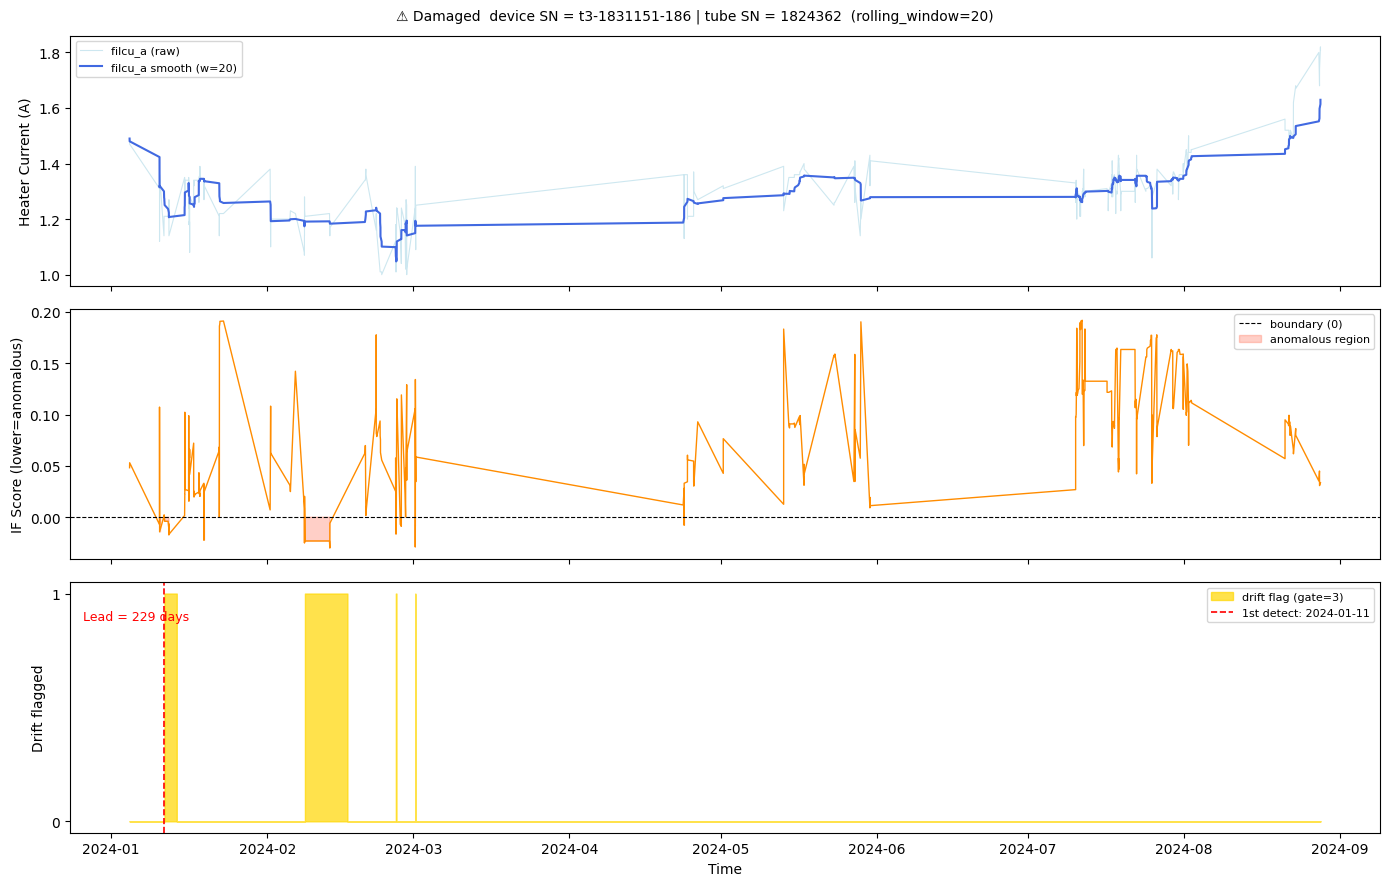

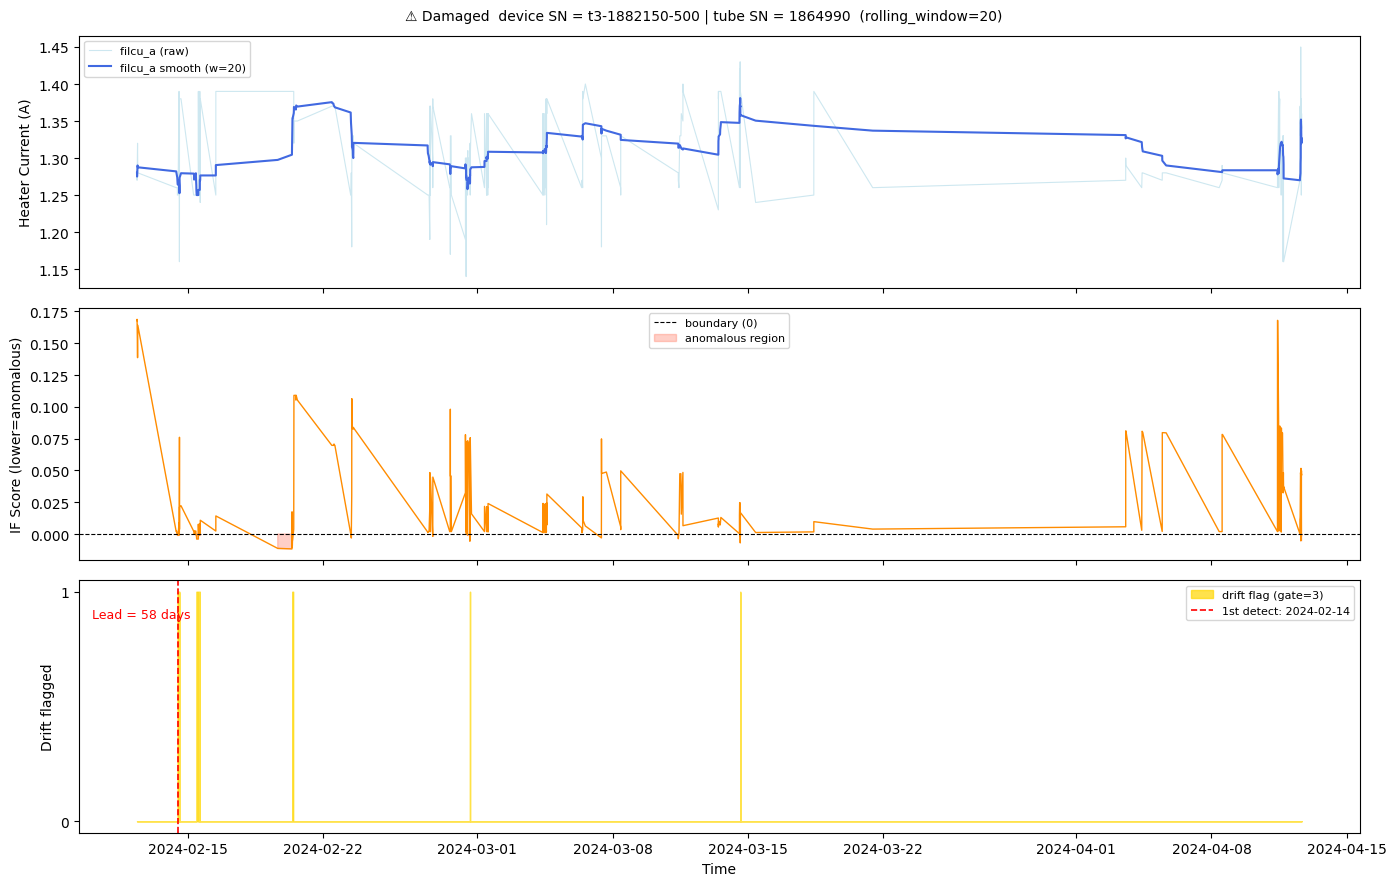

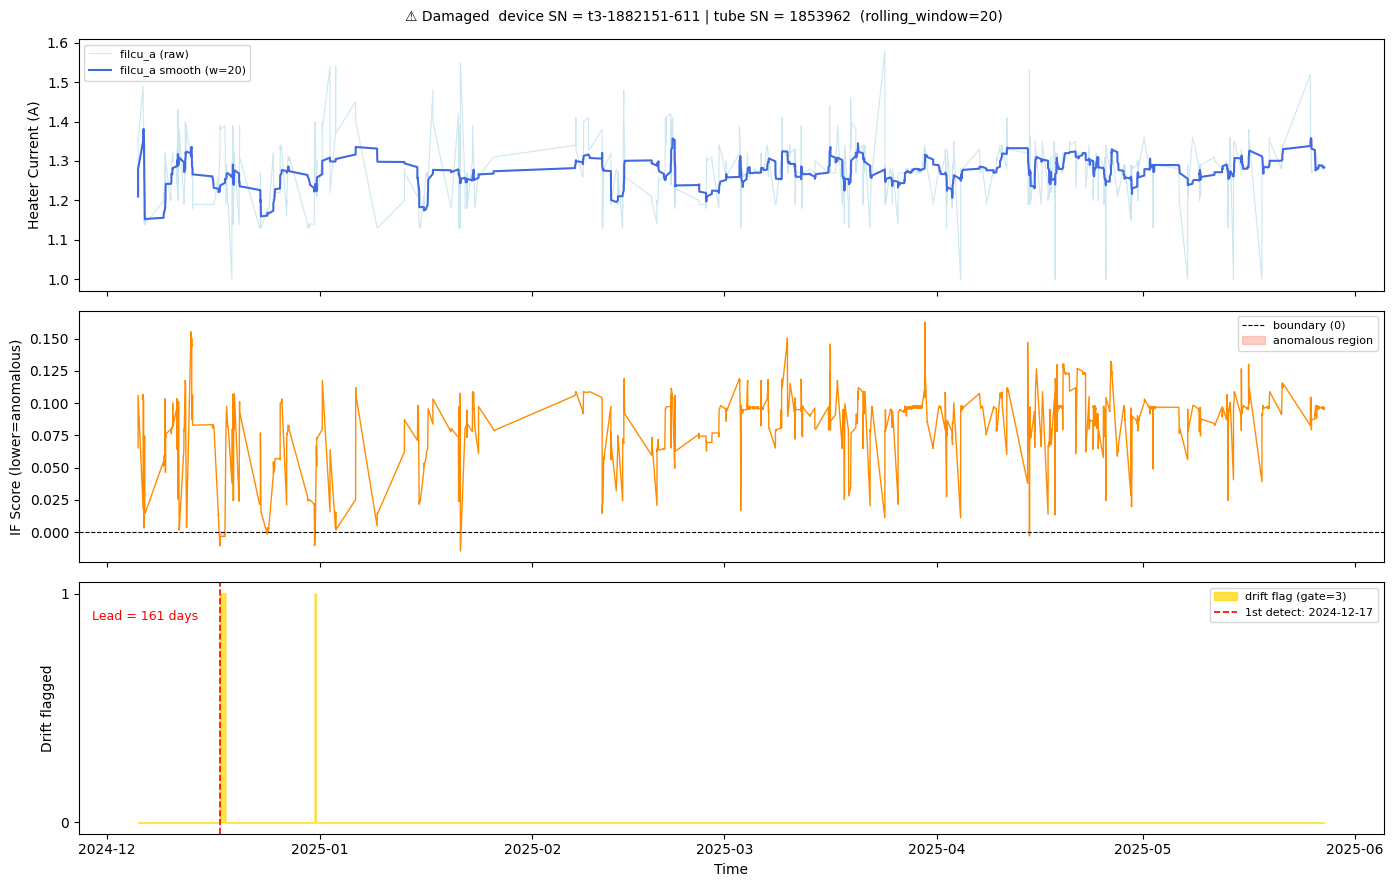

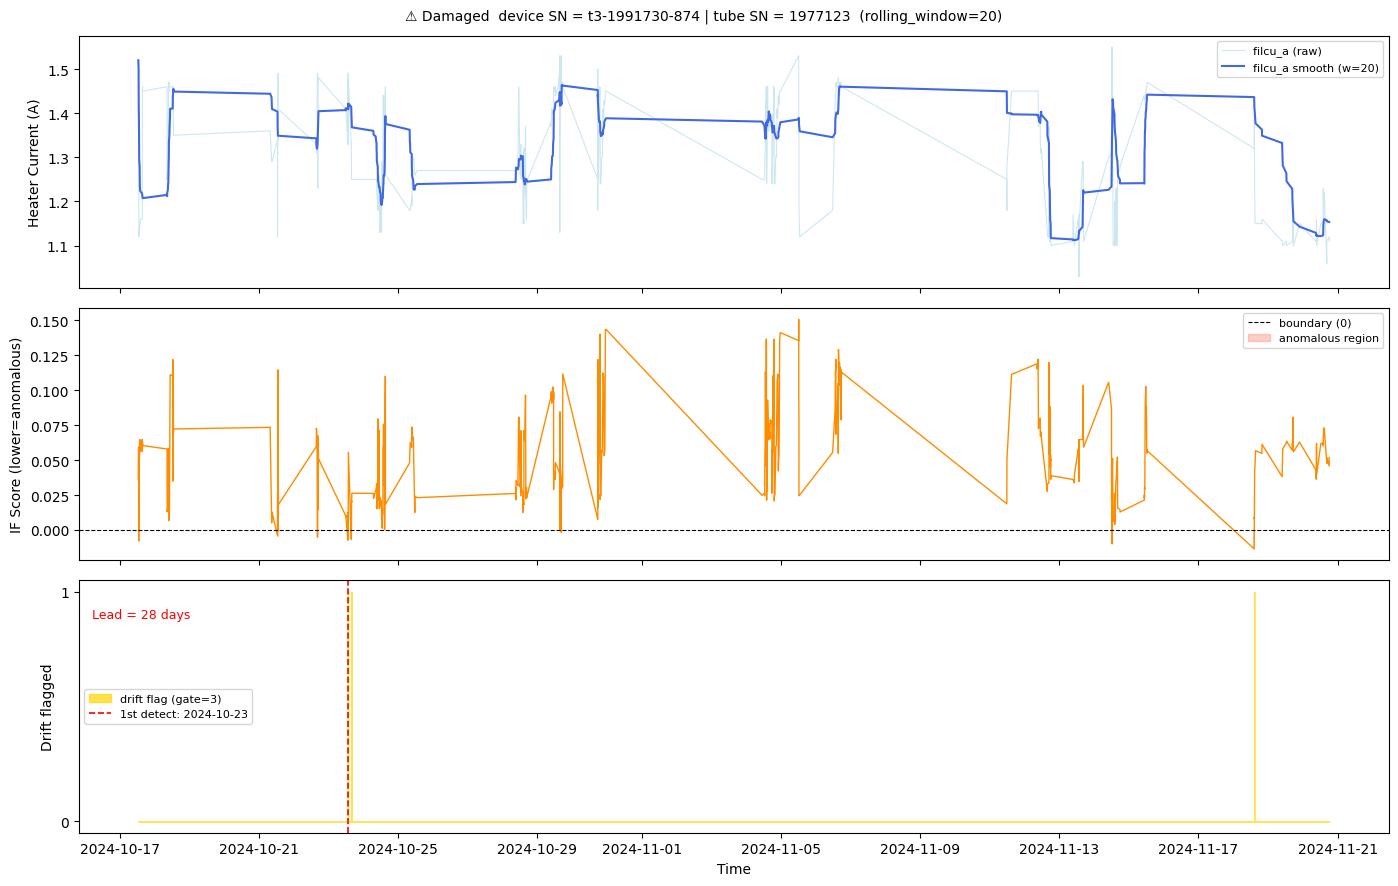

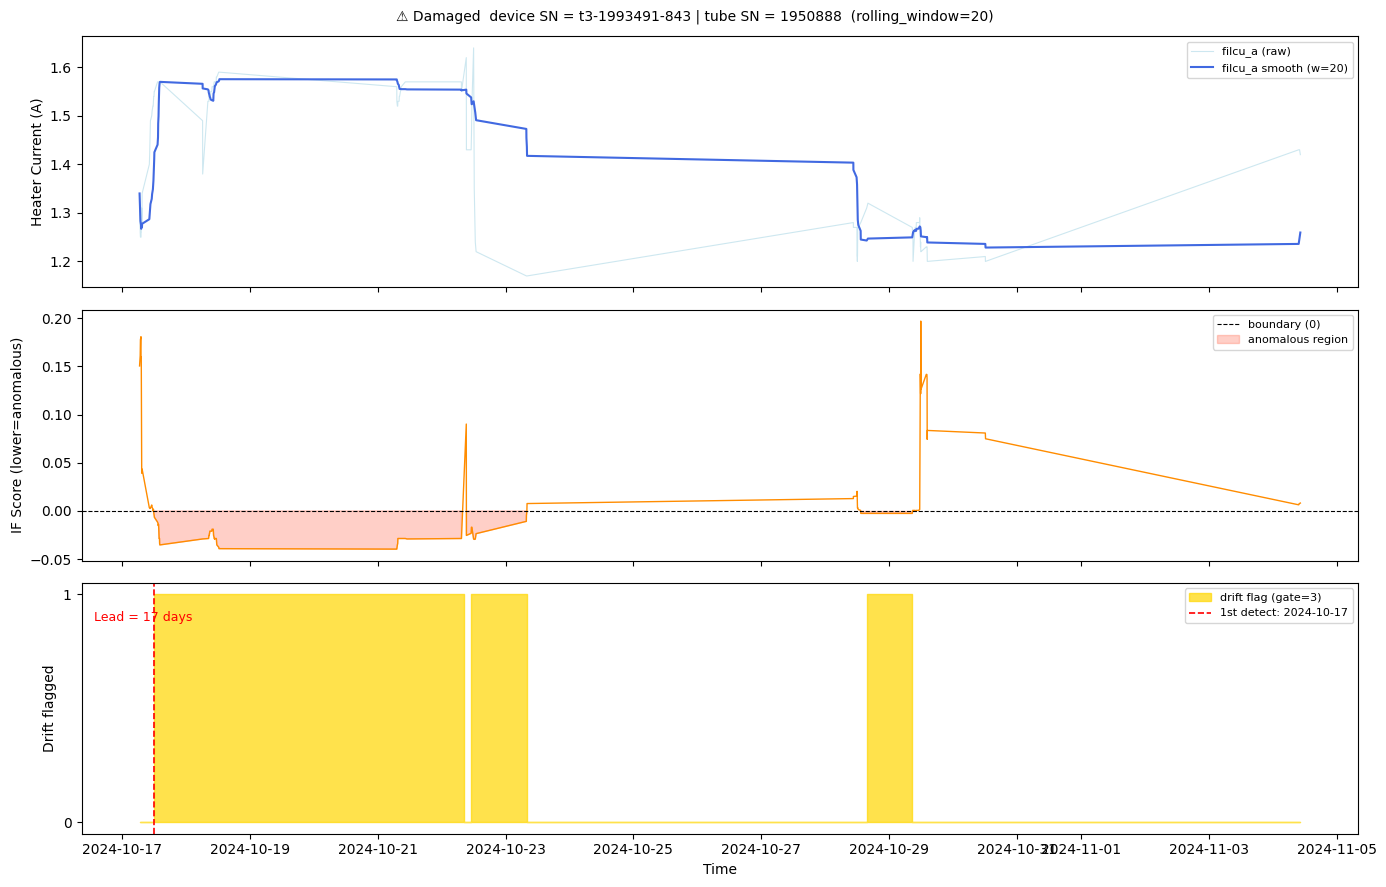

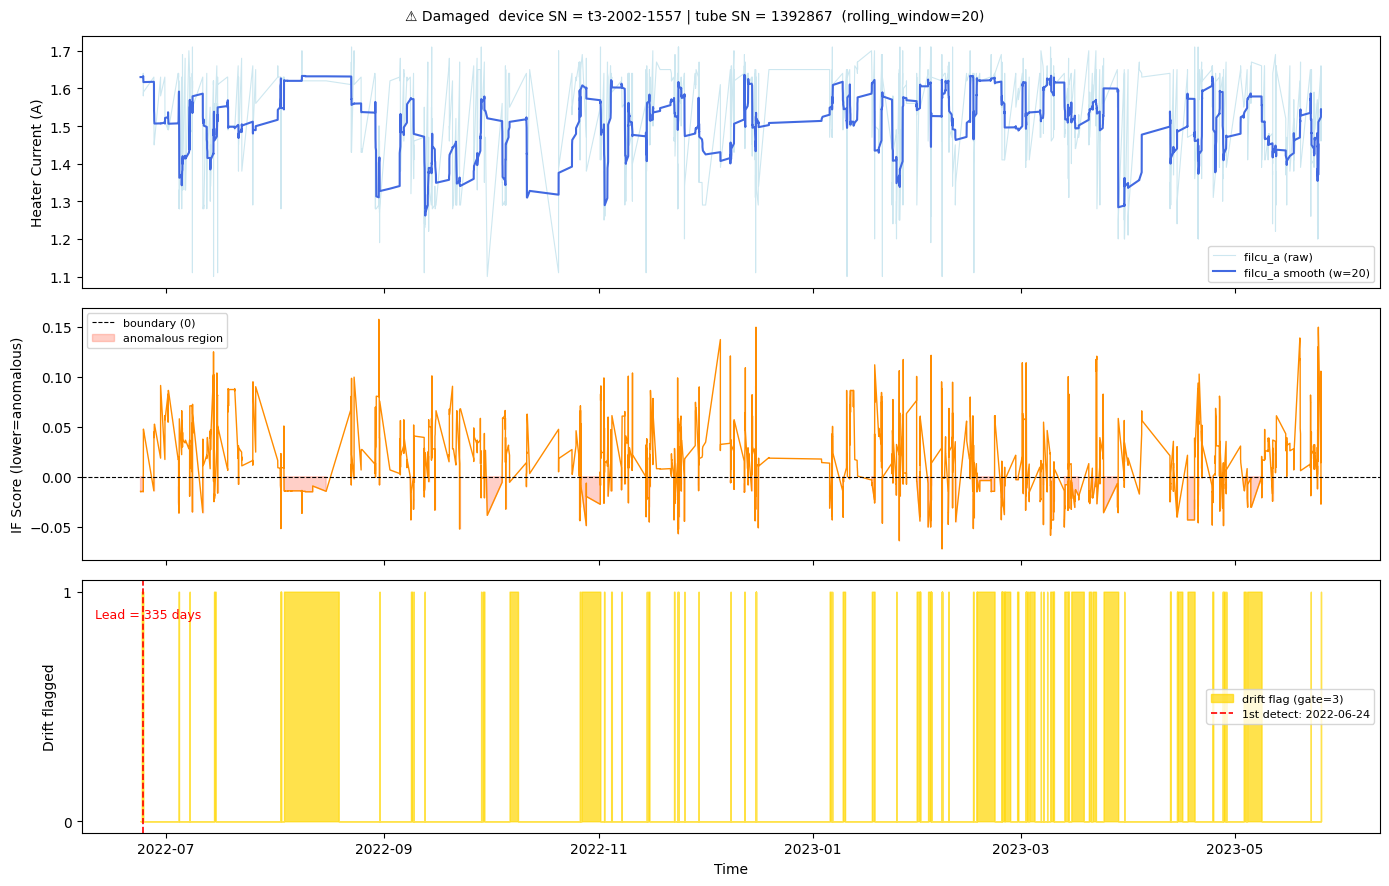

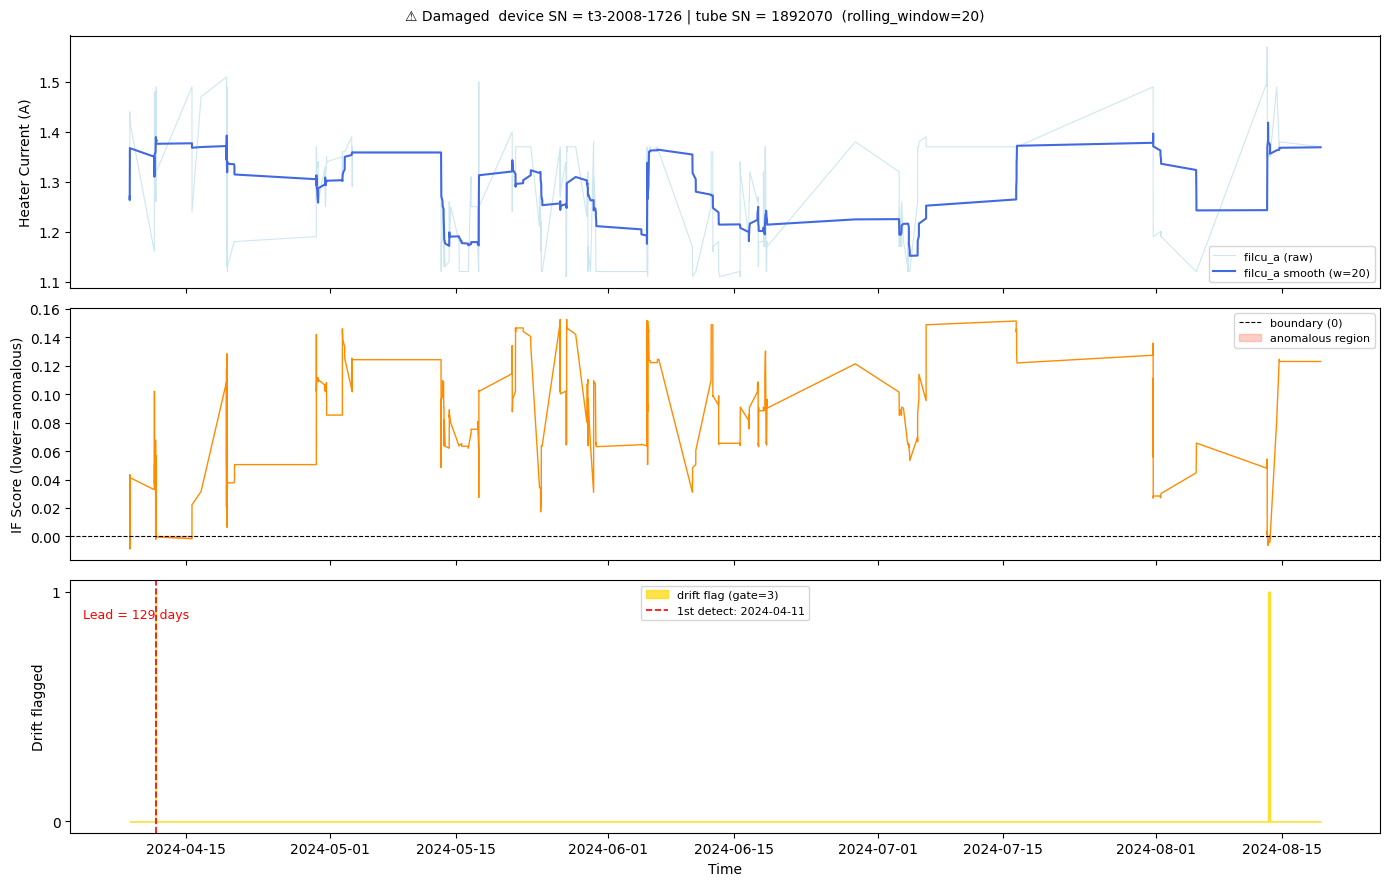

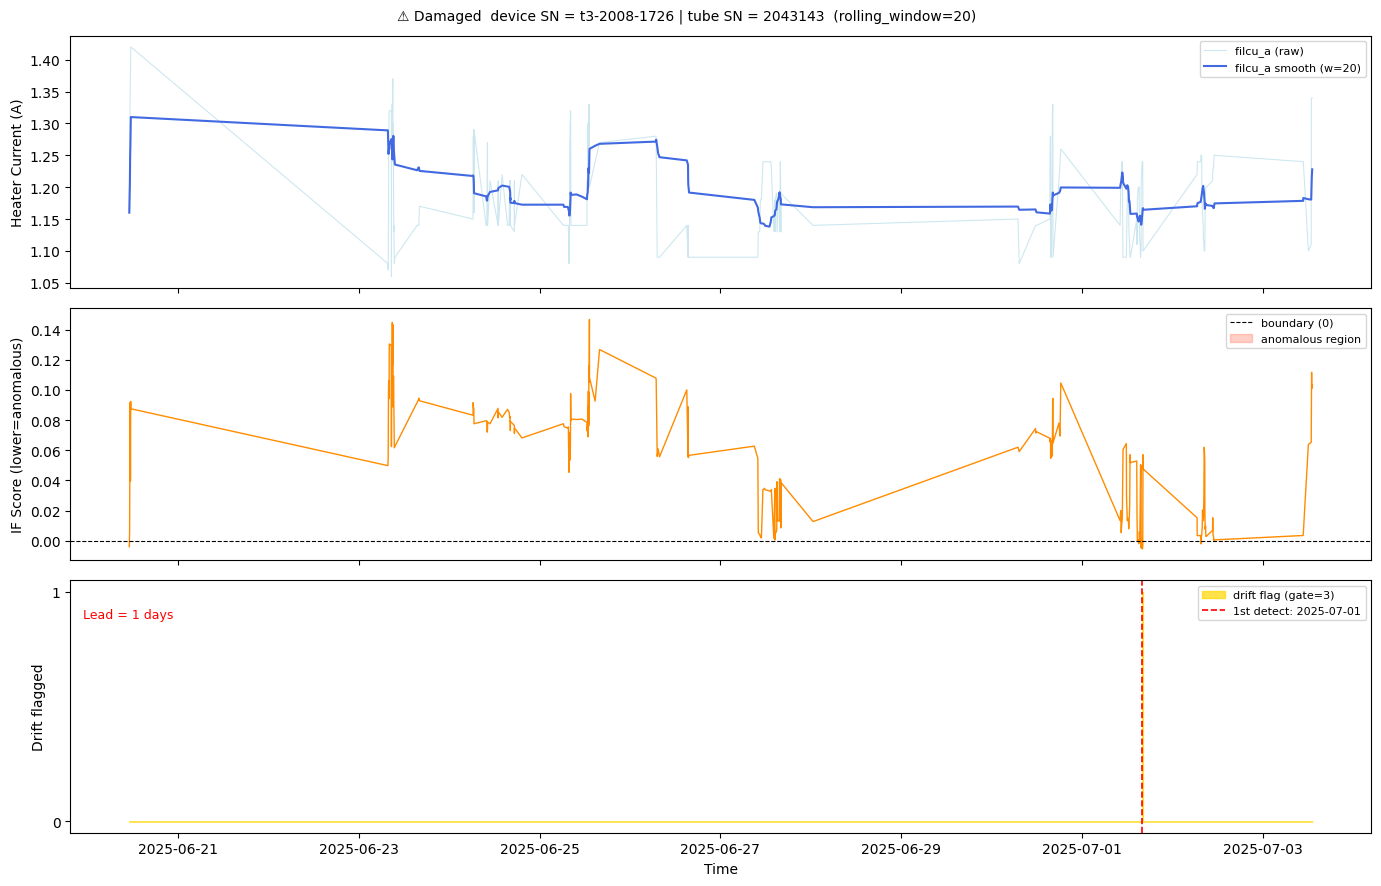

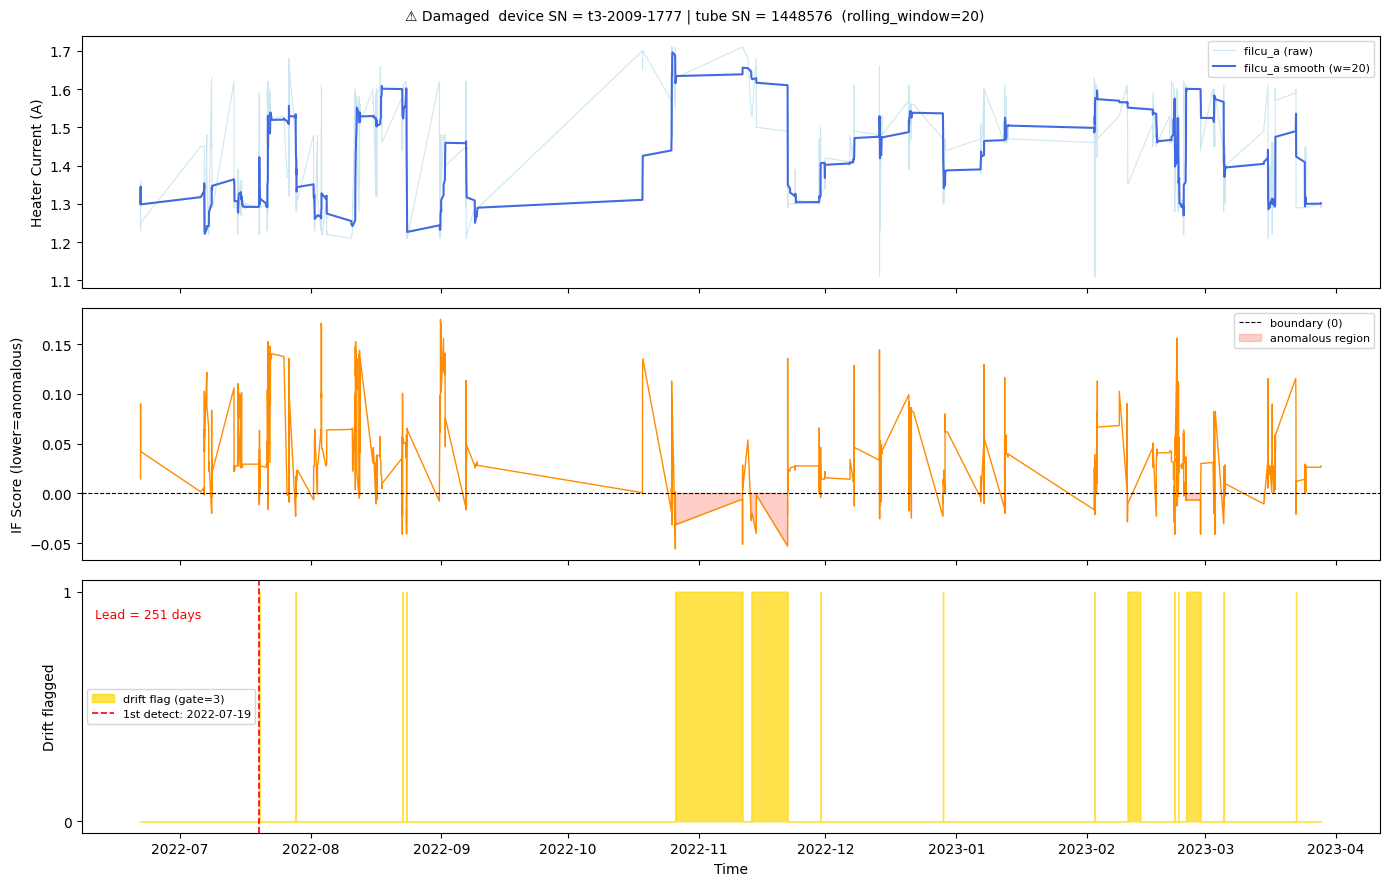

In [0]:
for (did, tid), grp in pdf_te_best[pdf_te_best["is_damaged"]].groupby(["device_id","tube_id"]):
    grp  = grp.sort_values("start_time").reset_index(drop=True)
    t    = pd.to_datetime(grp["start_time"])
    gate = flag_with_gate((grp["if_pred"] == -1).values, MIN_DETECTIONS)

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f"⚠ Damaged  device SN = {did} | tube SN = {tid}  "
                 f"(rolling_window={best_rw})", fontsize=10)

    # Panel 1: raw vs smoothed filcu_a
    axes[0].plot(t, grp["filcu_a"],        color="lightblue", lw=0.8,
                 alpha=0.6, label="filcu_a (raw)")
    axes[0].plot(t, grp["filcu_a_smooth"], color="royalblue", lw=1.5,
                 label=f"filcu_a smooth (w={best_rw})")
    axes[0].set_ylabel("Heater Current (A)")
    axes[0].legend(fontsize=8)

    # Panel 2: IF anomaly score
    axes[1].plot(t, grp["if_score"], color="darkorange", lw=1.0)
    axes[1].axhline(0, color="k", linestyle="--", lw=0.8, label="boundary (0)")
    axes[1].fill_between(t, grp["if_score"], 0,
                         where=(grp["if_score"] < 0),
                         color="tomato", alpha=0.3, label="anomalous region")
    axes[1].set_ylabel("IF Score (lower=anomalous)")
    axes[1].legend(fontsize=8)

    # Panel 3: drift flag (gated)
    axes[2].fill_between(t, gate.astype(int), color="gold", alpha=0.7, step="mid",
                         label=f"drift flag (gate={MIN_DETECTIONS})")
    if gate.any():
        first_t = t.iloc[np.argmax(gate)]
        last_t  = t.iloc[-1]
        axes[2].axvline(first_t, color="red", lw=1.2, linestyle="--",
                        label=f"1st detect: {first_t.date()}")
        axes[2].text(0.01, 0.85,
                     f"Lead = {(last_t - first_t).days} days",
                     transform=axes[2].transAxes, fontsize=9, color="red")
    axes[2].set_ylabel("Drift flagged")
    axes[2].set_xlabel("Time")
    axes[2].set_yticks([0, 1])
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## 14b. [EXPERIMENTAL] Deep Dive — Calibrated Score + CUSUM per Damaged Pair

Shows for each damaged pair:
- Raw IF score vs adaptive per-pair threshold
- Baseline calibration window (first N samples, blue band)  
- Adjusted score (deviation from pair baseline)
- CUSUM on adjusted score with alarm threshold
- Fused alarm vs baseline alarm


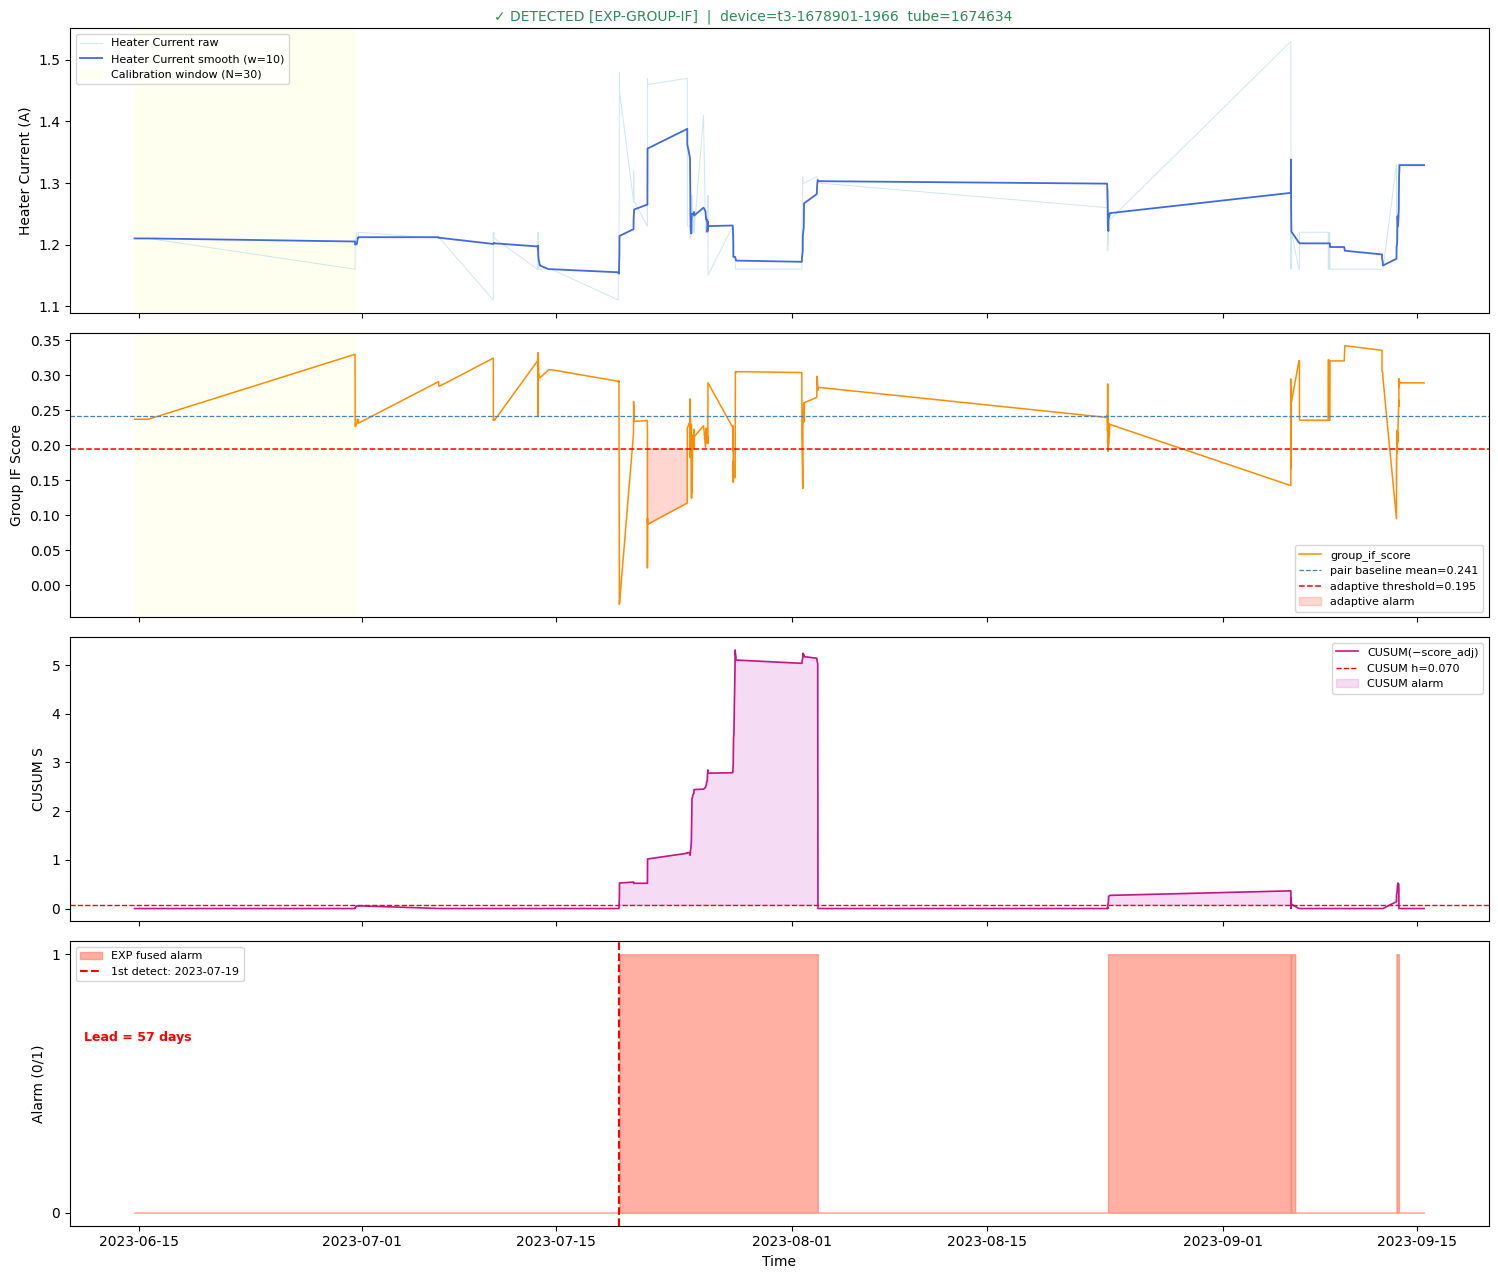

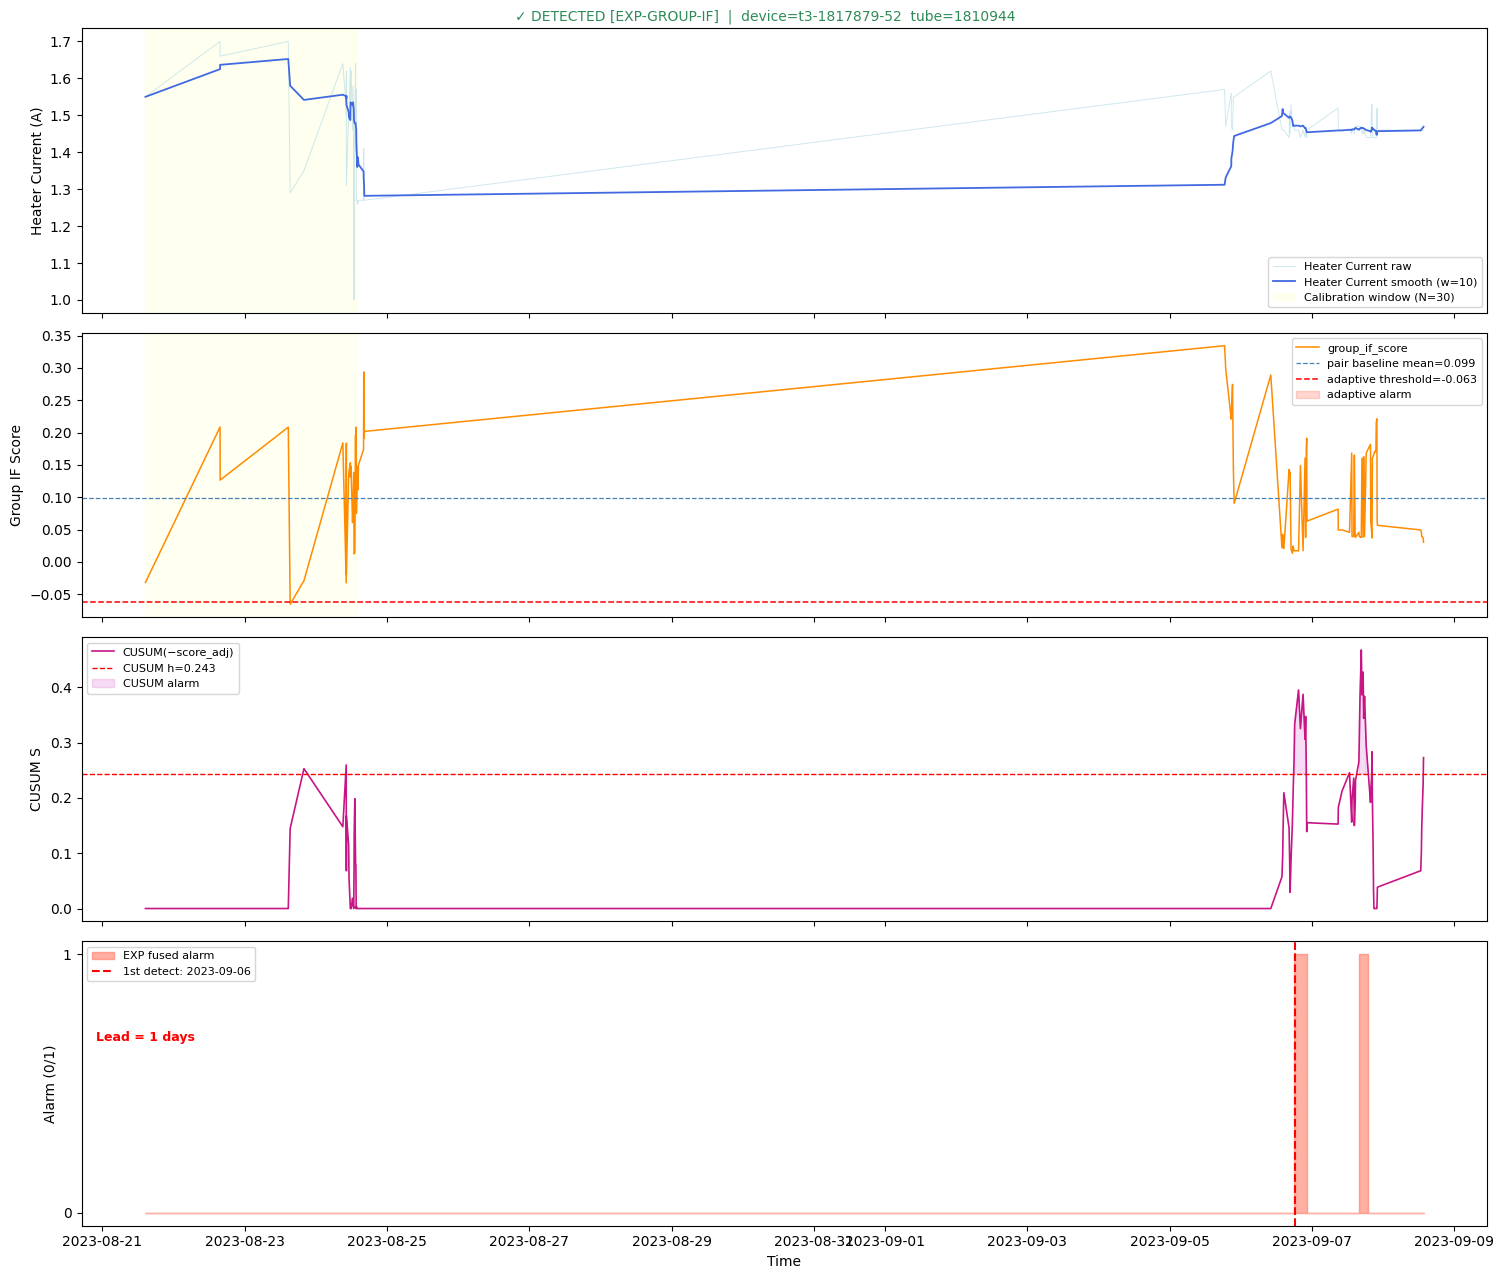

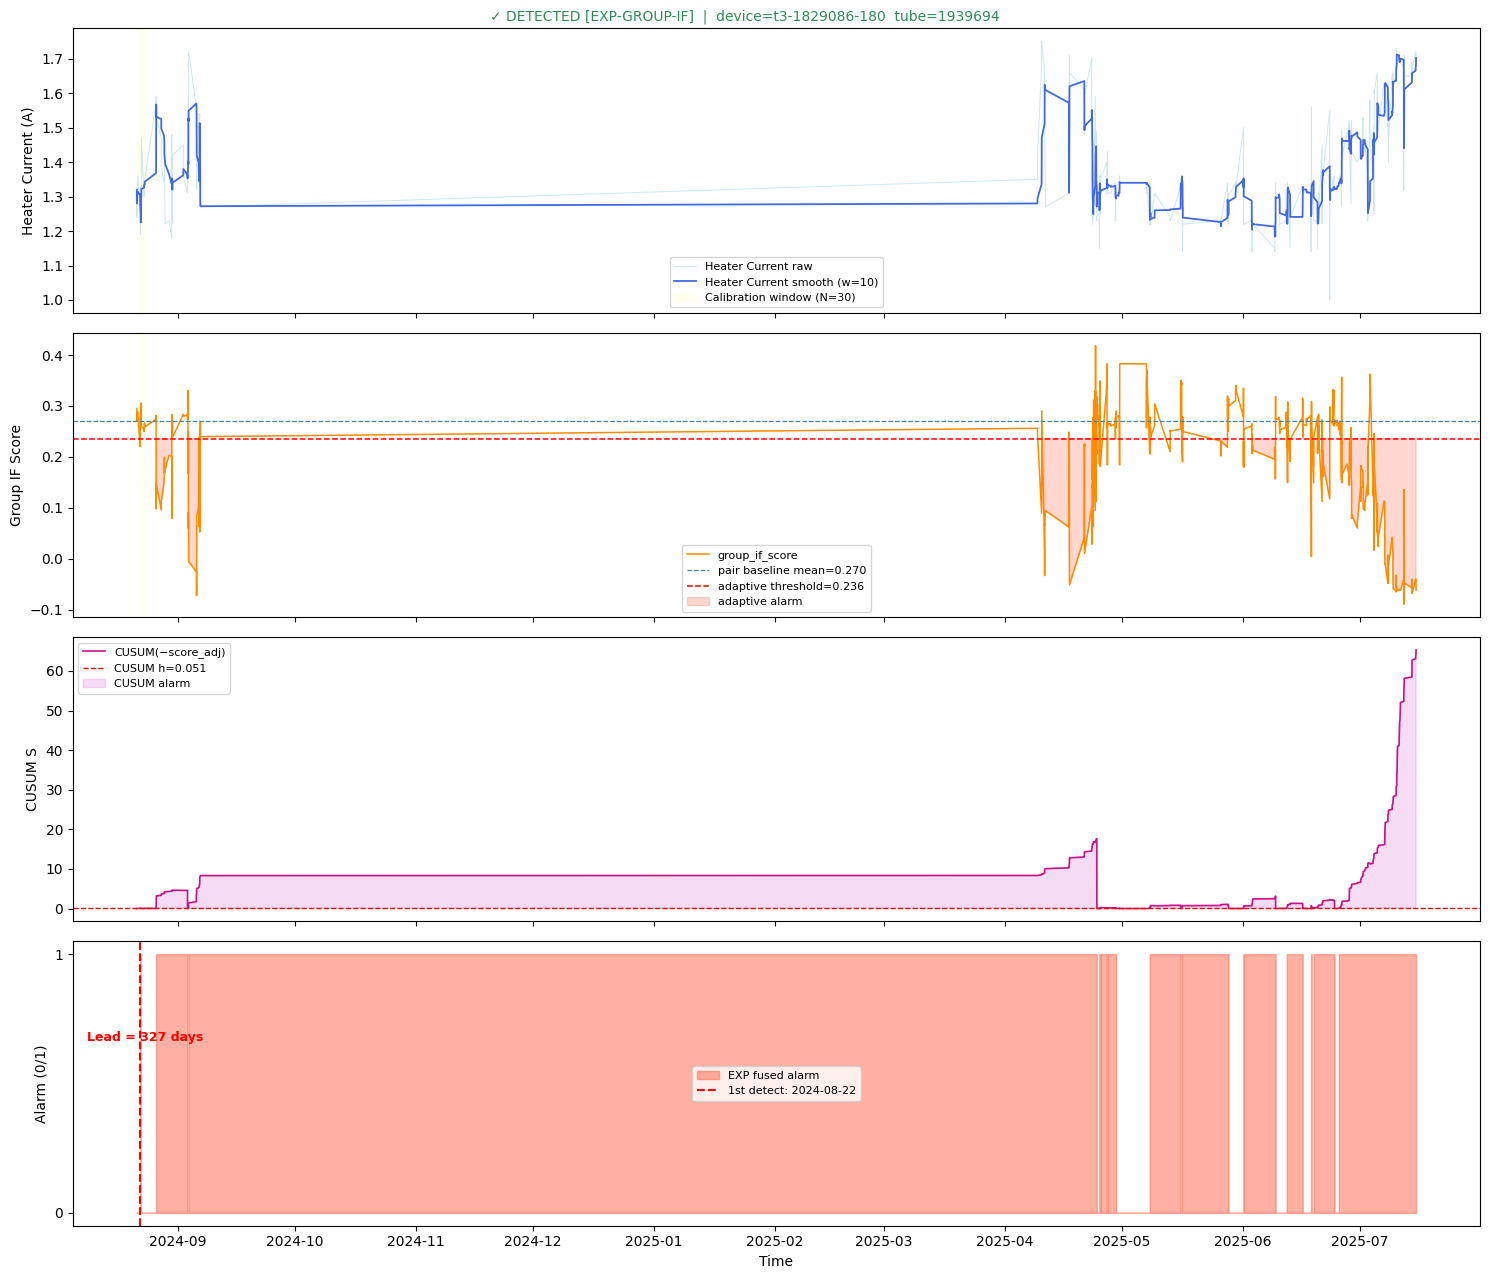

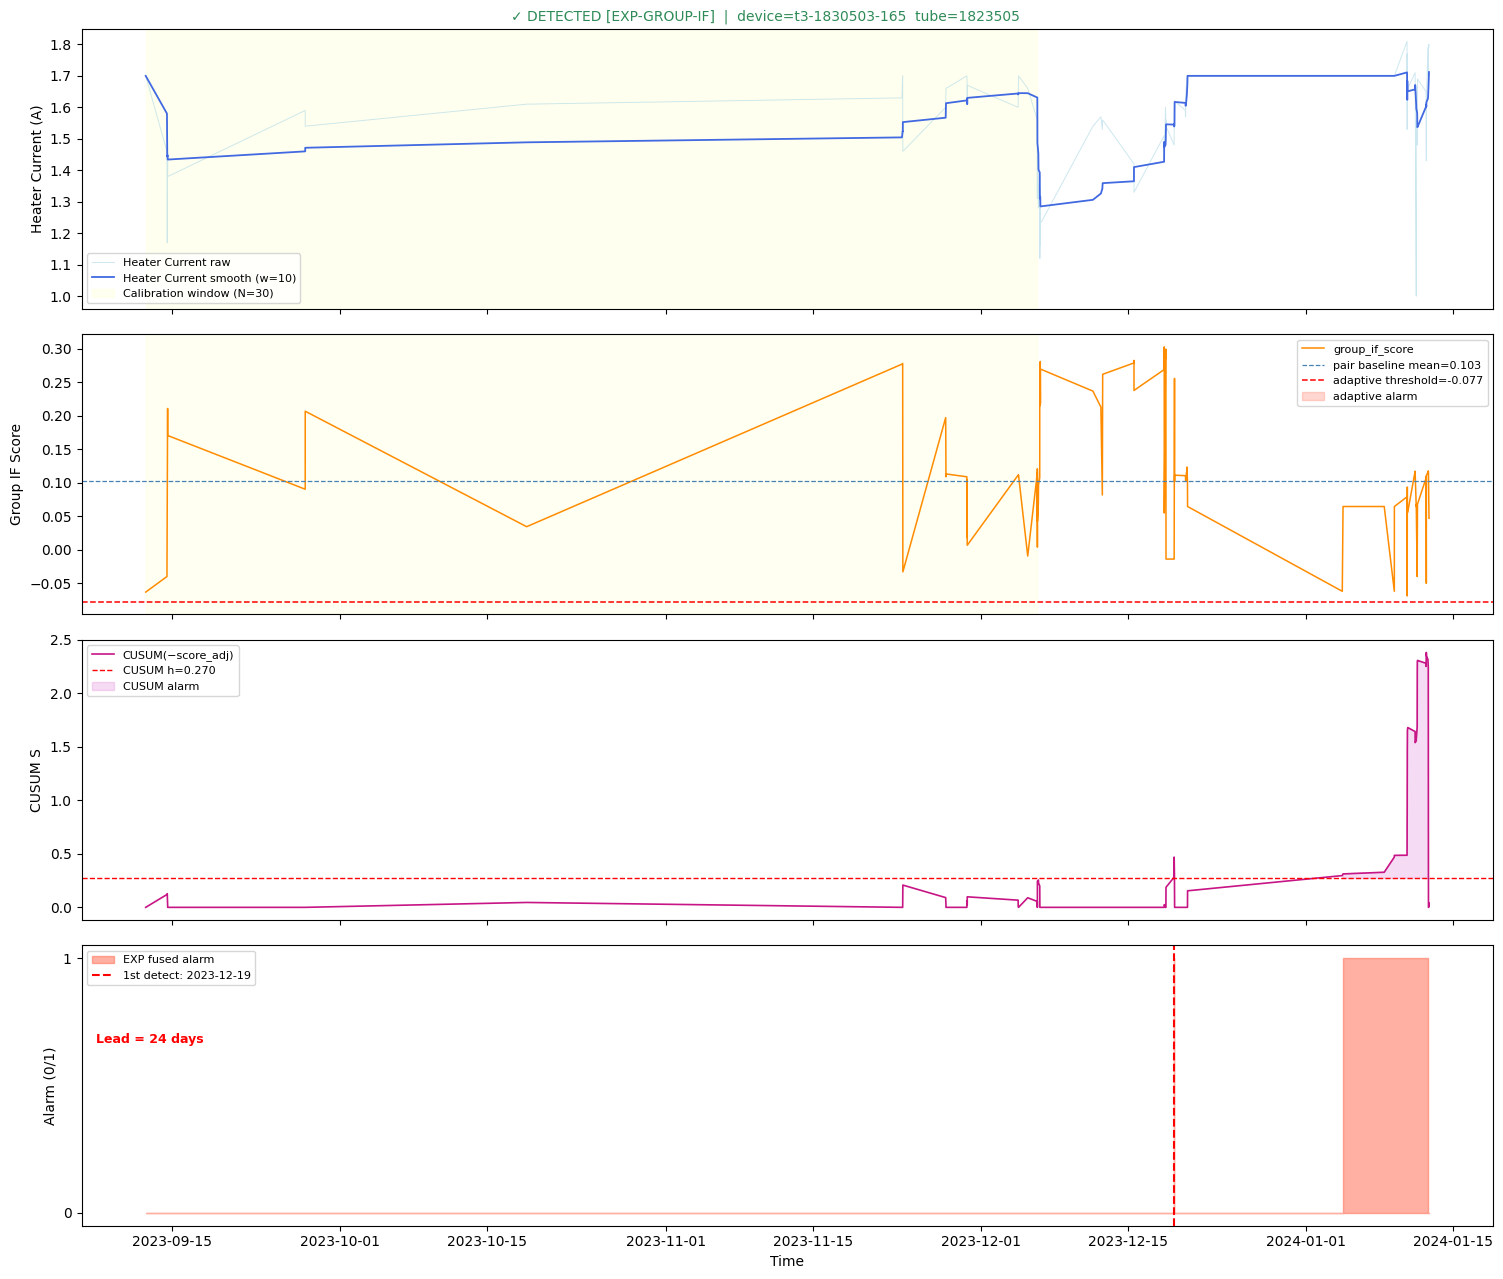

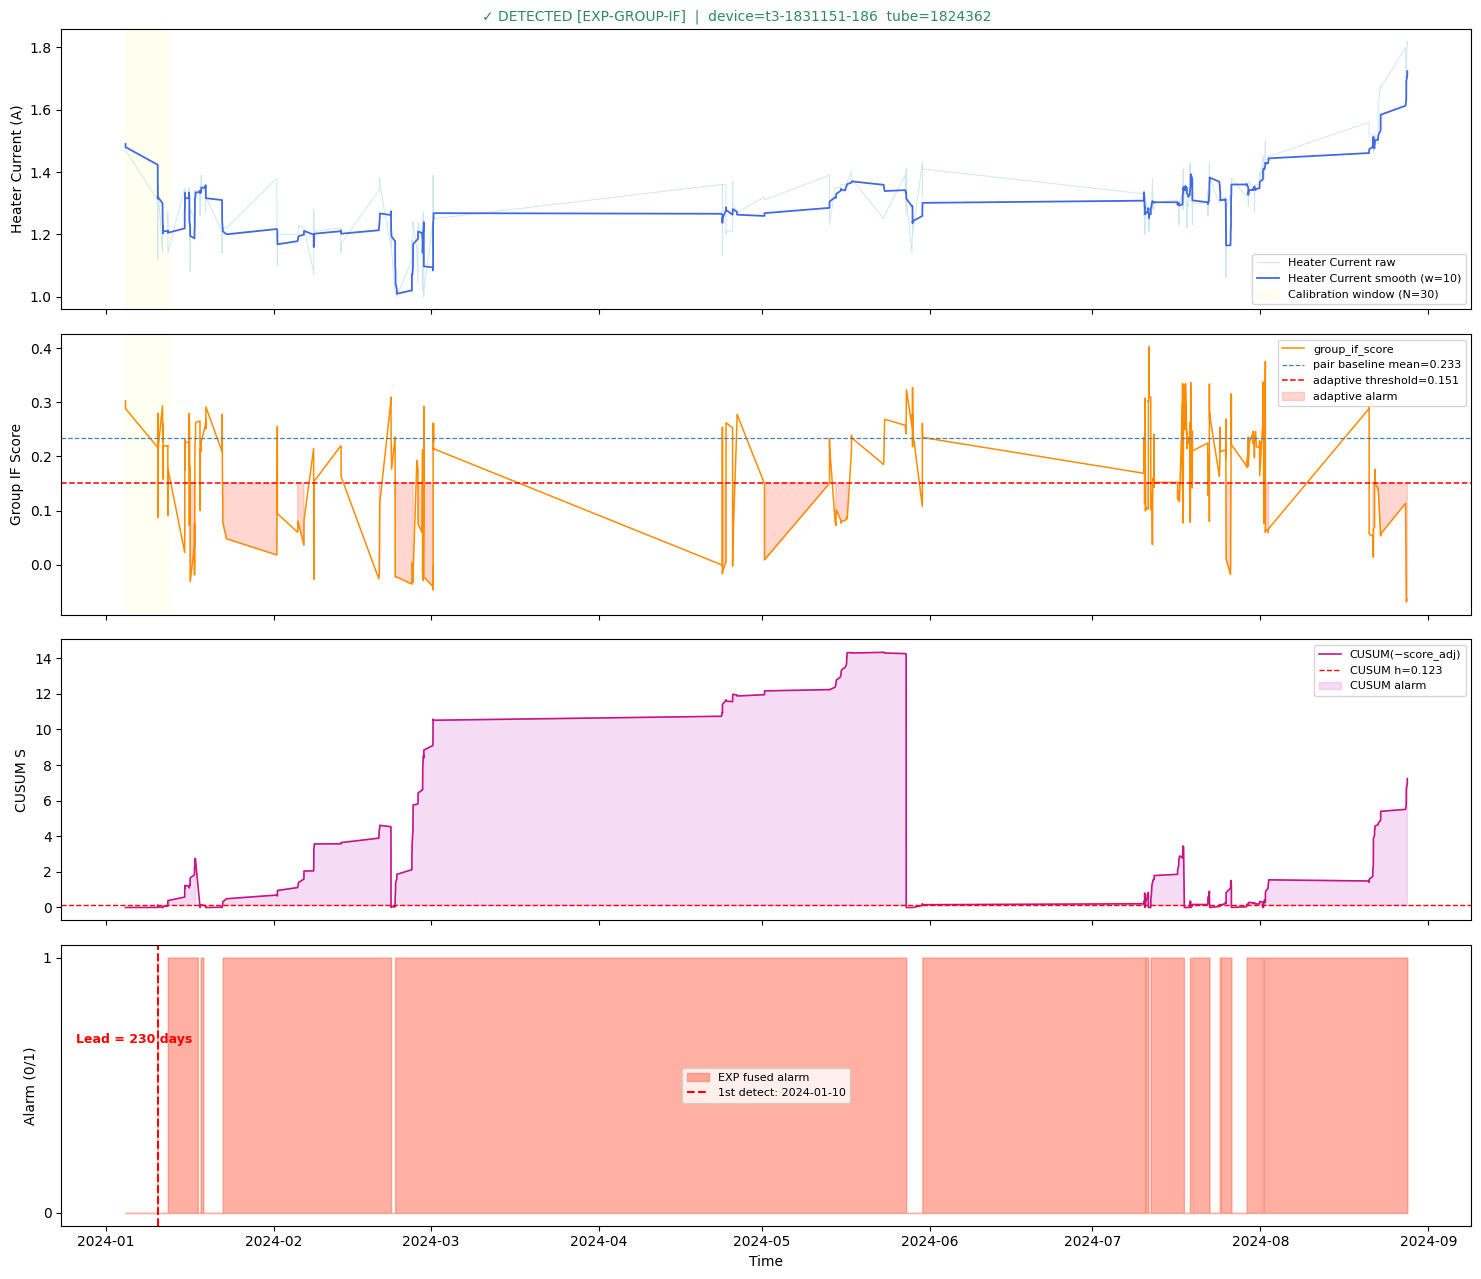

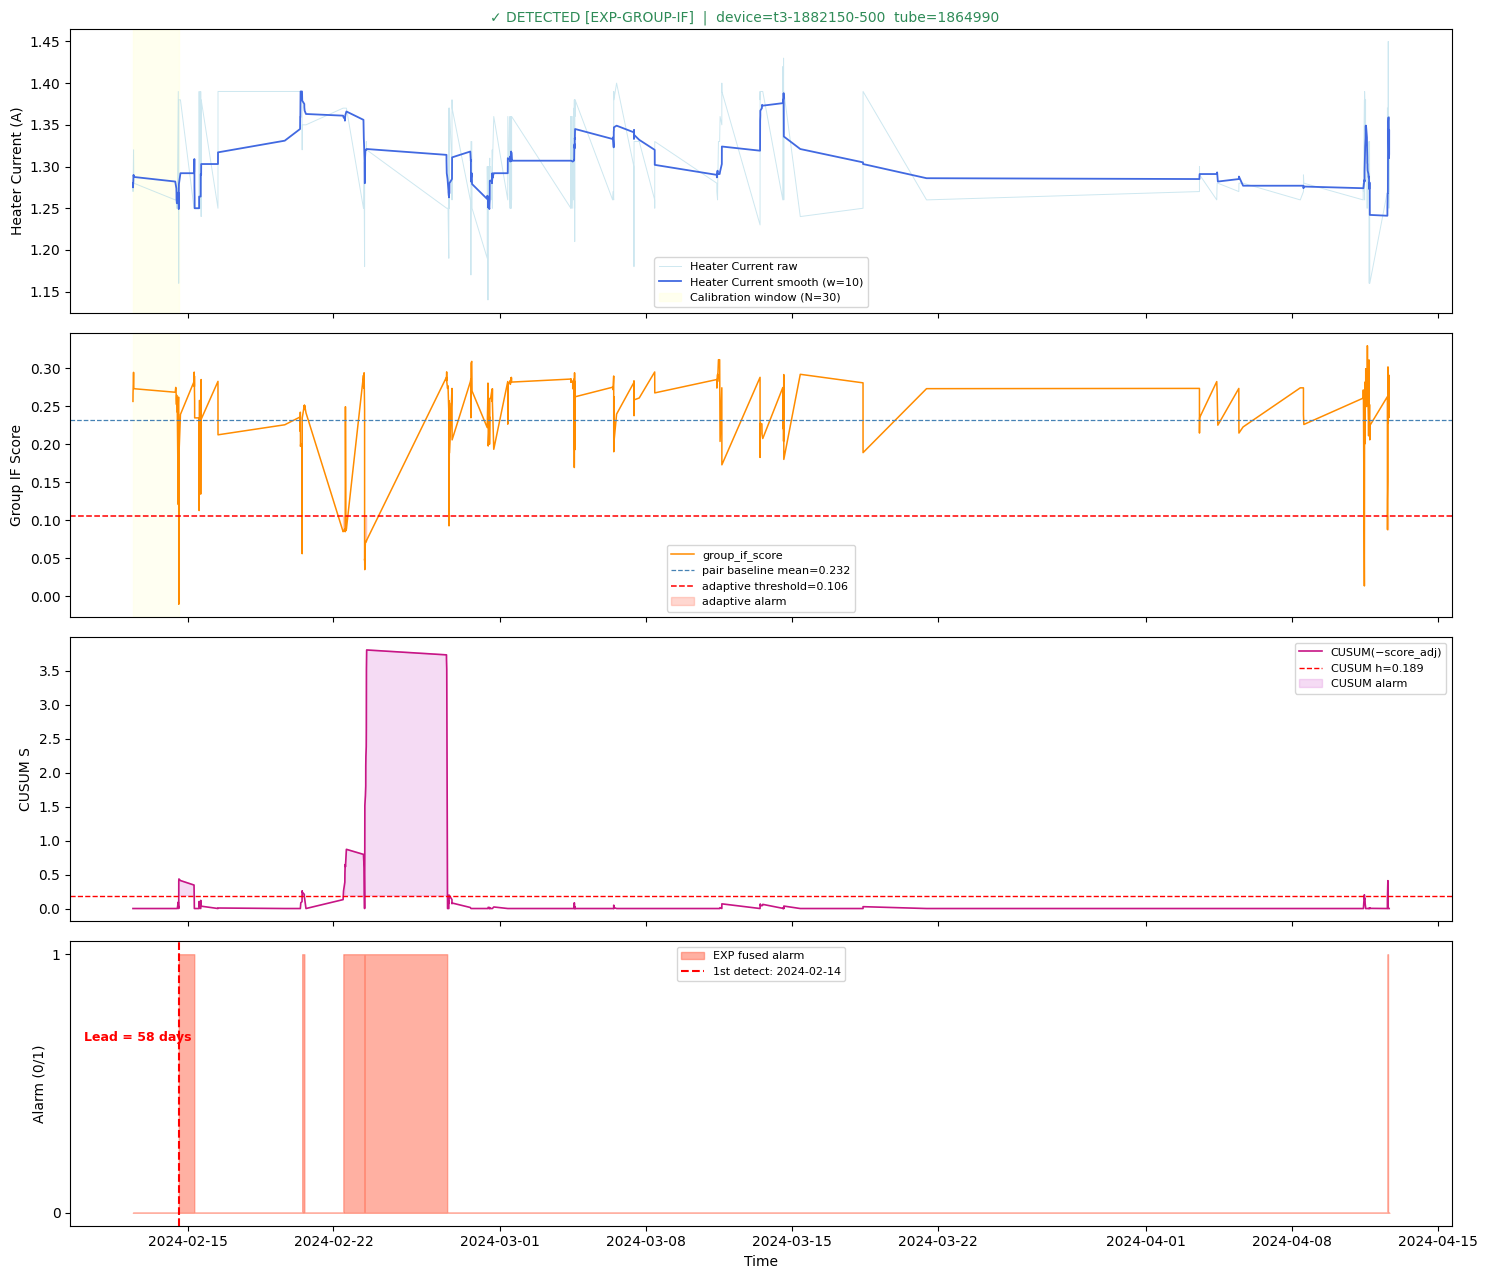

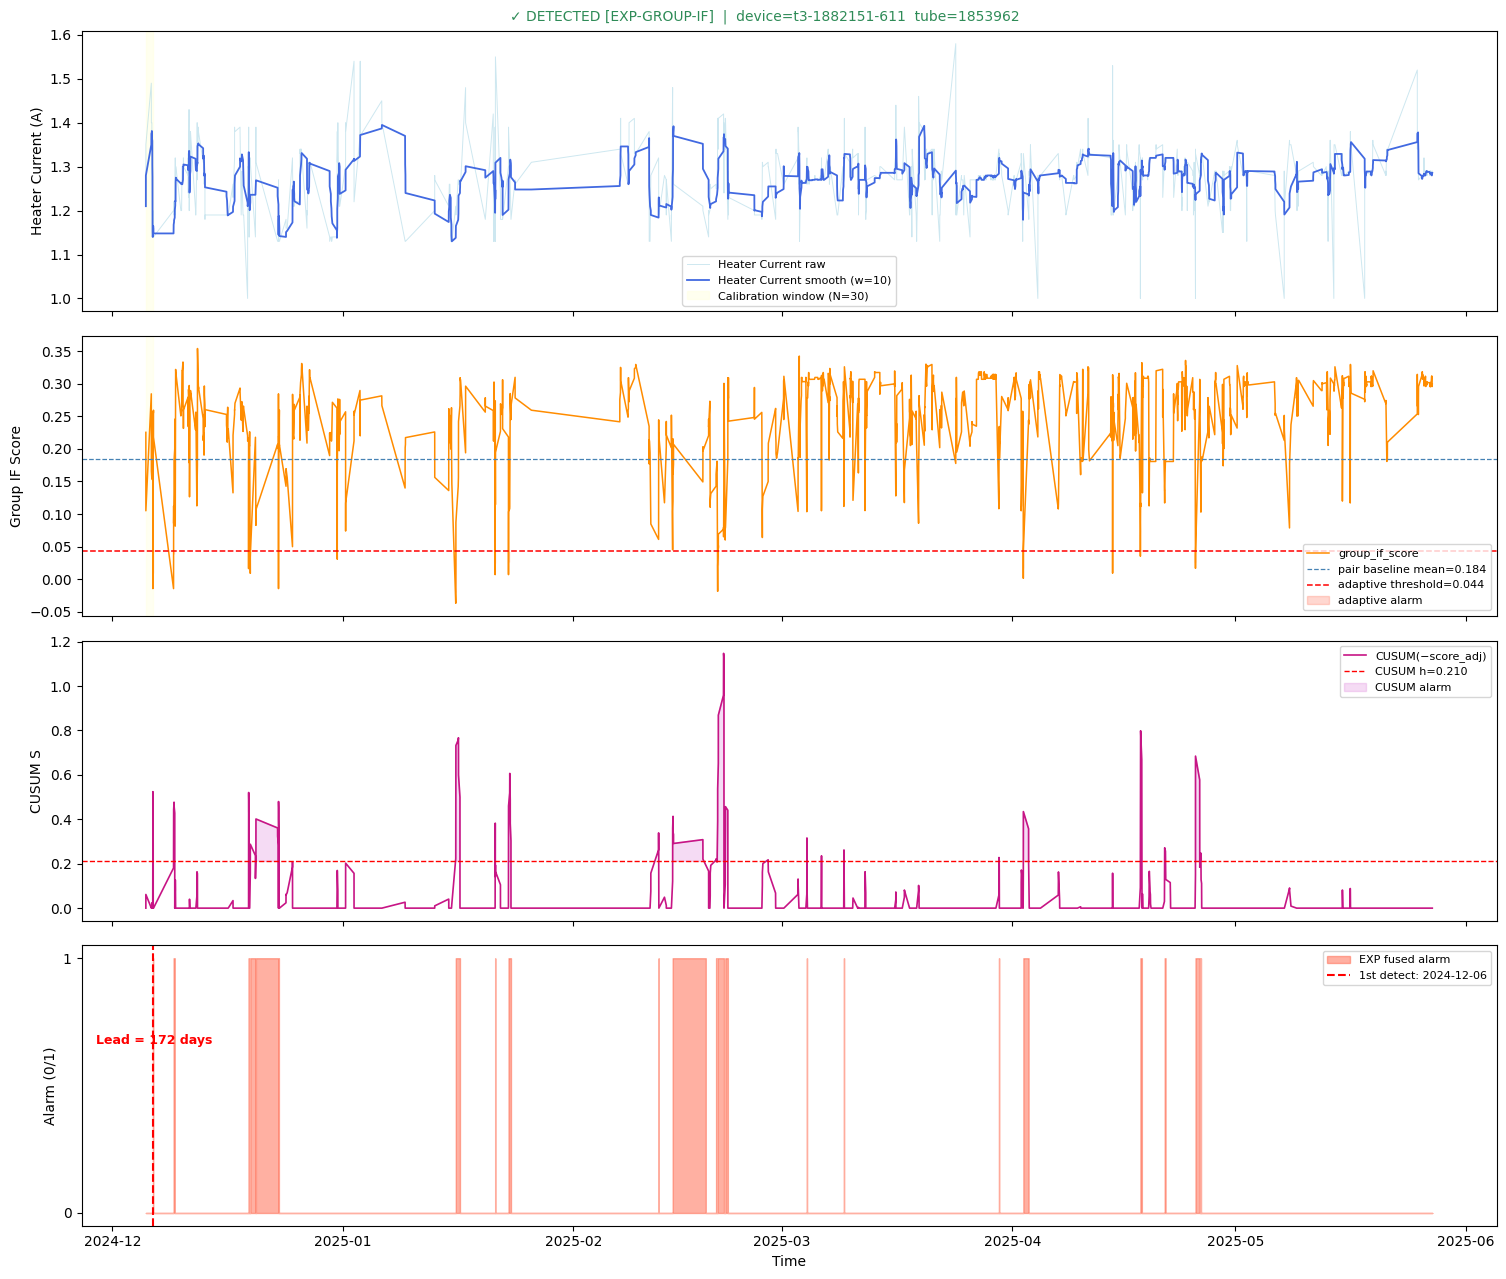

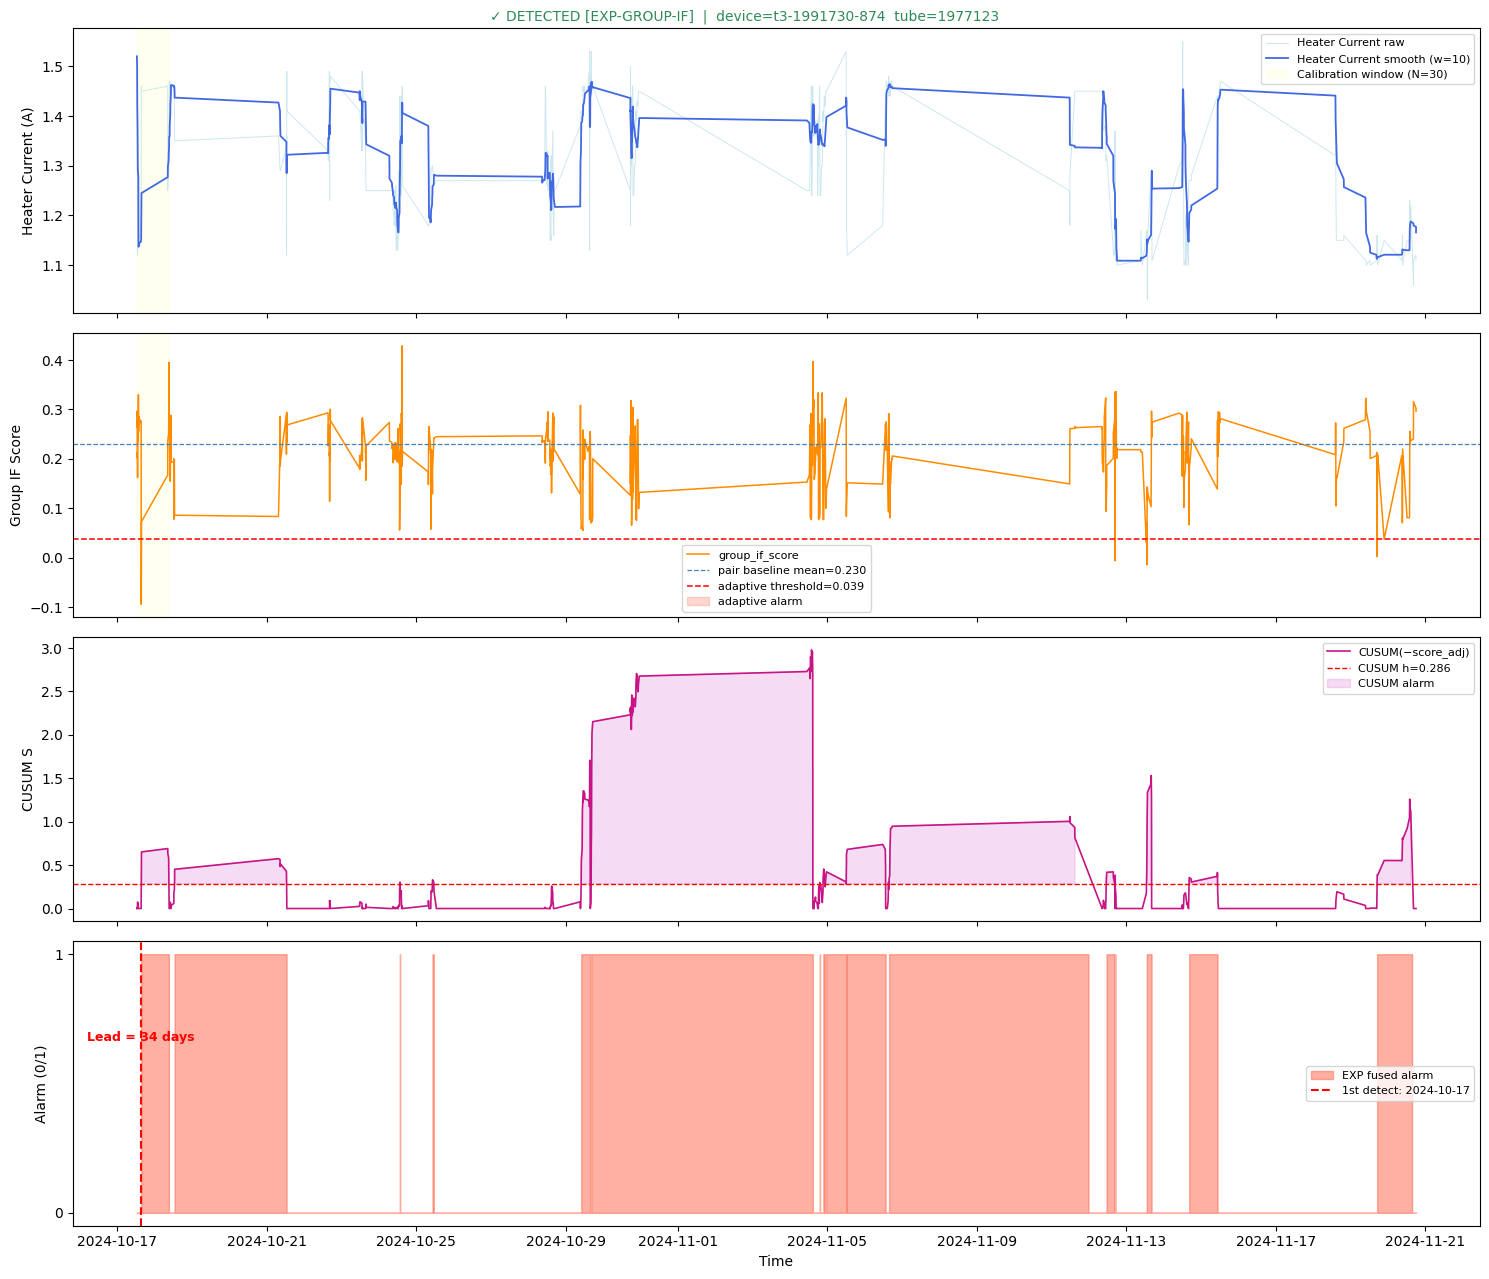

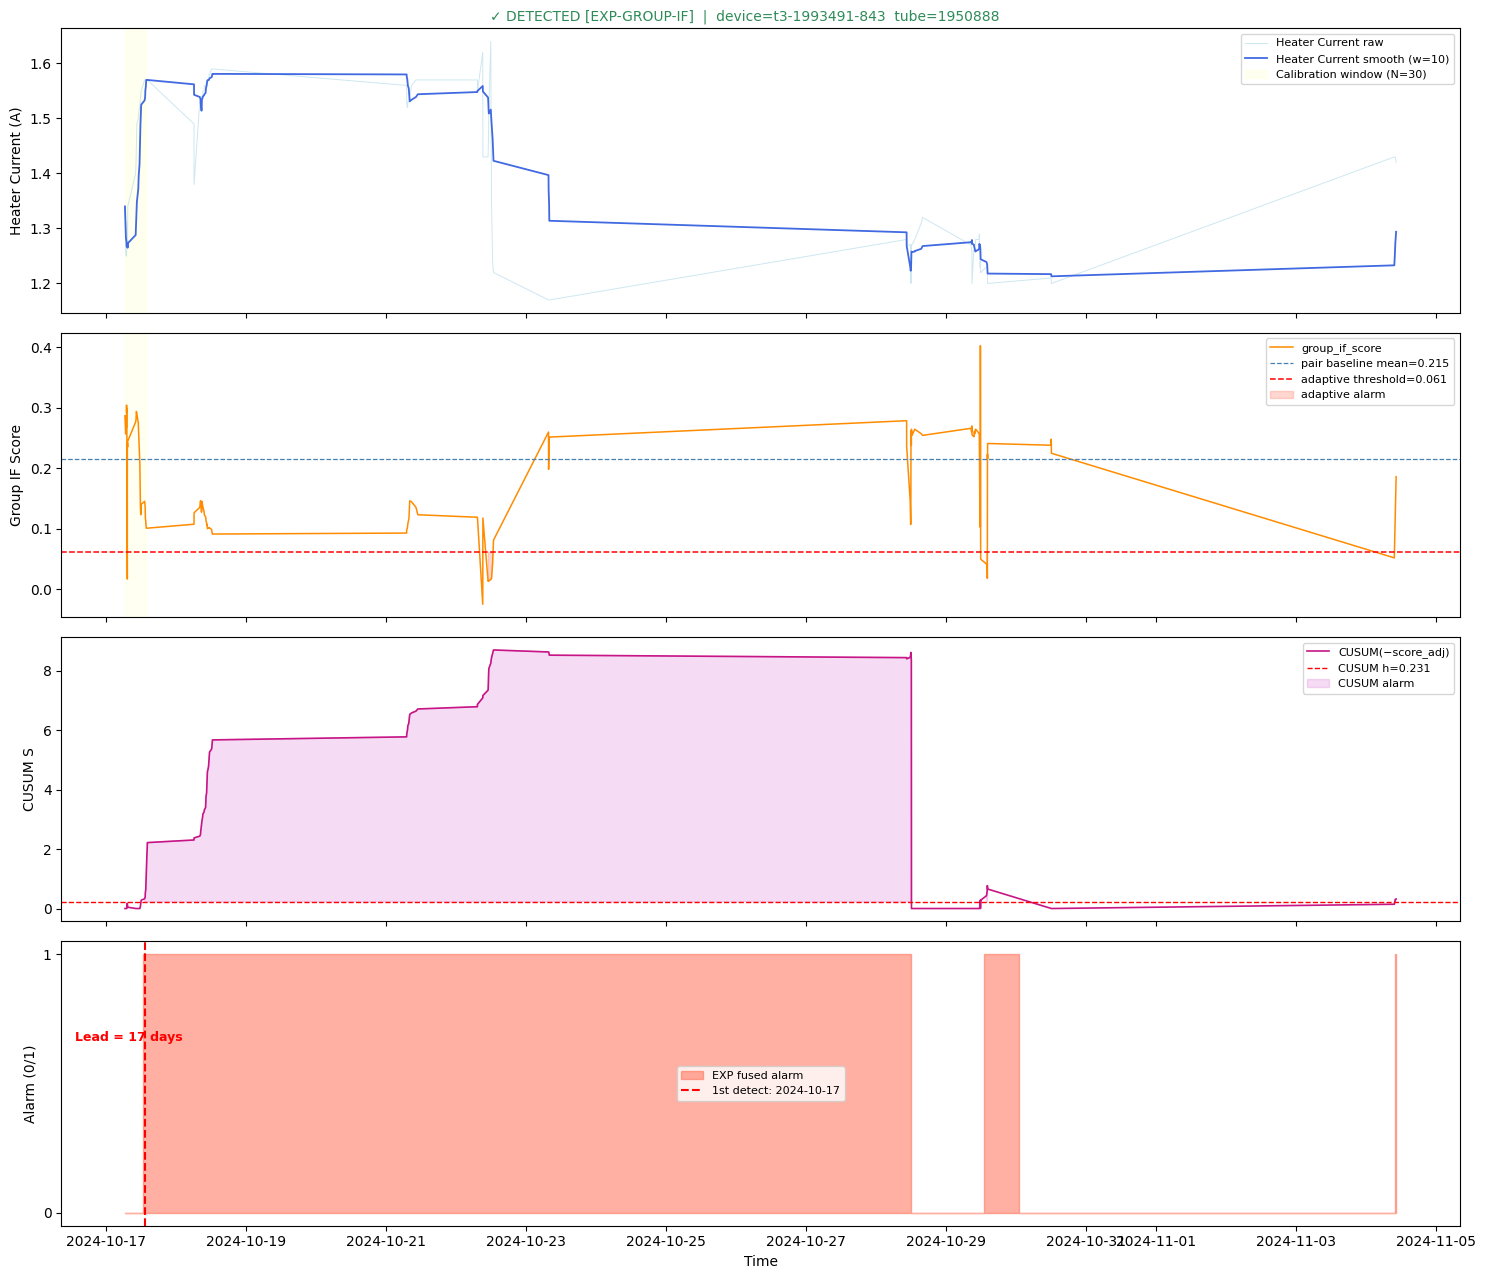

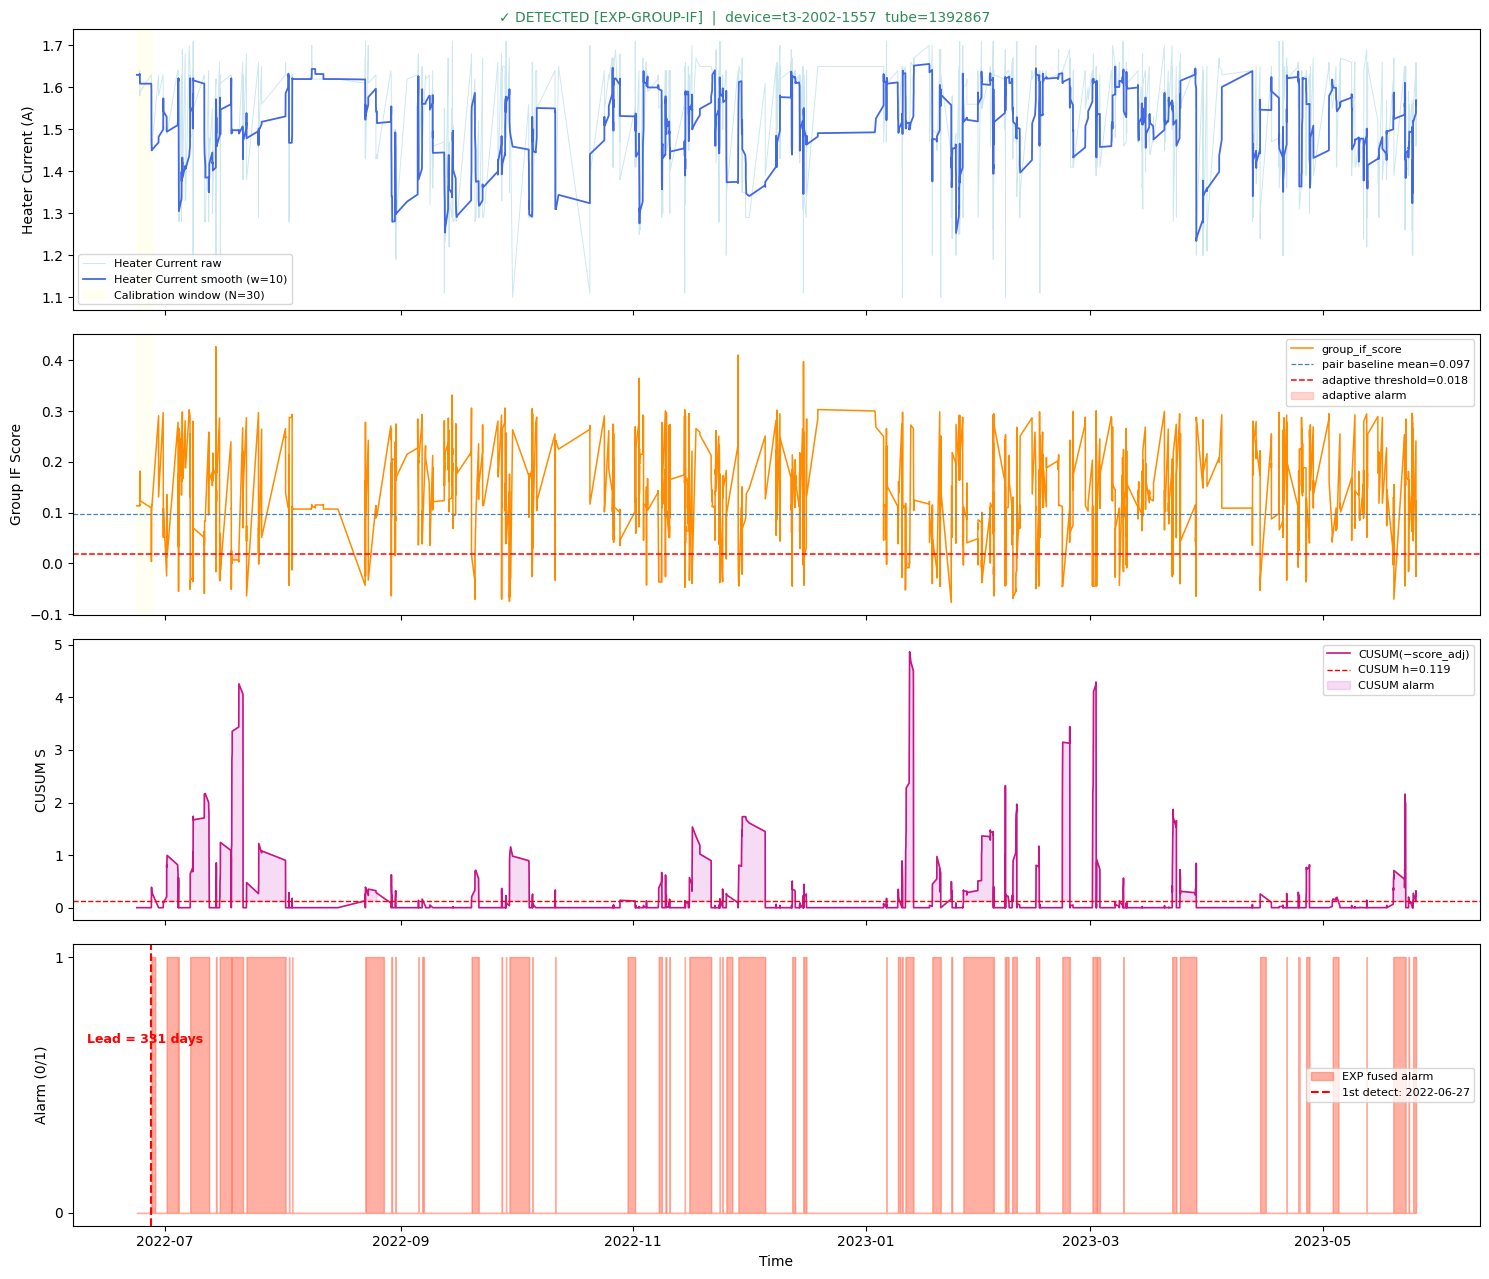

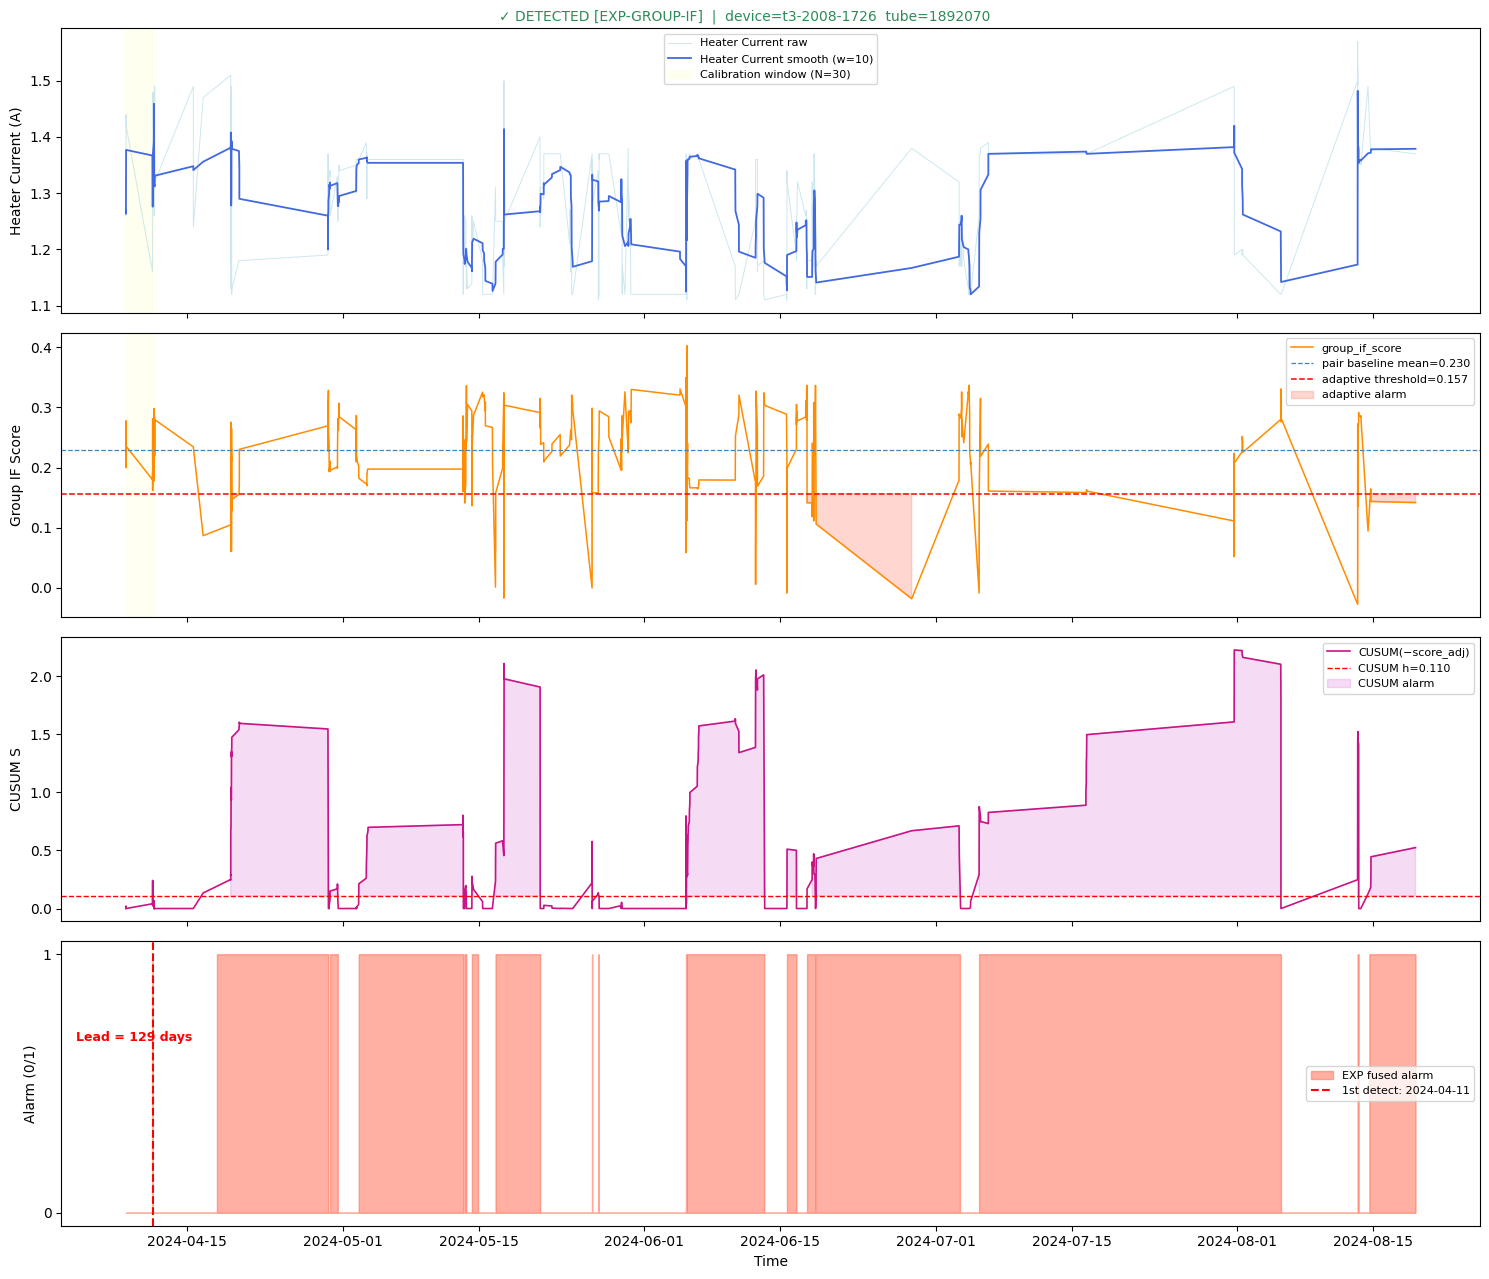

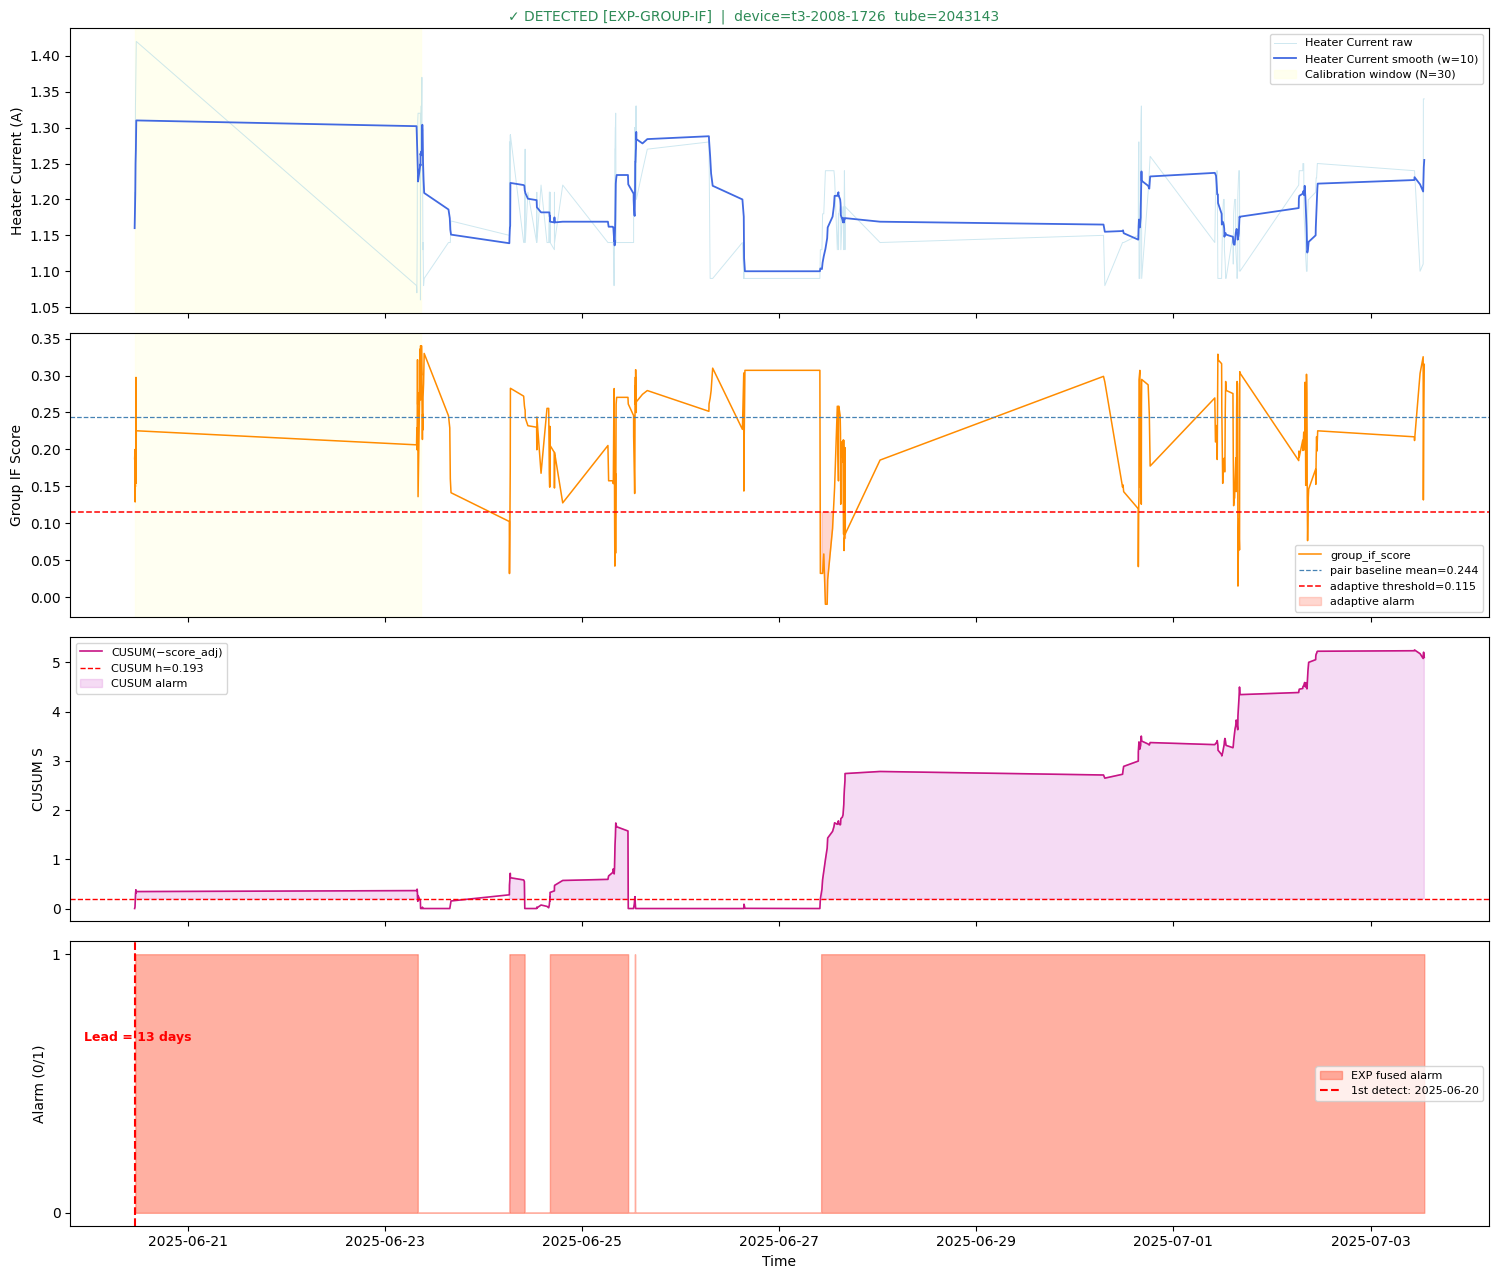

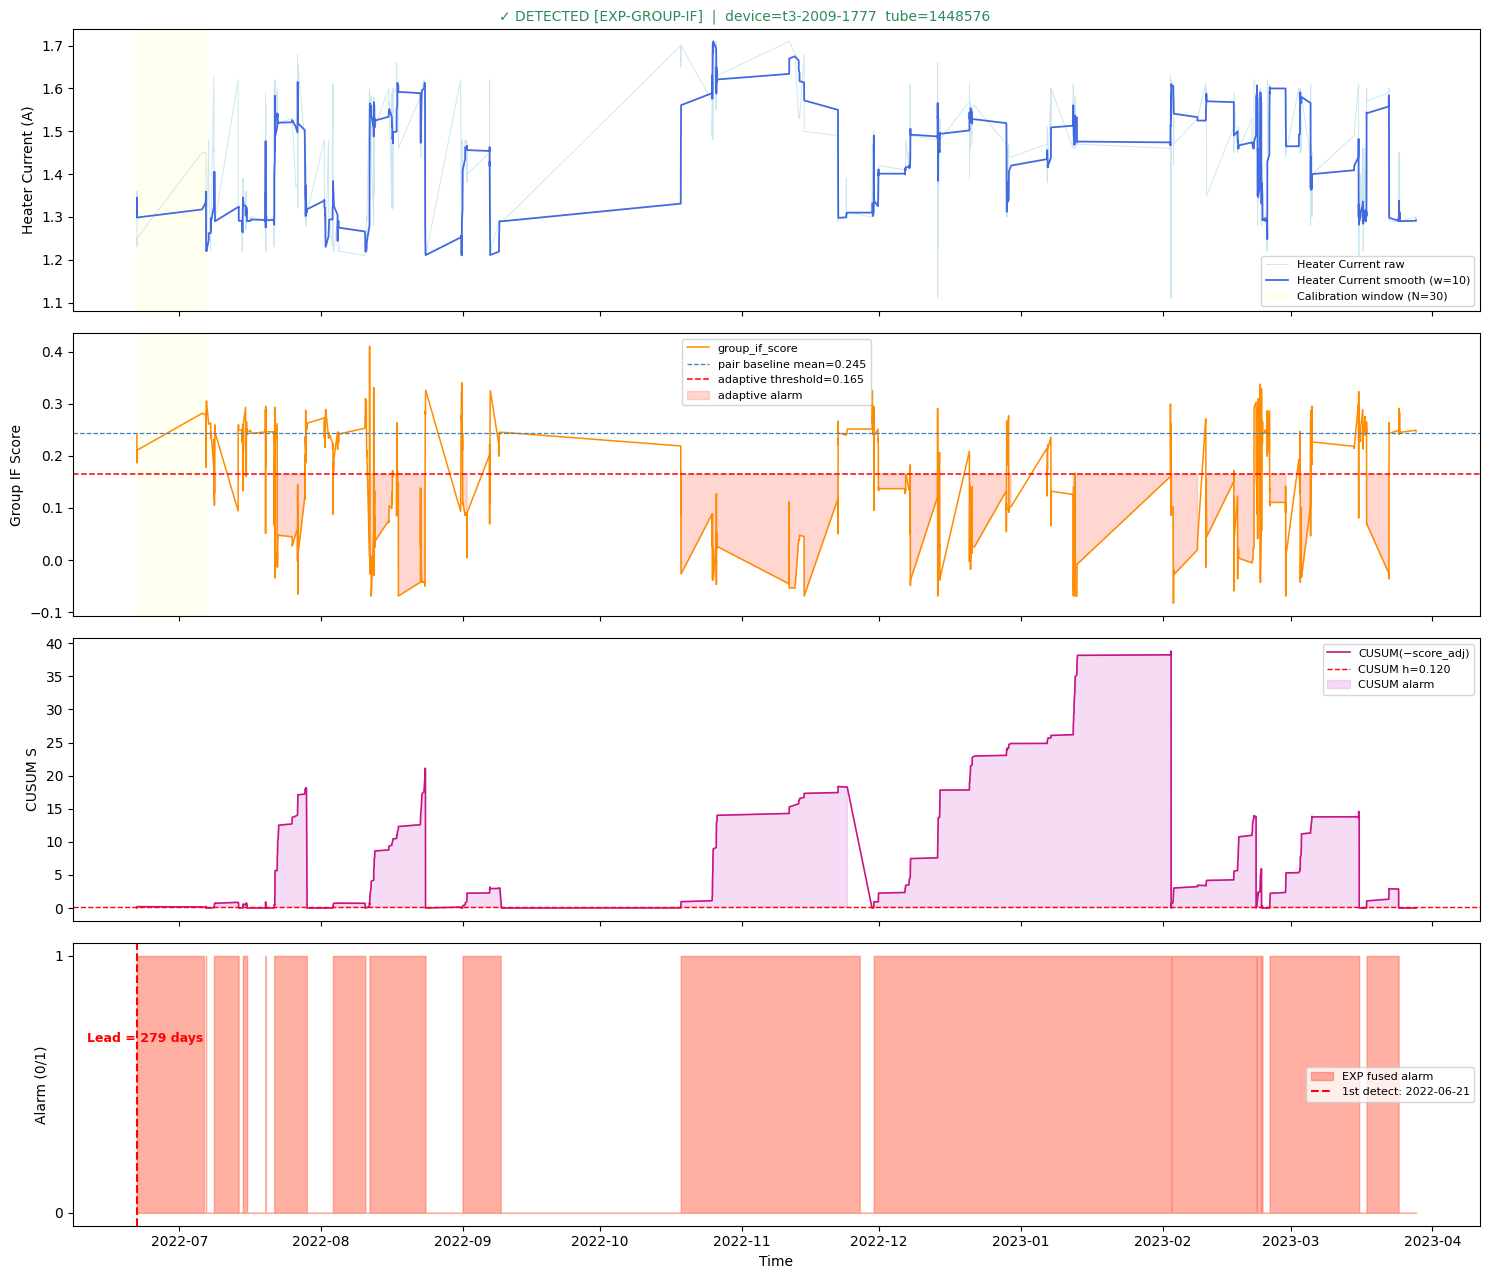

In [0]:
# ══════════════════════════════════════════════════════════════════════════════
# [EXPERIMENTAL] Deep dive per damaged pair — calibrated score + CUSUM
# Uses: pdf_te_cal_group (from §10b), exp_pair_group
# ══════════════════════════════════════════════════════════════════════════════

for (did, tid), grp in pdf_te_cal_group[pdf_te_cal_group["is_damaged"]].groupby(
        ["device_id","tube_id"]):
    grp   = grp.sort_values("start_time").reset_index(drop=True)
    t     = pd.to_datetime(grp["start_time"])
    det_r = exp_pair_group[(exp_pair_group["device_id"]==did) &
                            (exp_pair_group["tube_id"]==tid)]
    is_det = bool(det_r["drift_detected"].values[0]) if len(det_r) else False

    baseline_end = t.iloc[min(EXP_BASELINE_N-1, len(t)-1)]
    pair_mean_v  = float(grp["pair_score_mean"].iloc[0])
    threshold_v  = float(grp["score_threshold"].iloc[0])
    h_abs_v      = EXP_CUSUM_H_FACTOR * float(grp["pair_score_std"].iloc[0])

    fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)
    fig.suptitle(
        f"{'✓ DETECTED' if is_det else '✗ MISSED'} [EXP-GROUP-IF]  |  "
        f"device={did}  tube={tid}",
        fontsize=10, color="seagreen" if is_det else "tomato"
    )

    # Panel 1: raw Heater Current + smoothed
    rw_used = _rw
    axes[0].plot(t, grp["filcu_a"],        color="lightblue", lw=0.7, alpha=0.6, label="Heater Current raw")
    axes[0].plot(t, grp["filcu_a_smooth"], color="royalblue", lw=1.3, label=f"Heater Current smooth (w={rw_used})")
    axes[0].axvspan(t.iloc[0], baseline_end, color="lightyellow", alpha=0.5,
                    label=f"Calibration window (N={EXP_BASELINE_N})")
    axes[0].set_ylabel("Heater Current (A)"); axes[0].legend(fontsize=8)

    # Panel 2: group IF score with pair-specific threshold
    axes[1].plot(t, grp["group_if_score"],  color="darkorange", lw=1.1, label="group_if_score")
    axes[1].axhline(pair_mean_v,  color="steelblue", ls="--", lw=0.9, label=f"pair baseline mean={pair_mean_v:.3f}")
    axes[1].axhline(threshold_v,  color="red",       ls="--", lw=1.1, label=f"adaptive threshold={threshold_v:.3f}")
    axes[1].axvspan(t.iloc[0], baseline_end, color="lightyellow", alpha=0.4)
    axes[1].fill_between(t, grp["group_if_score"], threshold_v,
                          where=grp["adaptive_alarm"].values,
                          color="tomato", alpha=0.25, label="adaptive alarm")
    axes[1].set_ylabel("Group IF Score"); axes[1].legend(fontsize=8)

    # Panel 3: CUSUM on adjusted score
    axes[2].plot(t, grp["cusum_score"], color="mediumvioletred", lw=1.2, label="CUSUM(−score_adj)")
    axes[2].axhline(h_abs_v, color="red", ls="--", lw=1.0, label=f"CUSUM h={h_abs_v:.3f}")
    axes[2].fill_between(t, grp["cusum_score"], h_abs_v,
                          where=grp["cusum_alarm"].values,
                          color="orchid", alpha=0.25, label="CUSUM alarm")
    axes[2].set_ylabel("CUSUM S"); axes[2].legend(fontsize=8)

    # Panel 4: fused alarm vs baseline alarm
    # Baseline alarm (from §10): flag_with_gate on raw if_pred
    if "if_pred" in grp.columns:
        base_gate = flag_with_gate((grp["if_pred"]==-1).values, MIN_DETECTIONS)
        axes[3].fill_between(t, base_gate.astype(float)*0.4,
                              step="mid", color="grey", alpha=0.4, label="Baseline alarm (§10)")
    axes[3].fill_between(t, grp["any_exp_alarm"].astype(float),
                          step="mid", color="tomato", alpha=0.5, label="EXP fused alarm")
    if is_det:
        first_det_t = pd.to_datetime(det_r["first_detection"].values[0])
        last_t_v    = pd.to_datetime(det_r["last_filcu_a"].values[0])
        lead_v      = (last_t_v - first_det_t).days
        axes[3].axvline(first_det_t, color="red", lw=1.5, ls="--",
                        label=f"1st detect: {first_det_t.date()}")
        axes[3].text(0.01, 0.65, f"Lead = {lead_v} days",
                     transform=axes[3].transAxes, color="red", fontsize=9, fontweight="bold")
    axes[3].set_yticks([0,1]); axes[3].set_ylabel("Alarm (0/1)")
    axes[3].set_xlabel("Time"); axes[3].legend(fontsize=8)

    plt.tight_layout(); plt.show()

## 15. Grid Search Results — Visual Summary

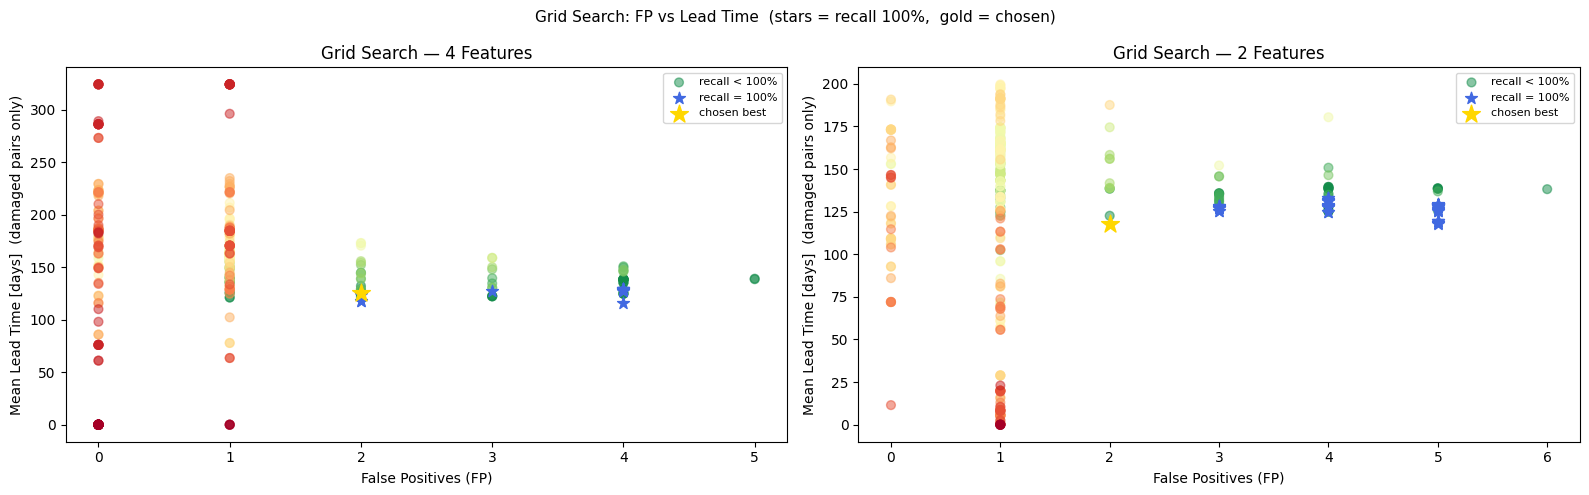

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, grid_df, lbl in zip(axes, [grid_4, grid_2],
                             ["4 Features", "2 Features"]):
    # Scatter: FP vs mean_lead_days, color=recall, size=n_estimators
    perfect = grid_df[grid_df["recall"] == 1.0]
    rest    = grid_df[grid_df["recall"] <  1.0]

    if not rest.empty:
        sc0 = ax.scatter(rest["FP"], rest["mean_lead_days"],
                         c=rest["recall"], cmap="RdYlGn",
                         vmin=0, vmax=1, s=40, alpha=0.5, marker="o",
                         label="recall < 100%")
    if not perfect.empty:
        sc1 = ax.scatter(perfect["FP"], perfect["mean_lead_days"],
                         c="royalblue", s=80, marker="*",
                         label="recall = 100%", zorder=5)
        # Highlight the chosen best
        best_row = perfect.sort_values(["FP","mean_lead_days"],
                                        ascending=[True, False]).iloc[0]
        ax.scatter(best_row["FP"], best_row["mean_lead_days"],
                   c="gold", s=180, marker="*", zorder=6, label="chosen best")

    ax.set_xlabel("False Positives (FP)")
    ax.set_ylabel("Mean Lead Time [days]  (damaged pairs only)")
    ax.set_title(f"Grid Search — {lbl}")
    ax.legend(fontsize=8)

plt.suptitle("Grid Search: FP vs Lead Time  (stars = recall 100%,  gold = chosen)", fontsize=11)
plt.tight_layout()
plt.show()


## 15b. [EXPERIMENTAL] Extended Parameter Sweep
Sweeps `EXP_BASELINE_N`, `EXP_SCORE_SIGMA`, and `EXP_CUSUM_H_FACTOR` across both
the global-IF and group-IF scored data. Finds the combination giving 100% recall
with the fewest false positives and longest lead time.


/root/.ipykernel/6037/command-5630547205330651-2715341459:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf_te.groupby(["device_id","tube_id"], group_keys=False).apply(_calibrate)
/root/.ipykernel/6037/command-5630547205330651-2715341459:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf_te.groupby(["device_id","tube_id"], group_keys=False).apply(_calibrate)
/root/.ipykernel/6037/comman

[EXPERIMENTAL] Top 15 parameter combinations (mean and median lead days):


/root/.ipykernel/6037/command-5630547205330651-2715341459:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf_te.groupby(["device_id","tube_id"], group_keys=False).apply(_calibrate)


variant,baseline_n,score_sigma,cusum_h_factor,recall,FP,TP,FN,mean_lead_days,median_lead_days
Group IF + Calib,10,1.0,1.5,1.0,8,13,0,139.2,120.0
Group IF + Calib,50,1.0,1.5,1.0,8,13,0,139.2,120.0
Group IF + Calib,50,1.5,1.5,1.0,8,13,0,139.2,120.0
Group IF + Calib,10,1.0,2.0,1.0,7,13,0,138.8,120.0
Group IF + Calib,10,1.0,2.5,1.0,7,13,0,138.6,120.0
Group IF + Calib,20,1.0,1.5,1.0,8,13,0,138.6,120.0
Group IF + Calib,20,1.0,2.0,1.0,8,13,0,138.6,120.0
Group IF + Calib,20,1.0,2.5,1.0,8,13,0,138.6,120.0
Group IF + Calib,20,1.0,3.0,1.0,8,13,0,138.6,120.0
Group IF + Calib,30,1.0,1.5,1.0,8,13,0,138.6,120.0


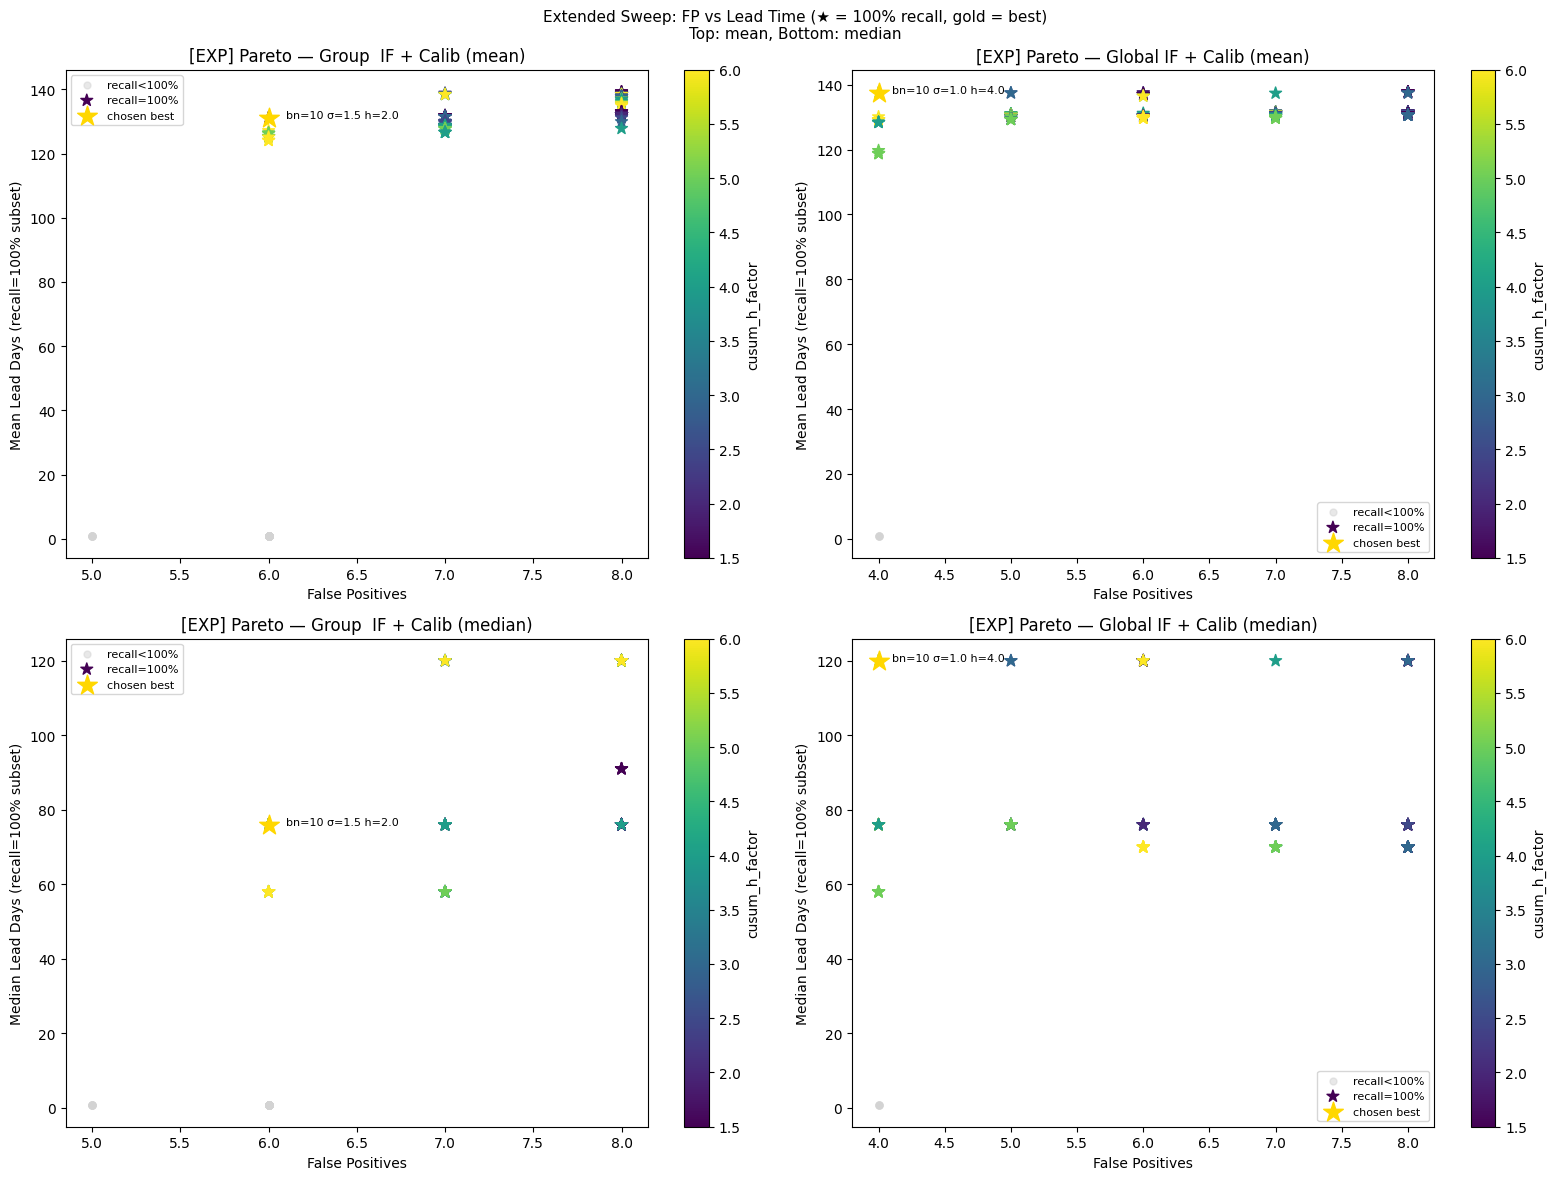


[Group  IF + Calib] Recommended (mean):
  baseline_n=10  score_sigma=1.5  cusum_h=2.0  recall=100%  FP=6  mean lead=131d
[Group  IF + Calib] Recommended (median):
  baseline_n=10  score_sigma=1.5  cusum_h=2.0  recall=100%  FP=6  median lead=76d

[Global IF + Calib] Recommended (mean):
  baseline_n=10  score_sigma=1.0  cusum_h=4.0  recall=100%  FP=4  mean lead=138d
[Global IF + Calib] Recommended (median):
  baseline_n=10  score_sigma=1.0  cusum_h=4.0  recall=100%  FP=4  median lead=120d

→ Copy recommended values into §2b Config and re-run §10b.


In [0]:
# ══════════════════════════════════════════════════════════════════════════════
# [EXPERIMENTAL] Extended parameter sweep: baseline_n × score_sigma × cusum_h
# ══════════════════════════════════════════════════════════════════════════════

exp_sweep_records = []

for variant_name, pdf_te_scored, score_col in [
    ("Global IF + Calib", pdf_te_best.copy(),  "if_score"),
    ("Group  IF + Calib", pdf_te_grp.copy(),   "group_if_score"),
]:
    for bn in EXP_BASELINE_N_SWEEP:
        for ss in EXP_SCORE_SIGMA_SWEEP:
            for ch in EXP_CUSUM_H_SWEEP:
                try:
                    cal = calibrate_and_cusum(
                        pdf_te_scored, score_col=score_col,
                        baseline_n=bn, score_sigma=ss,
                        cusum_k_factor=EXP_CUSUM_K_FACTOR,
                        cusum_h_factor=ch,
                        min_det=EXP_MIN_DETECTIONS
                    )
                    pf = exp_pair_detection(cal)
                    yt = pf["is_damaged"].astype(int)
                    yp = pf["drift_detected"].astype(int)
                    cm_ = confusion_matrix(yt, yp, labels=[1,0])
                    TP_,FN_ = cm_[0,0],cm_[0,1]
                    FP_,TN_ = cm_[1,0],cm_[1,1]
                    rec_ = TP_/(TP_+FN_) if (TP_+FN_)>0 else 0
                    det_ = pf[pf["is_damaged"] & pf["drift_detected"]]["lead_days"]
                    exp_sweep_records.append({
                        "variant":        variant_name,
                        "baseline_n":     bn,
                        "score_sigma":    ss,
                        "cusum_h_factor": ch,
                        "recall":  round(rec_,3),
                        "FP":      int(FP_),
                        "TP":      int(TP_),
                        "FN":      int(FN_),
                        "mean_lead_days": round(float(det_.mean()),1) if len(det_)>0 else 0.0,
                        "median_lead_days": round(float(det_.median()),1) if len(det_)>0 else 0.0,
                    })
                except Exception as ex:
                    pass  # skip failed combos (e.g. too few baseline samples)

exp_sweep_df = pd.DataFrame(exp_sweep_records).sort_values(
    ["recall","mean_lead_days","FP"], ascending=[False,False,True]
).reset_index(drop=True)

print("[EXPERIMENTAL] Top 15 parameter combinations (mean and median lead days):")
display(spark.createDataFrame(exp_sweep_df.head(15)))

# ── Pareto plots: one per variant ─────────────────────────────────────────────
variants = exp_sweep_df["variant"].unique()
fig, axes = plt.subplots(2, len(variants), figsize=(8*len(variants), 12))
if len(variants)==1: axes = np.array([[axes[0]], [axes[1]]])

for i, metric in enumerate(["mean_lead_days", "median_lead_days"]):
    for j, var in enumerate(variants):
        ax = axes[i, j]
        sub     = exp_sweep_df[exp_sweep_df["variant"]==var]
        perfect = sub[sub["recall"]==1.0]
        rest    = sub[sub["recall"]< 1.0]

        if not rest.empty:
            ax.scatter(rest["FP"], rest["recall"],
                       c="lightgrey", s=25, alpha=0.5, label="recall<100%")
        if not perfect.empty:
            sc = ax.scatter(perfect["FP"], perfect[metric],
                            c=perfect["cusum_h_factor"], cmap="viridis",
                            s=80, marker="*", zorder=5, label="recall=100%")
            plt.colorbar(sc, ax=ax, label="cusum_h_factor")
            # Mark best
            best_r = perfect.sort_values(["FP",metric],ascending=[True,False]).iloc[0]
            ax.scatter(best_r["FP"], best_r[metric],
                       c="gold", s=220, marker="*", zorder=6, label="chosen best")
            ax.text(best_r["FP"]+0.1, best_r[metric],
                    f"bn={int(best_r['baseline_n'])} σ={best_r['score_sigma']} h={best_r['cusum_h_factor']}",
                    fontsize=8)

        ax.set_xlabel("False Positives")
        ylabel = "Mean Lead Days (recall=100% subset)" if metric=="mean_lead_days" else "Median Lead Days (recall=100% subset)"
        ax.set_ylabel(ylabel)
        ax.set_title(f"[EXP] Pareto — {var} ({'mean' if metric=='mean_lead_days' else 'median'})")
        ax.legend(fontsize=8)

plt.suptitle("Extended Sweep: FP vs Lead Time (★ = 100% recall, gold = best)\nTop: mean, Bottom: median", fontsize=11)
plt.tight_layout(); plt.show()

# ── Per-variant recommendation ────────────────────────────────────────────────
for var in variants:
    sub     = exp_sweep_df[exp_sweep_df["variant"]==var]
    perfect = sub[sub["recall"]==1.0]
    pool    = perfect if not perfect.empty else sub.head(1)
    rec_row_mean = pool.sort_values(["FP","mean_lead_days"],ascending=[True,False]).iloc[0]
    rec_row_median = pool.sort_values(["FP","median_lead_days"],ascending=[True,False]).iloc[0]
    print(f"\n[{var}] Recommended (mean):")
    print(f"  baseline_n={int(rec_row_mean['baseline_n'])}  score_sigma={rec_row_mean['score_sigma']}  "
          f"cusum_h={rec_row_mean['cusum_h_factor']}  "
          f"recall={rec_row_mean['recall']:.0%}  FP={int(rec_row_mean['FP'])}  "
          f"mean lead={rec_row_mean['mean_lead_days']:.0f}d")
    print(f"[{var}] Recommended (median):")
    print(f"  baseline_n={int(rec_row_median['baseline_n'])}  score_sigma={rec_row_median['score_sigma']}  "
          f"cusum_h={rec_row_median['cusum_h_factor']}  "
          f"recall={rec_row_median['recall']:.0%}  FP={int(rec_row_median['FP'])}  "
          f"median lead={rec_row_median['median_lead_days']:.0f}d")
print("\n→ Copy recommended values into §2b Config and re-run §10b.")

## 16. Anomaly Score Distribution — Damaged vs Healthy

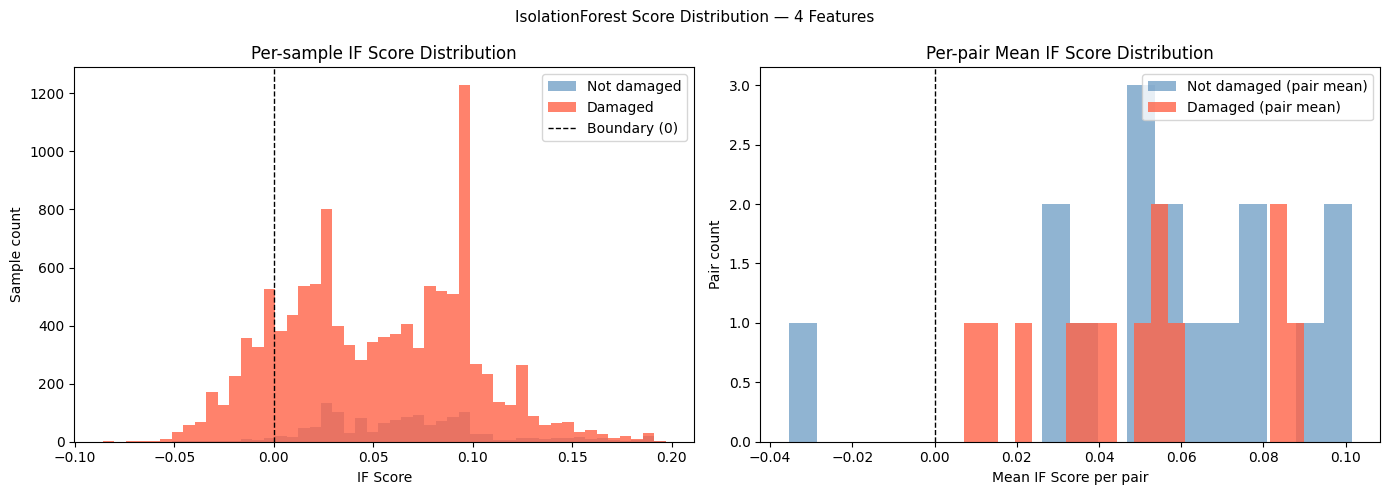

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dam_scores  = pdf_te_best[pdf_te_best["is_damaged"]]["if_score"]
safe_scores = pdf_te_best[~pdf_te_best["is_damaged"]]["if_score"]

bins = np.linspace(pdf_te_best["if_score"].min(),
                   pdf_te_best["if_score"].max(), 50)

# Per-sample distribution
axes[0].hist(safe_scores, bins=bins, color="steelblue", alpha=0.6, label="Not damaged")
axes[0].hist(dam_scores,  bins=bins, color="tomato",    alpha=0.8, label="Damaged")
axes[0].axvline(0, color="k", linestyle="--", lw=1.0, label="Boundary (0)")
axes[0].set_xlabel("IF Score")
axes[0].set_ylabel("Sample count")
axes[0].set_title("Per-sample IF Score Distribution")
axes[0].legend()

# Per-pair mean score
pair_mean = pdf_te_best.groupby(["device_id","tube_id","is_damaged"])["if_score"].mean().reset_index()
axes[1].hist(pair_mean[~pair_mean["is_damaged"]]["if_score"],
             bins=20, color="steelblue", alpha=0.6, label="Not damaged (pair mean)")
axes[1].hist(pair_mean[pair_mean["is_damaged"]]["if_score"],
             bins=20, color="tomato",    alpha=0.8, label="Damaged (pair mean)")
axes[1].axvline(0, color="k", linestyle="--", lw=1.0)
axes[1].set_xlabel("Mean IF Score per pair")
axes[1].set_ylabel("Pair count")
axes[1].set_title("Per-pair Mean IF Score Distribution")
axes[1].legend()

plt.suptitle(f"IsolationForest Score Distribution — {best_label}", fontsize=11)
plt.tight_layout()
plt.show()


## 17. Decision Boundary (2-Feature Projection)
Visualises the IsolationForest boundary projected onto `filcu_a_smooth` (heater current) vs `hv_kv_set` (high voltage)
(the two numerically most interpretable features).


/root/.ipykernel/6037/command-5630547205330637-1345276283:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)
/root/.ipykernel/6037/command-5630547205330637-1345276283:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return pdf.groupby(["device_id","tube_id"], group_keys=False).apply(_roll)


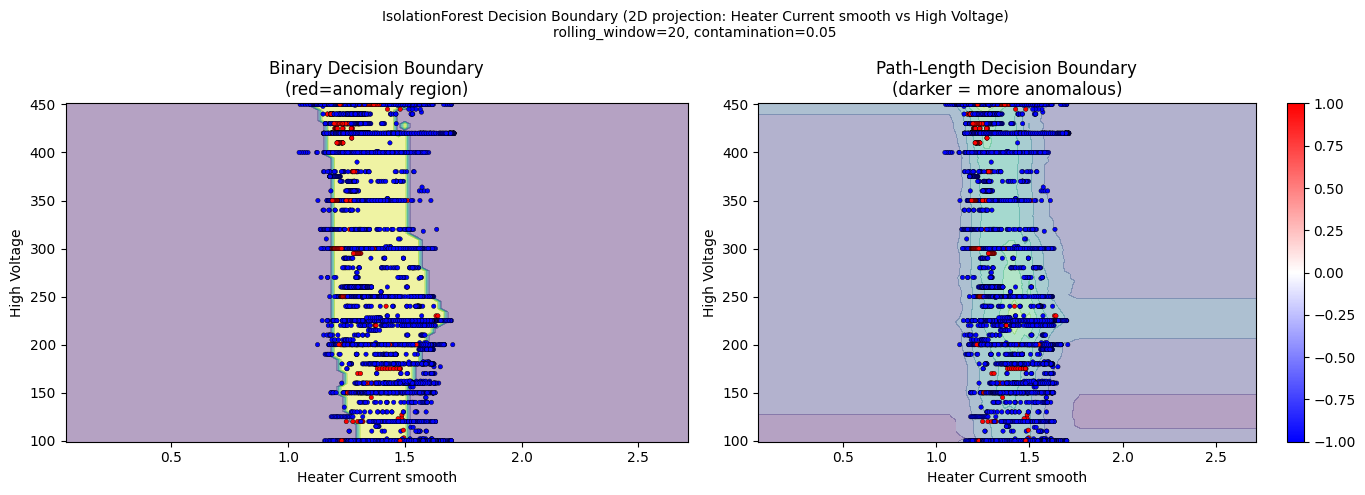

In [0]:
# Retrain a 2D-projection model for visualisation only
_feat_2d  = ["filcu_a_smooth", "hv_kv_set"]
_pdf_tr2d = apply_rolling(pdf_train, best_rw)
_pdf_te2d = apply_rolling(pdf_test,  best_rw)
_X_tr2d, _enc2d = encode_features(_pdf_tr2d, _feat_2d)
_X_te2d, _      = encode_features(_pdf_te2d, _feat_2d, fit_encoders=_enc2d)

_clf2d = IsolationForest(
    n_estimators  = int(best_overall["n_estimators"]),
    max_samples   = best_overall["max_samples"],
    contamination = float(best_overall["contamination"]),
    max_features  = float(best_overall["max_features"]),
    random_state  = 42,
)
_clf2d.fit(_X_tr2d)

_y_te = np.where(_pdf_te2d["is_damaged"].values, -1, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary boundary
disp1 = DecisionBoundaryDisplay.from_estimator(
    _clf2d, _X_te2d, response_method="predict", alpha=0.4, ax=axes[0]
)
sc = axes[0].scatter(_X_te2d[:, 0], _X_te2d[:, 1],
                     c=_y_te, cmap="bwr", s=10, edgecolor="k", linewidths=0.3)
axes[0].set_xlabel("Heater Current smooth")
axes[0].set_ylabel("High Voltage")
axes[0].set_title("Binary Decision Boundary\n(red=anomaly region)")

# Score (path length) boundary
disp2 = DecisionBoundaryDisplay.from_estimator(
    _clf2d, _X_te2d, response_method="decision_function", alpha=0.4, ax=axes[1]
)
axes[1].scatter(_X_te2d[:, 0], _X_te2d[:, 1],
                c=_y_te, cmap="bwr", s=10, edgecolor="k", linewidths=0.3)
axes[1].set_xlabel("Heater Current smooth")
axes[1].set_ylabel("High Voltage")
axes[1].set_title("Path-Length Decision Boundary\n(darker = more anomalous)")
plt.colorbar(disp2.ax_.collections[1], ax=axes[1])

plt.suptitle(
    "IsolationForest Decision Boundary (2D projection: Heater Current smooth vs High Voltage)\n"
    f"rolling_window={best_rw}, contamination={best_overall['contamination']}",
    fontsize=10
)
plt.tight_layout()
plt.show()


## 18. Summary — 4-Feature vs 2-Feature Comparison

In [0]:
summary_rows = []
for grid_df, feat_lbl in [(grid_4, "4 Features"), (grid_2, "2 Features")]:
    best = pick_best(grid_df, feat_lbl)
    summary_rows.append({
        "Feature Set":       feat_lbl,
        "Rolling Window":    int(best["rolling_window"]),
        "n_estimators":      int(best["n_estimators"]),
        "contamination":     best["contamination"],
        "Recall (damaged)":  f"{best['recall']:.0%}",
        "FP":                int(best["FP"]),
        "TN":                int(best["TN"]),
        "Mean Lead [days]":  best["mean_lead_days"],
    })

summary_df = pd.DataFrame(summary_rows)
display(spark.createDataFrame(summary_df))



Best config — 4 Features
  rolling_window : 20
  n_estimators   : 100
  max_samples    : 128
  contamination  : 0.05
  max_features   : 1.0
  recall         : 100%
  FP             : 2
  mean lead time : 125.2 days

Best config — 2 Features
  rolling_window : 5
  n_estimators   : 100
  max_samples    : auto
  contamination  : 0.05
  max_features   : 1.0
  recall         : 100%
  FP             : 2
  mean lead time : 118.0 days


Feature Set,Rolling Window,n_estimators,contamination,Recall (damaged),FP,TN,Mean Lead [days]
4 Features,20,100,0.05,100%,2,14,125.2
2 Features,5,100,0.05,100%,2,14,118.0


## Parameter Tuning Reference

| Parameter | Section | Effect |
|---|---|---|
| `ROLLING_WINDOWS` | §2 Config | List of rolling-mean window sizes to sweep. `1` = raw signal. Larger windows smooth noise but delay detection. |
| `IF_PARAM_GRID["contamination"]` | §2 Config | Expected fraction of outliers. Lower values = stricter boundary = fewer FP but risk missing TP. |
| `IF_PARAM_GRID["n_estimators"]` | §2 Config | Number of isolation trees. More = more stable but slower. |
| `IF_PARAM_GRID["max_samples"]` | §2 Config | Samples per tree. `"auto"` = min(256, n). Smaller = faster, coarser boundary. |
| `MIN_DETECTIONS` | §2 Config | Consecutive anomaly samples required to confirm drift. Lower = earlier detection, more noise. |
| `BALANCE_BY_PAIR` | §2 Config | If `True`, equal samples per pair. Recommended `False` for IF — more data improves density estimation. |
